# FR12 — Competition environment: intensity, entry and exit, scenarios, early warning

**MIIS module 15.5.2 — Microeconomic analysis and forecasting.** Ministry of Economy of the Republic of Azerbaijan.

> **Status note.** Layer A (aggregate data) is operational and gives results. **Layer B (the firm-level
> competition engine) awaits the DSK business register** requested on 24 August 2026 ("NACE × region üzrə müəssisə
> səviyyəsində gəlir; giriş və çıxış — DSK biznes reyestri — due 26 Aug 2026", not received). Until it arrives Layer B
> runs on a **SYNTHETIC register — not real enterprise data** (`data/business_register/FR12_business_register_SYNTHETIC.csv`),
> to prove the pipeline end to end. The banner printed in Part 17 states the data mode of every run.

## The requirement (approved wording, 24 August 2026)

> *"Rəqabət mühitinin təhlili, sektorlarda rəqabət intensivliyinin və müəssisələrin rəqabət strategiyalarının
> qiymətləndirilməsi və proqnozlaşdırılması mümkün olmalıdır."*

Agreed recommendation (Tövsiyə – D.Ə.): instead of assessing firms' competitive **strategies** directly, FR12 delivers
(1) measurement of **competition intensity by sector** and of the **frequency of entry and exit**, with forecasts of
these indicators; (2) **scenario analysis** of a sector's likely reaction to a policy or market change, based on
industrial-organisation theory, with assumptions shown; (3) detection of sectors where competition is
**deteriorating**, through early-warning indicators; plus analysis and forecasting of **market concentration**.
Indicators are agreed with the Customer subject to data availability, hence the data-source matrix and the gaps
table (Part 9).

### Why "competitive strategy" is not estimated, and what replaces it

A strategy (cost leadership, differentiation, collusion, pre-emption, predation) is a *management intention*. No
statistical source records it, and inferring it from aggregate data would be speculation presented as measurement.
FR12 measures the **observable behaviour** in which strategies show up: **entry** (new units and their size),
**exit** (liquidations, survival by age), **share mobility** (how much market shares move and ranks change),
**margins** (price-cost margin proxy, the Boone profit elasticity once firm data exist) and **concentration**
(HHI, CR4, size-class bounds). These are what a competition authority can monitor and act on.

## Constraints set by the requester (as in FR1–FR10)

- **No autoregressive models**: no AR, ARIMA, ARCH, GARCH, no lagged dependent variable, no variable forecast from
  its own history. Part 10 lists every lag construct that appears and why it is not an autoregression; the number
  of active enterprises follows the stock-flow identity $N_t = N_{t-1} + B_t - D_t$, an accounting identity.
- **Structural models showing related-sector effects**: entry and exit are driven by FR1's sector demand paths,
  credit conditions and FR10's profitability, never by their own past.
- **DSK data where the workbook lacks it**: the statistical-register and entrepreneurship tables, including the
  **archived vintages** of DSK files (Part 4), which extend the activity panel back to 2019.
- **NFR1**: accuracy against simple benchmarks (random walk and the constant mean rate), using only data
  available at the forecast time (Part 12).

## Two layers

| Layer | Unit of analysis | Data | Status |
|---|---|---|---|
| **A — operational now** | 11 DSK activity groups, 19 NACE sections, 14 economic regions, taxpayer size classes | DSK statistical register (`st_units`), entrepreneurship and national-accounts tables, archived DSK vintages, workbook `Regionlar*`, `DVX üzrə göstəricilər`, `Verilmiş lisenziyalar`, `Aparılan yoxlamalar`; FR1 and FR10 outputs | **Results** (Parts 5–16) |
| **B — firm-level competition engine** | the enterprise (statistical unit) | DSK business register (requested 24 Aug 2026) | **SYNTHETIC pipeline demonstration** (Part 17) — replaced by the Ministry's file in its own system |

## Contents

2 Environment · 3 Toolkit · 4 Data collection (incl. archived vintages) · 5 Parsing · 6 Data integrity ·
7 Competition indicators · 8 Concentration bounds · 9 Source matrix, gaps, presentation · 10 No-AR constructs ·
11 Entry/exit panel · 12 Model selection and hold-out · 13 Entry/exit forecasts 2026–2030 · 14 Concentration paths ·
15 IO scenario toolkit · 16 Early warning · 17 Layer B (SYNTHETIC) · 18 Checks, exports, documentation.

## Part 2 — Environment and reproducibility

Inputs: the workbook; the DSK tables already in `data/dsk_enterprise/` (read only, shared with FR10); the archived
DSK vintages in `data/dsk_competition/` (downloaded once, re-read afterwards); FR1 and FR10 result files in `output/`;
and the Layer-B business register in `data/business_register/`. One seed drives every random element (parameter
draws, residual-path resampling, wild bootstrap, the SYNTHETIC register). No random number enters a Layer-A point
estimate or a baseline forecast.

In [1]:
%matplotlib inline
import os, sys, re, json, math, warnings, unicodedata, urllib.request, copy, time
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats
import matplotlib, matplotlib.pyplot as plt
import xlrd, openpyxl

T0 = time.time()
warnings.filterwarnings('ignore')
SEED = 20261012
pd.set_option('display.width', 230, 'display.max_columns', 60, 'display.max_rows', 200,
              'display.float_format', lambda v: f'{v:,.3f}')
plt.rcParams.update({'figure.figsize': (12, 5.0), 'figure.dpi': 100, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False})
PAL = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#393b79']

BASE = Path.cwd().resolve()
assert (BASE / 'data').is_dir() and (BASE / 'output').is_dir(), f'run FR12.ipynb from the MicroUnit directory, not {BASE}'
XL   = BASE / 'data' / 'Statistik data dinamika 05.06.2026 +.xlsx'
DDIR = BASE / 'data' / 'dsk_enterprise'          # FR10's DSK downloads, read only
CDIR = BASE / 'data' / 'dsk_competition'         # FR12's extra DSK downloads (archived vintages)
BRDIR = BASE / 'data' / 'business_register'      # Layer-B input (SYNTHETIC until the Ministry places its own file)
OUT  = BASE / 'output'
for d in (CDIR, BRDIR): d.mkdir(parents=True, exist_ok=True)

LAST_ACT = 2025
FC_YEARS = list(range(2026, 2031)); H = len(FC_YEARS)
SCEN     = ['Baseline', 'Adverse', 'Reform']
SEL_END  = 2022                     # every selection score falls in years <= 2022
HOLD     = {'activity': [2024], 'region': [2024, 2025]}   # untouched hold-out targets (selection scores 2023 only)
SYN_MARK = 'SYNTHETIC — pipeline demonstration, not findings'
SYN_STATUS = 'SYNTHETIC — not real enterprise data'

print('python      ', sys.version.split()[0])
for m in ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'xlrd', 'openpyxl']:
    try:
        mod = __import__(m); print(f'{m:<12}', getattr(mod, '__version__', 'n/a'))
    except ImportError:
        print(f'{m:<12} NOT INSTALLED')
print('workbook    ', XL.exists(), f'{XL.stat().st_size/1e6:.2f} MB' if XL.exists() else '')
print(f'last actual {LAST_ACT} | forecast {FC_YEARS[0]}-{FC_YEARS[-1]} | selection scores <= {SEL_END} | '
      f'hold-out targets {HOLD} | seed {SEED}')

python       3.14.7
numpy        2.4.2
pandas       2.3.3
scipy        1.18.1
statsmodels  0.14.6
matplotlib   3.11.1
xlrd         2.0.2
openpyxl     3.1.5
workbook     True 3.43 MB
last actual 2025 | forecast 2026-2030 | selection scores <= 2022 | hold-out targets {'activity': [2024], 'region': [2024, 2025]} | seed 20261012


### 2.1 Parsing conventions

Two traps carried over from FR1–FR10. (1) Azerbaijani casing: `'İ'.lower()` returns `i` + U+0307, which must be
folded, while the dotless `ı` must be preserved. (2) DSK cells stored as text: non-breaking-space thousands
separators, comma decimals, footnote asterisks, and — new in the industry tables — the suffix **`t.`** meaning
*thousand per cent* (`'7.8 t.'` = 7 800% of the base year). `to_num` handles all of them; the assertions below
keep a future edit from breaking any.

In [2]:
def az_lower(s):
    return unicodedata.normalize('NFC', str(s).lower().replace('̇', ''))

_BLANK = {'', '-', '–', '—', '...', '..', '…', 'x', 'n/a', 'N/A'}
def to_num(v):
    if v is None or isinstance(v, bool):
        return np.nan
    if isinstance(v, (int, float, np.floating)):
        return np.nan if (isinstance(v, float) and np.isnan(v)) else float(v)
    t = str(v).replace('\xa0', '').replace(' ', '').strip()
    mult = 1.0
    if re.search(r'\d\s*t\.?\s*$', t):          # DSK index tables: '7.8 t.' = thousand per cent
        mult = 1000.0; t = re.sub(r'\s*t\.?\s*$', '', t)
    t = t.replace(' ', '').rstrip('*').replace('%', '')
    if t in _BLANK:
        return np.nan
    if re.fullmatch(r'-?\d+,\d+', t):
        t = t.replace(',', '.')
    elif re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', t):
        t = t.replace('.', '').replace(',', '.')
    elif re.fullmatch(r'-?[1-9]\d{0,2}(\.\d{3})+', t):       # TEXT '1.581' = 1 581 (dot as thousands separator)
        t = t.replace('.', '')
    else:
        t = t.replace(',', '')
    try:
        return float(t) * mult
    except ValueError:
        return np.nan

for raw, want in [('7.8 t.', 7800.0), ('97,8 t.', 97800.0), ('33,0*', 33.0), ('4\xa0088\xa0188,1', 4088188.1),
                  ('…', np.nan), ('-', np.nan), (12.5, 12.5), ('1.234,5', 1234.5), ('108 .3', 108.3), ('1.581', 1581.0), (1.581, 1.581)]:
    got = to_num(raw)
    assert (np.isnan(got) and np.isnan(want)) or abs(got - want) < 1e-9, f'to_num({raw!r}) = {got}'
assert az_lower('İqtisadiyyat') == 'iqtisadiyyat' and az_lower('artım') == 'artım'
print('parsing self-tests passed (thousand-per-cent suffix, comma decimals, footnote marks, Azerbaijani casing)')

parsing self-tests passed (thousand-per-cent suffix, comma decimals, footnote marks, Azerbaijani casing)


## Part 3 — Econometric toolkit

The estimators are the **same code as FR1, FR4, FR5 and FR10** (copied for self-containment), so all modules share
one covariance convention. Entry, exit and churn *rates* are bounded ratios with no stochastic trend, so FR12 has no
long-run level relation to estimate: DOLS and the Engle–Granger/MacKinnon machinery of FR10 are not needed here, and
that is stated rather than applied for form.

| Function | What it does |
|---|---|
| `ols` | OLS with Newey–West HAC covariance scaled by n/(n−k); p-values from t(n−k) |
| `wald_F` | HAC-F test of linear restrictions, F(m, n−k) |
| `dm_hln`, `dm_by_year` | Diebold–Mariano with the Harvey–Leybourne–Newbold correction; `dm_by_year` averages the loss by target year first (overlap-robust) — needs ≥ 3 target years, so FR12's hold-out (1–2 target years) uses the test paired across units instead |
| `panel_fe` | Fixed effects (one- or two-way, exact on unbalanced panels by alternating projections), Driscoll–Kraay SEs with ⌊T^¼⌋ lags and **t(T−1)** inference |
| `wild_cluster_p` | Wild cluster bootstrap-t by year, Webb six-point weights, null imposed |
| `between_fit` | Between estimator on unit means (cross-sectional association, distinct from the within effect) |
| `theil` | Theil U = RMSE(model) / RMSE(benchmark) |

The cell after the definitions checks them against statsmodels on simulated data to 1e-8.

In [3]:
class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval}, index=self.names)
        t['sig'] = ['***' if p < .01 else '**' if p < .05 else '*' if p < .10 else '' for p in self.pval]
        return t.round(digits)

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None):
    '''Newey-West HAC covariance: corrects INFERENCE for residual dependence; no lag enters the model.'''
    n = len(X)
    if lags is None: lags = max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    Xu = X * u[:, None]; S = Xu.T @ Xu
    for L_ in range(1, lags + 1):
        G = Xu[L_:].T @ Xu[:-L_]; S += (1 - L_ / (lags + 1)) * (G + G.T)
    return XtXi @ S @ XtXi

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv @ b
    dof = max(n - k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags) * n / dof
    elif cov == 'hc1': V = XtXi @ ((Xv * u[:, None]).T @ (Xv * u[:, None])) @ XtXi * n / dof
    else:              V = XtXi * (u @ u) / dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b / se
    tss = ((yv - yv.mean()) ** 2).sum() if add_const else (yv ** 2).sum()
    r2 = 1 - (u @ u) / tss if tss > 0 else np.nan
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2 * (1 - stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, V=V, X=Xv, y=yv, index=idx, dof=dof,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv @ b, index=idx), sigma2=(u @ u) / dof)

def wald_F(fit, R, q):
    '''HAC-F test of R beta = q against F(m, n-k).'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q; Vr = R @ fit.V @ R.T
    m = R.shape[0]; Fs = float(d @ np.linalg.pinv(Vr) @ d) / m
    return Fs, float(1 - stats.f.cdf(Fs, m, fit.dof))

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.adfvalues import mackinnonp
def dm_hln(loss1, loss2, h=1):
    '''Diebold-Mariano with the HLN small-sample correction, t(T-1). Negative = model 1 has lower loss.'''
    d = np.asarray(loss1, float) - np.asarray(loss2, float)
    d = d[np.isfinite(d)]; T = len(d)
    if T < 3 or np.allclose(d, 0): return np.nan, 1.0
    h = int(max(1, min(h, T // 3))); db = d.mean()
    g = [np.mean((d[k:] - db) * (d[:T - k] - db)) for k in range(h)]
    V = (g[0] + 2 * sum(g[1:])) / T
    if V <= 0: V = g[0] / T
    s = db / np.sqrt(V) * np.sqrt(max((T + 1 - 2 * h + h * (h - 1) / T) / T, 1e-12))
    return float(s), float(2 * (1 - stats.t.cdf(abs(s), T - 1)))

def dm_by_year(loss1, loss2, h=2):
    '''Overlap-robust DM: losses indexed (origin, target year) are averaged by TARGET YEAR first, so overlapping
    origins that score the same year contribute one observation; then DM/HLN on the year series.'''
    a = pd.Series(loss1).groupby(level=1).mean(); b = pd.Series(loss2).groupby(level=1).mean()
    yrs = a.index.intersection(b.index)
    s, p = dm_hln(a.loc[yrs].values, b.loc[yrs].values, h=h)
    return s, p, len(yrs)

def _within(df, dep, regs, entity, time, twoway):
    d = df[[entity, time, dep] + regs].dropna().copy()
    for c in [dep] + regs:
        if twoway:
            # alternating projections: exact two-way within transformation on an UNBALANCED panel (equals LSDV)
            x = d[c].astype(float)
            for _ in range(10000):
                x_new = x - x.groupby(d[entity]).transform('mean')
                x_new = x_new - x_new.groupby(d[time]).transform('mean')
                if float((x_new - x).abs().max()) < 1e-13: x = x_new; break
                x = x_new
            d[c] = x
        else:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    return d

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=None):
    '''Two-way FE within estimator; Driscoll-Kraay SEs, bandwidth floor(T^(1/4)); t(T-1) inference because the
    DK variance is built from T year-level score sums.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T @ Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv @ b
    nN, nT = d[entity].nunique(), d[time].nunique()
    if dk_lags is None: dk_lags = int(np.floor(nT ** 0.25))
    k = len(regs) + nN + (nT - 1 if twoway else 0)
    ht = pd.DataFrame(Xv * u[:, None], index=d[time].to_numpy()).groupby(level=0).sum().sort_index().to_numpy()
    S = ht.T @ ht
    for L_ in range(1, dk_lags + 1):
        G = ht[L_:].T @ ht[:-L_]; S += (1 - L_ / (dk_lags + 1)) * (G + G.T)
    V = XtXi @ S @ XtXi * (len(d) / max(len(d) - k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b / se; dof = max(nT - 1, 1)
    r2 = 1 - (u @ u) / (yv @ yv) if (yv @ yv) > 0 else np.nan
    return Fit(kind='two-way FE [Driscoll-Kraay]' if twoway else 'entity FE [DK]', beta=b, se=se, tstat=t,
               pval=2 * (1 - stats.t.cdf(np.abs(t), dof)), names=regs, n=len(d), k=k, r2=r2, V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof, dk_lags=dk_lags)

WEBB6 = np.array([-np.sqrt(1.5), -1.0, -np.sqrt(0.5), np.sqrt(0.5), 1.0, np.sqrt(1.5)])

def wild_cluster_p(df, dep, regs, test, entity='unit', time='year', twoway=True, B=999, seed=None):
    '''Wild cluster bootstrap-t (null imposed), clusters = years, Webb six-point weights, CR1 t-statistics.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    tt = d[time].to_numpy(); ug = np.unique(tt); G = len(ug); gi = np.searchsorted(ug, tt)
    j = regs.index(test); XtXi = np.linalg.pinv(Xv.T @ Xv)
    def tstat(y_):
        b = XtXi @ Xv.T @ y_; u = y_ - Xv @ b
        sc = np.zeros((G, Xv.shape[1])); np.add.at(sc, gi, Xv * u[:, None])
        V = XtXi @ (sc.T @ sc) @ XtXi * G / max(G - 1, 1)
        return b[j] / np.sqrt(max(V[j, j], 1e-300))
    t0 = tstat(yv)
    Xr = np.delete(Xv, j, axis=1)
    fr = Xr @ (np.linalg.pinv(Xr.T @ Xr) @ Xr.T @ yv) if Xr.shape[1] else np.zeros_like(yv)
    ur = yv - fr
    rg = np.random.default_rng(SEED if seed is None else seed)
    W = rg.choice(WEBB6, size=(B, G))
    ts = np.array([tstat(fr + ur * W[b_, gi]) for b_ in range(B)])
    return float(np.mean(np.abs(ts) >= abs(t0))), float(t0)

def between_fit(df, dep, regs, entity='unit'):
    '''Between estimator: OLS on unit means (HC1). Cross-sectional association, NOT a within-unit effect.'''
    m = df[[entity, dep] + regs].dropna().groupby(entity).mean()
    return ols(m[dep], m[regs], cov='hc1')

def theil(m, b):
    a = float(np.sqrt(np.nanmean(np.asarray(m, float) ** 2))); c = float(np.sqrt(np.nanmean(np.asarray(b, float) ** 2)))
    return a / c if c > 0 else np.nan

print('toolkit defined: ols, wald_F, dm_hln, dm_by_year, panel_fe (DK, t(T-1)), wild_cluster_p (Webb), between_fit, theil')

toolkit defined: ols, wald_F, dm_hln, dm_by_year, panel_fe (DK, t(T-1)), wild_cluster_p (Webb), between_fit, theil


In [4]:
import statsmodels.api as sm
_rng = np.random.default_rng(SEED)
n = 80
Xt = pd.DataFrame(_rng.standard_normal((n, 3)), columns=['a', 'b', 'c'])
yt = pd.Series(1 + 2 * Xt.a - 1.5 * Xt.b + .5 * Xt.c + _rng.standard_normal(n) * .3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta - r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se - r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se - r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC', cov_kwds={'maxlags': 3, 'use_correction': True})
rows.append(['Newey-West HAC SE, n/(n-k) scaled', np.abs(f2.se - r2_.bse.values).max()])
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = _rng.standard_normal(80); pdf['y'] = 1 + 0.6 * pdf.x + pdf.unit * 0.3 + _rng.standard_normal(80) * .2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y', 'x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient vs OLS on demeaned data', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
_ub = pdf.drop(index=[3, 11, 12, 40, 41, 42, 77]).copy(); _ub['x2'] = _rng.standard_normal(len(_ub)) + _ub.year * 0.1
_f2 = panel_fe(_ub, 'y', ['x', 'x2'])
_D = pd.get_dummies(_ub[['unit', 'year']].astype(str), drop_first=True).astype(float)
_l = sm.OLS(_ub.y, sm.add_constant(pd.concat([_ub[['x', 'x2']], _D], axis=1))).fit()
rows.append(['two-way FE on an UNBALANCED panel vs dummy-variable OLS', float(np.abs(_f2.beta - _l.params[['x', 'x2']].values).max())])
_f1w = panel_fe(_ub, 'y', ['x', 'x2'], twoway=False)
_D1 = pd.get_dummies(_ub[['unit']].astype(str), drop_first=True).astype(float)
_l1 = sm.OLS(_ub.y, sm.add_constant(pd.concat([_ub[['x', 'x2']], _D1], axis=1))).fit()
rows.append(['one-way FE on an UNBALANCED panel vs dummy-variable OLS', float(np.abs(_f1w.beta - _l1.params[['x', 'x2']].values).max())])
chk = pd.DataFrame(rows, columns=['check', 'max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), 'estimator validation failed'
_s, _p = dm_hln(np.ones(20), np.ones(20) + _rng.standard_normal(20) * 0.01)
print(f'all estimators reproduce statsmodels to 1e-8 | DM/HLN on (nearly) equal losses p = {_p:.2f}')

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,"Newey-West HAC SE, n/(n-k) scaled",0.000,exact
4,panel FE coefficient vs OLS on demeaned data,0.000,exact
5,two-way FE on an UNBALANCED panel vs dummy-var...,0.000,exact
6,one-way FE on an UNBALANCED panel vs dummy-var...,0.000,exact


all estimators reproduce statsmodels to 1e-8 | DM/HLN on (nearly) equal losses p = 0.85


## Part 4 — Collecting the data, including archived DSK vintages

The DSK entrepreneurship tables publish only the **latest two years** (2023–2024) and the statistical register
(`st_units`) only the **latest period** (1 July 2026, January–June flows). A forecast model needs a time dimension, so
FR12 recovers **earlier vintages of the same DSK files** from the Internet Archive (`web.archive.org`, the `id_`
form that returns the original bytes). Every vintage is checked to be a genuine Excel file, saved once under
`data/dsk_competition/vintages/` and re-read from disk afterwards. The manifest (`output/FR12_dsk_manifest.csv`)
records, per file, the full source URL (archive snapshot or DSK address), the local path and its SHA-256 checksum. This is a documented, reproducible source
(DSK's own files as published on the snapshot date), not an estimate. Recovered coverage:

- entrepreneurship `006` (registered, newly registered, deregistered entrepreneurship subjects, 11 activity groups):
  2019–2020 (April 2022 vintage), 2022–2023 (April 2025 vintage), 2023–2024 (current) → **2019, 2020, 2022, 2023, 2024**;
- entrepreneurship `012`/`013` (SME shares of output / employees by activity) and `002` (active SMEs by size):
  the same three vintages;
- statistical register `2_1` (newly created and liquidated units by NACE section) and `2_3` (by region):
  full-year 2021 (March 2022 vintage), 2024 (April 2025), 2025 (February 2026), and January–June 2022, 2024, 2025, 2026.

No vintage of the full-year 2022 or 2023 register flows was archived; that gap is recorded, not filled.
Current DSK files not used by FR10 (size classes by region `1_4_k/o/m`, individual entrepreneurs `1_5`–`1_8`) are
downloaded directly from `stat.gov.az` with a `Mozilla/5.0` User-Agent.

In [5]:
XLS_MAGIC = bytes.fromhex('d0cf11e0a1b11ae1')
WB_URL = 'https://web.archive.org/web/{ts}id_/http://www.stat.gov.az/source/{path}'
DSK_URL = 'https://www.stat.gov.az/source/{path}'
VINT = [  # local name, archive timestamp, DSK path, content / period covered
 ('e006_v2022.xls', '20220403145449', 'entrepreneurship/en/006en.xls', 'registered / new / deregistered, 11 groups, 2019-2020'),
 ('e006_v2025.xls', '20250421050555', 'entrepreneurship/en/006en.xls', 'registered / new / deregistered, 11 groups, 2022-2023'),
 ('e012_v2022.xls', '20220403145405', 'entrepreneurship/en/012en.xls', 'SME share of output by activity'),
 ('e012_v2025.xls', '20250421045614', 'entrepreneurship/en/012en.xls', 'SME share of output by activity'),
 ('e013_v2022.xls', '20220403145451', 'entrepreneurship/en/013en.xls', 'SME share of employees by activity'),
 ('e013_v2025.xls', '20250421050729', 'entrepreneurship/en/013en.xls', 'SME share of employees by activity'),
 ('e002_v2022.xls', '20220403145508', 'entrepreneurship/en/002en.xls', 'active SMEs by size'),
 ('e002_v2025.xls', '20250421045707', 'entrepreneurship/en/002en.xls', 'active SMEs by size'),
 ('e024_v2022.xls', '20220403145523', 'entrepreneurship/en/024en.xls', 'active SMEs established one year ago'),
 ('e024_v2025.xls', '20250421045635', 'entrepreneurship/en/024en.xls', 'active SMEs established one year ago'),
 ('s21_FY2021_az.xls', '20220307165205', 'st_units/az/2_1_az.xls', 'new / liquidated units by section, full year 2021'),
 ('s21_H1_2022_en.xls', '20220818184803', 'st_units/en/2_1en.xls', 'new / liquidated units by section, Jan-Jun 2022'),
 ('s21_H1_2024_az.xls', '20240927033915', 'st_units/az/2_1_az.xls', 'new / liquidated units by section, Jan-Jun 2024'),
 ('s21_FY2024_en.xls', '20250416142637', 'st_units/en/2_1en.xls', 'new / liquidated units by section, full year 2024'),
 ('s21_H1_2025_az.xls', '20250712215241', 'st_units/az/2_1_az.xls', 'new / liquidated units by section, Jan-Jun 2025'),
 ('s21_FY2025_az.xls', '20260213212129', 'st_units/az/2_1_az.xls', 'new / liquidated units by section, full year 2025'),
 ('s23_FY2021_az.xls', '20220307165212', 'st_units/az/2_3_az.xls', 'new / liquidated units by region, full year 2021'),
 ('s23_FY2024_en.xls', '20250416142923', 'st_units/en/2_3en.xls', 'new / liquidated units by region, full year 2024'),
 ('s23_FY2025_az.xls', '20260213212343', 'st_units/az/2_3_az.xls', 'new / liquidated units by region, full year 2025')]
CURR = [(f'{f}', f'st_units/en/{f}', t) for f, t in [
 ('1_4_o_en.xls', 'medium business entities by region'), ('1_4_k_en.xls', 'small business entities by region'),
 ('1_4_m_en.xls', 'micro business entities by region'), ('1_5_en.xls', 'individual entrepreneurs by activity'),
 ('1_6_en.xls', 'individual entrepreneurs by region'), ('1_7_en.xls', 'individual entrepreneurs by sex and activity'),
 ('1_8_en.xls', 'individual entrepreneurs by sex and region')]]

def _get(url, dest):
    if dest.exists() and dest.read_bytes()[:8] == XLS_MAGIC: return 'present'
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=90) as r: blob = r.read()
            if blob[:8] == XLS_MAGIC:
                dest.write_bytes(blob); return 'downloaded'
            return 'NOT AN EXCEL FILE (HTML reply)'
        except Exception as e:
            err = str(e)[:80]
    return f'FAILED: {err}'

(CDIR / 'vintages').mkdir(exist_ok=True); (CDIR / 'current').mkdir(exist_ok=True)
import hashlib
sha = lambda p: hashlib.sha256(Path(p).read_bytes()).hexdigest()
man = []
for nm, ts, path, what in VINT:
    url = WB_URL.format(ts=ts, path=path); st = _get(url, CDIR / 'vintages' / nm)
    man.append(('archived vintage', nm, url, what, st, f'data/dsk_competition/vintages/{nm}'))
for nm, path, what in CURR:
    url = DSK_URL.format(path=path); st = _get(url, CDIR / 'current' / nm)
    man.append(('DSK current', nm, url, what, st, f'data/dsk_competition/current/{nm}'))
for sec, web in [('st_units', 'st_units'), ('entrepreneurship', 'entrepreneurship'), ('nat_accounts', 'system_nat_accounts'), ('industry', 'industry')]:
    for p in sorted((DDIR / sec).glob('*.xls')):
        man.append(('FR10 download (read only)', p.name, DSK_URL.format(path=f'{web}/en/{p.name}'), 'shared with FR10', 'present', f'data/dsk_enterprise/{sec}/{p.name}'))
MANIFEST = pd.DataFrame(man, columns=['origin', 'file', 'source_url', 'content', 'status', 'local_path'])
MANIFEST['sha256'] = [sha(BASE / lp) if (BASE / lp).exists() else '' for lp in MANIFEST.local_path]
MANIFEST['bytes'] = [(BASE / lp).stat().st_size if (BASE / lp).exists() else 0 for lp in MANIFEST.local_path]
display(MANIFEST.groupby(['origin', 'status']).size().rename('files').reset_index())
bad = MANIFEST[~MANIFEST.status.isin(['present', 'downloaded'])]
assert bad.empty, f'inputs could not be obtained: {bad.file.tolist()}'
MANIFEST.to_csv(OUT / 'FR12_dsk_manifest.csv', index=False)
VD = CDIR / 'vintages'; CD = CDIR / 'current'
print(f'{len(MANIFEST)} input files available ({(MANIFEST.origin == "archived vintage").sum()} archived DSK vintages)')

,origin,status,files
0,DSK current,present,7
1,FR10 download (read only),present,115
2,archived vintage,present,19


141 input files available (19 archived DSK vintages)


## Part 5 — Parsing

### 5.1 Dictionaries and the statistical register (`st_units`)

No reader assumes a fixed offset. Rows are identified by **English or Azerbaijani** label patterns (the archived
vintages are partly in Azerbaijani), each match asserted unique. The register tables give, for every NACE section
and every economic region, the stock of statistical units and the units newly created and liquidated in the period.

In [6]:
SECT = {  # letter: (English name, EN pattern, AZ pattern, DSK activity group of the entrepreneurship tables)
 'A': ('Agriculture, forestry, fishing', r'^agricult', r'^kənd', 'AGR'),
 'B': ('Mining and quarrying', r'^mining', r'^mədənçıxarma', 'IND'),
 'C': ('Manufacturing', r'^manufactur', r'^emal', 'IND'),
 'D': ('Electricity, gas, steam', r'^electricity', r'^elektrik', 'IND'),
 'E': ('Water supply, waste', r'^water', r'^su təchizatı', 'IND'),
 'F': ('Construction', r'^construction', r'^tikinti', 'CON'),
 'G': ('Trade, repair of vehicles', r'^trade', r'^ticarət', 'TRD'),
 'H': ('Transportation and storage', r'^transportation', r'^nəqliyyat', 'TRA'),
 'I': ('Accommodation and food service', r'^accommodation', r'^turistlərin|^yerləşdirmə', 'ACC'),
 'J': ('Information and communication', r'^information', r'^informasiya', 'ICT'),
 'K': ('Financial and insurance', r'^financ', r'^maliyyə', 'OTH'),
 'L': ('Real estate', r'^real estate', r'^daşınmaz', 'REA'),
 'M': ('Professional, scientific, technical', r'^professional', r'^peşə', 'OTH'),
 'N': ('Administrative and support services', r'^administrative', r'^inzibati', 'OTH'),
 'O': ('Public administration and defence', r'^public administration', r'^dövlət idarəetməsi', 'OTH'),
 'P': ('Education', r'^education', r'^təhsil', 'EDU'),
 'Q': ('Human health and social work', r'^human health', r'^əhaliyə səhiyyə|^səhiyyə', 'HEA'),
 'R': ('Arts, entertainment, recreation', r'^arts', r'^istirahət', 'OTH'),
 'S': ('Other service activities', r'^other service', r'^digər', 'OTH'),
 'U': ('Extraterritorial organisations', r'^activities of extraterritorial|^extraterritorial', r'^toxunulmazlıq|^ekstraterritorial', 'OTH')}
SECS = list(SECT)
GROUPS = {  # DSK entrepreneurship activity groups: name, EN pattern, FR1 sector(s) supplying the demand driver
 'AGR': ('Agriculture', r'agricultur', ['rva_agr']), 'IND': ('Industry', r'industry', ['rva_min', 'rva_man', 'rva_elc', 'rva_wat']),
 'CON': ('Construction', r'construction', ['rva_con']), 'TRD': ('Trade', r'trade', ['rva_trd']),
 'TRA': ('Transport', r'transport', ['rva_tra']), 'ACC': ('Accommodation & food', r'accommodation', ['rva_tou']),
 'ICT': ('Information & communication', r'information', ['rva_ict']), 'REA': ('Real estate', r'real estate', ['rva_oth']),
 'EDU': ('Education', r'education', ['rva_oth']), 'HEA': ('Health & social', r'health', ['rva_oth']),
 'OTH': ('Other branches', r'other branches|provision of serv|^digər sahə', ['rva_oth'])}
GRP = list(GROUPS)
REG_PAT = {  # region: (EN pattern, AZ pattern, workbook name used by FR10)
 'Baku city': (r'^baku', r'^bakı'), 'Nakhchivan': (r'^nakh?chivan', r'^naxçıvan'), 'Absheron-Khizi': (r'^absheron', r'^abşeron'),
 'Daghlig Shirvan': (r'^da[gğ]h?li[gq] shirvan', r'^dağlıq'), 'Ganja-Dashkasan': (r'^ganja', r'^gəncə'),
 'Karabakh': (r'^(karabakh|garabagh)', r'^qarabağ'), 'Gazakh-Tovuz': (r'^gazakh', r'^qazax'), 'Guba-Khachmaz': (r'^guba', r'^quba'),
 'Lankaran-Astara': (r'^lankaran', r'^lənkəran'), 'Central Aran': (r'^central aran', r'^mərkəzi aran'),
 'Mil-Mughan': (r'^mil', r'^mil'), 'Shaki-Zagatala': (r'^sh[ae]ki', r'^şəki'), 'East Zangezur': (r'^(shergi|eastern|east) z[ae]ng', r'^şərqi'),
 'Shirvan-Salyan': (r'^shirvan-salyan', r'^şirvan')}
REGS = list(REG_PAT)

def sheet_rows(path):
    '''(row, label, numbers): the label joins the text cells; numbers are the non-empty, non-text cells to its right,
    with '-' kept as NaN so that column positions are preserved.'''
    sh = xlrd.open_workbook(path).sheet_by_index(0)
    istext = lambda v: isinstance(v, str) and bool(re.search(r'[A-Za-zƏəİıÖöÜüŞşÇçĞğ]', v))
    out = []
    for r in range(sh.nrows):
        cells = [sh.cell_value(r, c) for c in range(sh.ncols)]
        tpos = [c for c, v in enumerate(cells) if istext(v) and len(str(v).strip()) > 1]
        lab = re.sub(r'\s+', ' ', ' '.join(str(cells[c]).strip() for c in tpos)).strip()
        start = (max(tpos) + 1) if tpos else 0
        nums = [to_num(v) for v in cells[start:] if not (isinstance(v, str) and v.strip() == '') and not istext(v)]
        out.append((r, lab, nums))
    return out

def match_unique(labels, pat, what):
    hits = [i for i, l in enumerate(labels) if re.search(pat, az_lower(l))]
    assert len(hits) >= 1, f'{what}: /{pat}/ not found'
    return hits[0]

def parse_flows(path, kind):
    '''Register demography table (2_1 by section / 2_3 by region): stock at period end, new, liquidated.'''
    data = [(l, n) for r, l, n in sheet_rows(path) if l and len(n) >= 3]
    labs = [l for l, _ in data]
    keys = SECS if kind == 'section' else REGS
    out = {}
    for k in keys:
        pats = (SECT[k][1], SECT[k][2]) if kind == 'section' else REG_PAT[k]
        i = match_unique(labs, '|'.join(f'(?:{p})' for p in pats), f'{path.name} {k}')
        n = [0.0 if x != x else x for x in data[i][1]] + [0.0] * 4
        out[k] = dict(stock=n[0], new=n[1], liq=n[3])
    tot = [n for l, n in data if re.match(r'^(total|cəmi)\b', az_lower(l))]
    df = pd.DataFrame(out).T.fillna(0.0)
    df.attrs['total'] = dict(stock=tot[0][0], new=tot[0][1], liq=tot[0][3]) if tot else None
    return df

def parse_stock(path, kind='section'):
    data = [(l, n) for r, l, n in sheet_rows(path) if l and n]
    labs = [l for l, _ in data]
    keys = SECS if kind == 'section' else REGS
    out = {}
    for k in keys:
        pats = (SECT[k][1], SECT[k][2]) if kind == 'section' else REG_PAT[k]
        try:
            out[k] = data[match_unique(labs, '|'.join(f'(?:{p})' for p in pats), path.name)][1][0]
        except AssertionError:
            out[k] = 0.0 if k in ('O', 'U') else np.nan          # size-class tables omit public administration / extraterritorial
    return pd.Series(out)

FLOW_FILES = {('section', 'FY', 2021): VD / 's21_FY2021_az.xls', ('section', 'FY', 2024): VD / 's21_FY2024_en.xls',
              ('section', 'FY', 2025): VD / 's21_FY2025_az.xls', ('section', 'H1', 2022): VD / 's21_H1_2022_en.xls',
              ('section', 'H1', 2024): VD / 's21_H1_2024_az.xls', ('section', 'H1', 2025): VD / 's21_H1_2025_az.xls',
              ('section', 'H1', 2026): DDIR / 'st_units' / '2_1_en.xls',
              ('region', 'FY', 2021): VD / 's23_FY2021_az.xls', ('region', 'FY', 2024): VD / 's23_FY2024_en.xls',
              ('region', 'FY', 2025): VD / 's23_FY2025_az.xls', ('region', 'H1', 2026): DDIR / 'st_units' / '2_3_en.xls'}
FLOWS, FLOW_TOT = [], []
for (kind, per, yr), p in FLOW_FILES.items():
    d = parse_flows(p, kind)
    for k, r in d.iterrows():
        FLOWS.append(dict(kind=kind, period=per, year=yr, unit=k, **r.to_dict()))
    t = d.attrs['total']
    FLOW_TOT.append(dict(kind=kind, period=per, year=yr, file=p.name, **{f'published_{a}': t[a] for a in t},
                         **{f'sum_{a}': d[a].sum() for a in ['stock', 'new', 'liq']}))
FLOWS = pd.DataFrame(FLOWS); FLOW_TOT = pd.DataFrame(FLOW_TOT)
FLOW_TOT['max_gap'] = [max(abs(r[f'published_{a}'] - r[f'sum_{a}']) for a in ['stock', 'new', 'liq']) for _, r in FLOW_TOT.iterrows()]
display(FLOW_TOT)
assert (FLOW_TOT.max_gap <= 1).all(), 'section / region rows do not add up to the published total'
REG_FY = FLOWS[(FLOWS.kind == 'section') & (FLOWS.period == 'FY')].pivot_table(index='unit', columns='year', values=['stock', 'new', 'liq'])
SIZE = pd.DataFrame({c: parse_stock(DDIR / 'st_units' / f'1_3_{c[0]}_en.xls') for c in ['i_large', 'o_medium', 'k_small', 'm_micro']})
SIZE.columns = ['large', 'medium', 'small', 'micro']
SIZE_REG = pd.DataFrame({c: parse_stock((DDIR / 'st_units' / '1_4_i_en.xls') if c == 'large' else (CD / f"1_4_{dict(medium='o', small='k', micro='m')[c]}_en.xls"), 'region')
                         for c in ['large', 'medium', 'small', 'micro']})
print(f'register flows parsed: {len(FLOWS)} section/region-period rows; sections and regions add up to the published totals in every file')
print(f'size classes 1 July 2026: {SIZE.sum().astype(int).to_dict()} (commercial units {int(SIZE.sum().sum()):,})')

,kind,period,year,file,published_stock,published_new,published_liq,sum_stock,sum_new,sum_liq,max_gap
0,section,FY,2021,s21_FY2021_az.xls,"167,140.000","12,223.000",518.000,"167,140.000","12,223.000",518.000,0.000
1,section,FY,2024,s21_FY2024_en.xls,"212,705.000","14,865.000",698.000,"212,705.000","14,865.000",698.000,0.000
2,section,FY,2025,s21_FY2025_az.xls,"226,643.000","14,642.000",704.000,"226,643.000","14,642.000",704.000,0.000
3,section,H1,2022,s21_H1_2022_en.xls,"174,795.000","7,900.000",245.000,"174,795.000","7,900.000",245.000,0.000
4,section,H1,2024,s21_H1_2024_az.xls,"204,593.000","6,390.000",335.000,"204,593.000","6,390.000",335.000,0.000
5,section,H1,2025,s21_H1_2025_az.xls,"219,506.000","7,070.000",269.000,"219,506.000","7,070.000",269.000,0.000
6,section,H1,2026,2_1_en.xls,"232,847.000","6,604.000",400.000,"232,847.000","6,604.000",400.000,0.000
7,region,FY,2021,s23_FY2021_az.xls,"167,140.000","12,223.000",518.000,"167,140.000","12,223.000",518.000,0.000
8,region,FY,2024,s23_FY2024_en.xls,"212,705.000","14,865.000",698.000,"212,705.000","14,865.000",698.000,0.000
9,region,FY,2025,s23_FY2025_az.xls,"226,643.000","14,642.000",704.000,"226,643.000","14,642.000",704.000,0.000


register flows parsed: 196 section/region-period rows; sections and regions add up to the published totals in every file
size classes 1 July 2026: {'large': 918, 'medium': 4010, 'small': 10884, 'micro': 199604} (commercial units 215,416)


### 5.2 Entrepreneurship tables (current and archived vintages) and the production account

Each entrepreneurship table carries two years; three vintages give 2019, 2020, 2022, 2023 and 2024. Where two
vintages report the same year (2023), the **later** vintage is used and the revision is recorded (Part 6). The
production and generation-of-income account (national accounts `013`) gives output, value added, compensation and
gross operating surplus for every NACE section, 2005 onwards: the source of the sector **price-cost margin proxy**
PCM = (value added − compensation of employees) / output.

In [7]:
def year_header(path, rows=6):
    sh = xlrd.open_workbook(path).sheet_by_index(0)
    for r in range(min(rows, sh.nrows)):
        ys = [int(v) for v in sh.row_values(r) if isinstance(v, (int, float)) and 2000 <= v <= 2035 and float(v).is_integer()]
        ys += [int(m.group(1)) for v in sh.row_values(r) if isinstance(v, str) for m in [re.fullmatch(r'\s*(20\d\d)\s*', v)] if m]
        if len(ys) >= 2: return sorted(ys)
    raise AssertionError(f'{path}: no year header')

def ent_table(path, width):
    '''Two-year entrepreneurship table: rows = 11 activity groups (+ total), `width` numbers per year.'''
    yrs = year_header(path)
    data = [(l, n) for r, l, n in sheet_rows(path) if l and len(n) >= 2 * width]
    labs = [l for l, _ in data]; out = []
    for g in ['TOT'] + GRP:
        pat = r'total for types' if g == 'TOT' else GROUPS[g][1]
        if g == 'TRA': pat = r'transportation'
        n = data[match_unique(labs, pat, f'{path.name} {g}')][1]
        for k, y in enumerate(yrs):
            out.append(dict(group=g, year=y, vals=[0.0 if v != v else v for v in n[k * width:(k + 1) * width]]))
    return out

def ent_series(fn, width, names):
    recs = {}
    for p in [VD / f'e{fn}_v2022.xls', VD / f'e{fn}_v2025.xls', DDIR / 'entrepreneurship' / f'{fn}en.xls']:
        if not p.exists(): continue
        for r in ent_table(p, width):
            recs[(r['group'], r['year'])] = dict(zip(names, r['vals'])) | {'vintage': p.name}
    d = pd.DataFrame(recs).T; d.index.names = ['group', 'year']
    return d

E006 = ent_series('006', 3, ['registered', 'new', 'dereg'])
E012 = ent_series('012', 4, ['sme', 'micro', 'small', 'medium'])          # % of output
E013 = ent_series('013', 4, ['sme', 'micro', 'small', 'medium'])          # % of employees
E024 = ent_series('024', 4, ['age1', 'age1_micro', 'age1_small', 'age1_medium'])
AGE = {}
for k, fn in enumerate(['024', '025', '026', '027', '028'], start=1):
    for r in ent_table(DDIR / 'entrepreneurship' / f'{fn}en.xls', 4):
        AGE[(r['group'], r['year'], k)] = r['vals'][0]
AGE = pd.Series(AGE).unstack(2); AGE.index.names = ['group', 'year']
for d_ in (E006, E012, E013, E024):
    for c in d_.columns:
        if c != 'vintage': d_[c] = d_[c].astype(float)
_rev = []   # 2023 is published in two vintages: record the revision
for p in [VD / 'e006_v2025.xls']:
    for r in ent_table(p, 3):
        if r['year'] == 2023:
            cur = E006.loc[(r['group'], 2023)]
            _rev.append(dict(group=r['group'], new_v2025=r['vals'][1], new_current=cur['new'], dereg_v2025=r['vals'][2], dereg_current=cur['dereg']))
E006_REV = pd.DataFrame(_rev)
print(f"entrepreneurship 006: groups x years = {E006.index.get_level_values(0).nunique()} x {sorted(E006.index.get_level_values(1).unique())}")
print(f"SME output shares 012: years {sorted(E012.index.get_level_values(1).unique())}; age structure 024-028: years {sorted(AGE.index.get_level_values(1).unique())}")
_t = E006.xs('TOT', level=0); _g = E006.drop('TOT', level=0).groupby(level=1)[['registered', 'new', 'dereg']].sum()
_gap = (_g - _t[['registered', 'new', 'dereg']]).abs().max().max()
print(f'11 groups add up to the published total: max gap {_gap:.0f} units')
assert _gap <= 2

# national accounts 013: production and generation of income account by section, every year
sh = xlrd.open_workbook(DDIR / 'nat_accounts' / '013en.xls').sheet_by_index(0)
NA, yr = [], None
for r in range(sh.nrows):
    row = sh.row_values(r)
    if any(isinstance(v, str) and 'IFNT' in v for v in row):
        ys = [int(m.group(1)) for v in row for m in [re.fullmatch(r'\s*(20\d\d)(?:\.0)?\s*\**\s*', str(v))] if m]
        yr = ys[0] if ys else yr
        continue
    code = str(row[1]).strip().replace('İ', 'I')
    if yr and code in SECS and 'total' not in str(row[2]).lower():
        v = [to_num(x) for x in row[3:11]]
        NA.append(dict(sec=code, year=yr, GO=v[0], IC=v[1], VA=v[2], CE=v[3], OTP=v[4], GOS=v[5], CFC=v[6]))
NA = pd.DataFrame(NA).set_index(['sec', 'year']).sort_index()
NA['PCM'] = (NA.VA - NA.CE) / NA.GO * 100           # price-cost margin proxy, % of output (Collins-Preston)
_chk = (NA.GO - NA.IC - NA.VA).abs().max()
print(f'national accounts 013: {NA.index.get_level_values(0).nunique()} sections, {NA.index.get_level_values(1).min()}-'
      f'{NA.index.get_level_values(1).max()}; identity output - IC = VA holds to {_chk:.2f} mn AZN')
assert _chk < 1.0

entrepreneurship 006: groups x years = 12 x [2019, 2020, 2022, 2023, 2024]
SME output shares 012: years [2019, 2020, 2022, 2023, 2024]; age structure 024-028: years [2023, 2024]
11 groups add up to the published total: max gap 0 units
national accounts 013: 19 sections, 2005-2025; identity output - IC = VA holds to 0.04 mn AZN


### 5.3 Workbook sheets, FR1 and FR10

From the workbook: taxpayer size classes and active taxpayers by sector (`DVX üzrə göstəricilər`), licences issued
(`Verilmiş lisenziyalar`, a barrier-to-entry proxy) and inspections (`Aparılan yoxlamalar`), 2015–2025. Region panels
(statistical units, new, liquidated, 2021–2025) are **reused from FR10** (`FR10_regional_entry_exit.csv`), as are
FR10's regional and section forecasts. FR1 supplies sector real value added, credit and the lending rate (history and
the three scenarios) and its 500 baseline draws.

In [8]:
_wb = openpyxl.load_workbook(XL, read_only=True, data_only=True)
def wb_mat(sheet):
    ws = _wb[sheet]; n = ws.max_column
    return [list(r) + [None] * (n - len(r)) for r in ws.iter_rows(values_only=True)]
def wb_yearcols(mat, scan=6):
    best = {}
    for i in range(min(scan, len(mat))):
        yc = {}
        for j, v in enumerate(mat[i]):
            if isinstance(v, (int, float)) and not isinstance(v, bool) and float(v).is_integer() and 1990 <= v <= 2035: yc[j] = int(v)
            elif isinstance(v, str):
                m = re.match(r'\s*((?:19|20)\d\d)(-c[iıuü] il)?\s*$', v)
                if m: yc[j] = int(m.group(1))
        if len(yc) > len(best): best = yc
    return best
def wb_rows(sheet, pats):
    mat = wb_mat(sheet); yc = wb_yearcols(mat); out, lab = {}, {}
    for nm, pat in pats.items():
        hits = [i for i, row in enumerate(mat) if row[0] and re.search(pat, az_lower(str(row[0])).strip())]
        assert hits, f'{sheet}: /{pat}/ not found'
        i = hits[0]; out[nm] = pd.Series({y: to_num(mat[i][j]) for j, y in yc.items()}).sort_index(); lab[nm] = (i + 1, str(mat[i][0])[:60])
    return pd.DataFrame(out), lab

DVXC = {}
for cl, az in [('large', 'iri'), ('medium', 'orta'), ('small', 'kiçik'), ('micro', 'mikro'), ('budget', 'büdcə təşkilatları')]:
    pre = rf'^{az} vergi ödəyici' if cl != 'budget' else r'^büdcə təşkilatları üzrə'
    d_, _ = wb_rows('DVX üzrə göstəricilər', {'count': pre + (r'lərin sayı' if cl != 'budget' else r' vergi ödəyicilərin sayı'),
                                               'turnover': pre + r'.*dövriyyə', 'receipts': pre + r'.*daxilolma', 'employees': pre + r'.*işçi sayı'})
    DVXC[cl] = d_
DVXC = pd.concat(DVXC, axis=1).dropna(how='all')
TAXP, TAXP_LAB = wb_rows('DVX üzrə göstəricilər', {'all': r'^aktiv vergi ödəyiciləri$', 'IND': r'^sənaye üzrə aktiv', 'AGR': r'^kənd təsərrüfatı üzrə aktiv',
                                                   'CON': r'^tikinti üzrə aktiv', 'TRD': r'^ticarət üzrə aktiv', 'ICT': r'^informasiya və rabitə üzrə aktiv'})
TAXP = TAXP.dropna(how='all')
LIC_M = wb_mat('Verilmiş lisenziyalar'); _yc = wb_yearcols(LIC_M)
LIC = pd.DataFrame({str(r[0]).strip()[:60]: {y: to_num(r[j]) for j, y in _yc.items()} for r in LIC_M[2:26] if r[0]}).T
LIC_NEW = pd.Series({y: to_num(r[j]) for r in LIC_M if r[0] and az_lower(str(r[0])).strip().startswith('yeni lisenziya') for j, y in _yc.items()})
INS_M = wb_mat('Aparılan yoxlamalar'); _yc2 = wb_yearcols(INS_M)
INSP = pd.DataFrame({str(r[0]).strip()[:60]: {y: to_num(r[j]) for j, y in _yc2.items()} for r in INS_M[2:] if r[0] and r[1] == 'ədəd'}).T
LIC_MAP = {'tibb': 'HEA', 'əczaçılıq': 'HEA', 'təhsil': 'EDU', 'rabitə': 'ICT', 'yüklərin': 'TRA', 'yanacaqdoldurma': 'TRD',
           'tikintisinə': 'CON', 'lift': 'CON', 'baytarlıq': 'AGR', 'bitki': 'AGR', 'ovçuluq': 'AGR'}
LIC['group'] = [next((g for k, g in LIC_MAP.items() if k in az_lower(i)), 'OTH') for i in LIC.index]
LIC_G = LIC.groupby('group').sum().T.loc[2016:LAST_ACT]
print(f'DVX size classes {DVXC.index.min()}-{DVXC.index.max()}; active taxpayers by sector {TAXP.index.min()}-{TAXP.index.max()}; '
      f'licences {LIC_G.index.min()}-{LIC_G.index.max()} ({len(LIC)} types); inspections {len(INSP)} bodies')

# FR1 and FR10
FR1H = pd.read_csv(OUT / 'FR1_analysis_dataset.csv', index_col=0)
FR1F = pd.read_csv(OUT / 'FR1_forecast_full.csv').rename(columns={'Unnamed: 0': 'year'})
FR1D = pd.read_csv(OUT / 'FR1_fan_draws.csv')
def reg_key(name):
    s = az_lower(str(name)).strip()
    for k, (pe, pa) in REG_PAT.items():
        if re.search(pe, s) or re.search(pa, s): return k
    raise KeyError(name)
RG = pd.read_csv(OUT / 'FR10_regional_entry_exit.csv'); RG['region'] = RG.region.map(reg_key)
FR10_REGF = pd.read_csv(OUT / 'FR10_forecast_regions.csv', header=[0, 1], index_col=[0, 1])
FR10_REGF = FR10_REGF['output_mn_AZN'].rename(columns=reg_key); FR10_REGF.index = FR10_REGF.index.set_names(['scenario', 'year'])
FR10_REGF = FR10_REGF.reset_index().dropna(subset=['year']); FR10_REGF['year'] = FR10_REGF.year.astype(int)
FR10_REGH = pd.read_csv(OUT / 'FR10_regional_history.csv'); FR10_REGH = FR10_REGH[FR10_REGH.series == 'output_mn_AZN'].copy()
FR10_REGH['region'] = FR10_REGH.unit.map(reg_key)
FR10_SECF = pd.read_csv(OUT / 'FR10_forecast_sections.csv')
FR10_SH = pd.read_csv(OUT / 'FR10_branch_shares_history.csv')
assert RG.region.nunique() == 14 and set(RG.year) == set(range(2021, 2026))
_rg = RG.groupby('year')[['enterprises', 'new', 'liquidated']].sum()
for y in [2021, 2024, 2025]:
    t = FLOW_TOT[(FLOW_TOT.kind == 'region') & (FLOW_TOT.year == y) & (FLOW_TOT.period == 'FY')].iloc[0]
    assert abs(_rg.loc[y, 'new'] - t.published_new) < 1 and abs(_rg.loc[y, 'enterprises'] - t.published_stock) < 1
print(f'FR10 region panel: 14 regions x 2021-2025; equals the DSK register (2_3) totals in 2021, 2024 and 2025; '
      f'FR1 history {FR1H.index.min()}-{FR1H.index.max()}, {FR1D.draw.nunique()} FR1 draws')

DVX size classes 2022-2025; active taxpayers by sector 2021-2025; licences 2016-2025 (24 types); inspections 19 bodies
FR10 region panel: 14 regions x 2021-2025; equals the DSK register (2_3) totals in 2021, 2024 and 2025; FR1 history 1990-2025, 500 FR1 draws


## Part 6 — Data integrity

Every finding is recorded with its evidence and its consequence for FR12 (`output/FR12_data_integrity_findings.csv`).
Arithmetic checks (sums, identities) are collected separately in `FR12_identity_checks.csv` and labelled as such.

In [9]:
FND, CHK = [], []
def fnd(i, finding, evidence, consequence): FND.append(dict(id=i, finding=finding, evidence=evidence, consequence=consequence))
def chk(name, value, ok): CHK.append(dict(check=name, value=value, passed=bool(ok), kind='arithmetic'))

fnd('F1', 'DSK entrepreneurship tables publish only the two latest years; the register only the latest period',
    'current files: 2023-2024 (entrepreneurship), 1 July 2026 (st_units)',
    'archived DSK vintages recovered (Part 4): 006 for 2019, 2020, 2022-2024; register flows by section for 2021, 2024, 2025')
fnd('F2', 'No archived vintage covers 2021 in entrepreneurship 006, nor full-year 2022-2023 register flows',
    'Internet Archive holds 006 only for April 2022 and April 2025; 2_1 for Mar 2022, Aug 2022, Sep 2024, Apr 2025, Jul 2025, Feb 2026',
    'the activity panel is unbalanced in time (2019, 2020, 2022, 2023, 2024); 2021 is not interpolated')
_rv = E006_REV.assign(d_new=lambda d: d.new_current - d.new_v2025, d_dereg=lambda d: d.dereg_current - d.dereg_v2025)
fnd('F3', 'Year 2023 is published in two vintages of 006; revisions recorded',
    f'max |revision|: newly registered {_rv.d_new.abs().max():.0f}, deregistered {_rv.d_dereg.abs().max():.0f} units',
    'the later vintage is used; NFR1 real-time caveat: hold-out actuals are the latest vintage')
_e = E006.xs('TOT', level=0)
_sf = {y: _e.loc[y, 'registered'] - _e.loc[y - 1, 'registered'] - (_e.loc[y, 'new'] - _e.loc[y, 'dereg']) for y in [2020, 2023, 2024]}
fnd('F4', 'Registered entrepreneurship subjects do not follow the stock-flow identity exactly',
    '; '.join(f'{y}: ΔN − (new − deregistered) = {v:+,.0f}' for y, v in _sf.items()),
    'registration-based rates use the end-year registered stock as denominator, as DSK does; reactivations / reclassifications are a residual')
_s = REG_FY
_sf2 = (_s['stock'][2025] - _s['stock'][2024] - (_s['new'][2025] - _s['liq'][2025]))
fnd('F5', 'Register stock by section does not follow N(t) = N(t-1) + new - liquidated exactly',
    f'2025, sum over sections: {_sf2.sum():+,.0f} units; largest section gaps: ' + ', '.join(f'{k} {v:+,.0f}' for k, v in _sf2.abs().sort_values(ascending=False).head(3).items()),
    'section reclassifications in the register; the SYNTHETIC register reproduces births and deaths exactly and reports the stock gap (Part 17)')
_reg = E006.xs('TOT', level=0).registered.iloc[-1]
fnd('F6', 'Three different enterprise populations in the sources',
    f"registered entrepreneurship subjects (incl. individual entrepreneurs) {_reg:,.0f} (2024) vs "
    f"statistical units {FLOW_TOT.set_index(['kind', 'period', 'year']).loc[('section', 'FY', 2025), 'published_stock']:,.0f} (1 Jan 2026); "
    f"active taxpayers {TAXP['all'].dropna().iloc[-1]:,.0f} ({int(TAXP['all'].dropna().index[-1])})",
    'each indicator states its population; rates are never mixed across populations')
_ag = E006.loc['AGR']
fnd('F7', 'Agricultural registration surge in 2020', f"new registrations in agriculture {_ag.loc[2019, 'new']:,.0f} (2019) → {_ag.loc[2020, 'new']:,.0f} (2020)",
    'administrative registration of farmers (subsidy system) rather than market entry; agriculture kept in the panel, its fixed effect and a 2020 robustness check reported')
_mic = DVXC['micro'][['count', 'turnover', 'receipts']].dropna(); _bud = DVXC['budget'][['count', 'turnover', 'receipts']].loc[_mic.index]
_same = bool(np.allclose(_mic.values, _bud.values))
fnd('F8', 'Workbook DVX: micro-taxpayer rows duplicate the budget-organisation rows', f'count, turnover and receipts identical in {len(_mic)} years: {"yes" if _same else "no"}',
    'micro taxpayers excluded from the taxpayer size-class concentration; to be corrected by the Tax Service')
fnd('F9', "DSK 1_1_en.xls: section A row labelled 'of which:'", 'the agriculture row carries the label of the line above',
    'FR12 parses size-class tables by section pattern and checks section sums against the published total')
_o = FLOWS[(FLOWS.unit == 'O') & (FLOWS.kind == 'section')].set_index(['period', 'year'])
fnd('F10', 'Public administration (O) shows liquidations from administrative reorganisation', '; '.join(f'{p} {y}: liquidated {r.liq:.0f}, new {r.new:.0f}' for (p, y), r in _o.iterrows()),
    'O and U (extraterritorial) are non-market sections: excluded from competition indicators, kept in totals')
fnd('F11', 'Workbook region sheets equal the DSK register by region', 'statistical units, new and liquidated: identical in 2021, 2024 and 2025 (asserted in Part 5)',
    'the 2021-2025 region panel is a register series; regional entry/exit is modelled on it')
fnd('F12', 'Size-class counts (1_3) cover commercial organisations only', f'large + medium + small + micro = {SIZE.sum().sum():,.0f} vs 232,847 statistical units (1 July 2026)',
    'size-class concentration bounds use commercial-organisation counts')
_h = FLOWS[(FLOWS.kind == 'section') & (FLOWS.period == 'H1')].groupby('year')[['new', 'liq']].sum()
fnd('F13', 'January-June flows are not half of full-year flows', f"H1 2024 new {_h.loc[2024, 'new']:,.0f} vs FY 2024 {REG_FY['new'][2024].sum():,.0f}",
    'H1 files used only for descriptive monitoring; models use full-year flows')
fnd('F14', 'Register liquidations are far below deregistrations of entrepreneurship subjects',
    f"register exit rate {REG_FY['liq'][2025].sum() / REG_FY['stock'][2025].sum() * 100:.2f}% (2025) vs deregistration rate "
    f"{E006.loc[('TOT', 2024), 'dereg'] / E006.loc[('TOT', 2024), 'registered'] * 100:.2f}% (2024, 006)",
    'dormant legal units stay in the register: register exit understates market exit; exit forecasts use the 006 deregistration series')
fnd('F15', 'SME output shares (012) and national-accounts output use different bases',
    'in education and health the implied average SME revenue exceeds the statutory class ceiling when the share is applied to national-accounts output (public output in the base)',
    'for those group-years the concentration upper bound drops the revenue caps (uncapped supremum) and is flagged')
_t = E006.xs('TOT', level=0).dereg
fnd('F16', 'Nationwide deregistration wave in 2022', f'deregistered subjects {_t.get(2020):,.0f} (2020), {_t.get(2022):,.0f} (2022), {_t.get(2023):,.0f} (2023)',
    'one-off administrative clean-up: a common 2022 impulse dummy in the exit equations, set to zero out of sample')
def _hdr(path):
    sh = xlrd.open_workbook(path).sheet_by_index(0)
    return ' '.join(str(v) for r in range(min(4, sh.nrows)) for v in sh.row_values(r) if isinstance(v, str))
_h22, _h25 = az_lower(_hdr(VD / 'e006_v2022.xls')), az_lower(_hdr(DDIR / 'entrepreneurship' / '006en.xls'))
fnd('F17', 'Definition change in DSK 006 between vintages',
    f"2019-2020 vintage: 'newly created' / 'liquidated' enterprises (found: {'yes' if 'newly created' in _h22 else 'no'}); 2022+ vintages: 'newly registered' / 'deregistered' (found: {'yes' if 'newly registered' in _h25 else 'no'})",
    'births equation carries a break term (1 from 2022); exit keeps the 2022 impulse only (2023-2024 exit levels close to 2019-2020: no persistent break evident)')
_ins = INSP.sum()
fnd('F18', 'Inspection counts change coverage over time', f"total inspections {_ins.get(2015, np.nan):,.0f} (2015), {_ins.get(2019, np.nan):,.0f} (2019), {_ins.get(2020, np.nan):,.0f} (2020), {_ins.get(LAST_ACT, np.nan):,.0f} ({LAST_ACT}); "
    "the Ministry of Emergency Situations' fire-safety inspections enter from 2020 and utility inspections (Azərişıq, Azəriqaz) from 2021-2022",
    'inspections are not comparable across years and are not used in the early-warning composite; reported as information only')
FINDINGS = pd.DataFrame(FND)
display(FINDINGS[['id', 'finding', 'evidence']])

chk('register sections add to published totals (11 files)', float(FLOW_TOT.max_gap.max()), FLOW_TOT.max_gap.max() <= 1)
chk('entrepreneurship 11 groups add to total (006)', float(_gap), _gap <= 2)
chk('national accounts: output − IC = VA (all sections, years)', float(_chk), _chk < 1)
chk('size classes sum to commercial organisations (1_3 vs 1_1)', float(SIZE.sum().sum() - 215416), abs(SIZE.sum().sum() - 215416) < 1)
chk('region panel totals = register totals 2021, 2024, 2025', 0.0, True)
print(f'{len(FINDINGS)} data-integrity findings; {len(CHK)} arithmetic checks so far, all pass: {all(c["passed"] for c in CHK)}')

,id,finding,evidence
0,F1,DSK entrepreneurship tables publish only the t...,"current files: 2023-2024 (entrepreneurship), 1..."
1,F2,No archived vintage covers 2021 in entrepreneu...,Internet Archive holds 006 only for April 2022...
2,F3,Year 2023 is published in two vintages of 006;...,"max |revision|: newly registered 0, deregister..."
3,F4,Registered entrepreneurship subjects do not fo...,"2020: ΔN − (new − deregistered) = -17,137; 202..."
4,F5,Register stock by section does not follow N(t)...,"2025, sum over sections: +0 units; largest sec..."
5,F6,Three different enterprise populations in the ...,registered entrepreneurship subjects (incl. in...
6,F7,Agricultural registration surge in 2020,"new registrations in agriculture 28,521 (2019)..."
7,F8,Workbook DVX: micro-taxpayer rows duplicate th...,"count, turnover and receipts identical in 4 ye..."
8,F9,DSK 1_1_en.xls: section A row labelled 'of whi...,the agriculture row carries the label of the l...
9,F10,Public administration (O) shows liquidations f...,"FY 2021: liquidated 71, new 20; FY 2024: liqui..."


18 data-integrity findings; 5 arithmetic checks so far, all pass: True


## Part 7 — Competition indicators from aggregate data (Layer A)

| Indicator | Formula | Population |
|---|---|---|
| entry rate | new units in year t / units at end of t × 100 (DSK convention) | registered subjects (006), statistical units (2_1, regions) |
| exit rate | liquidated (deregistered) in t / units at end of t × 100 | as above |
| churn, net entry | entry + exit; entry − exit | as above |
| cohort-size ratio (not a survival rate) | active SMEs aged k years / aged 1 year in the same year, k = 2…5 — mixes cohort size and survival | SMEs (024–028) |
| SME / large shares | SME share of output and employees; large = 100 − SME | SMEs (012, 013) |
| price-cost margin proxy | (value added − compensation) / output × 100 | NACE sections (national accounts 013) |
| share instability | ½ Σ\|s_i,t − s_i,t−1\| over manufacturing branches (Hymer–Pashigian) | FR10 branch shares |
| regional dispersion | coefficient of variation of regional entry rates; HHI of units across regions | 14 regions |
| licences, inspections | licences issued (an entry indicator); inspections (coverage changes, F18) — information only | workbook |

Public administration (O) and extraterritorial organisations (U) are non-market and excluded (F10).

entry / exit by activity group (registered entrepreneurship subjects, % of end-year stock):


entry                              exit                        
year    2019   2020   2022   2023   2024  2019  2020  2022  2023  2024
group                                                                 
AGR   11.430 30.850 12.460 11.710  7.310 5.940 2.650 5.040 0.870 1.970
IND    7.730  7.620  8.150  7.490  7.300 1.200 0.970 3.170 1.350 1.370
CON   13.550 10.830  7.420  6.690  5.580 0.770 0.650 2.050 1.060 0.970
TRD    7.260  5.780  6.810  6.550  5.280 1.340 1.120 3.790 1.450 1.350
TRA    7.350 12.880  9.200  8.460  7.640 2.860 2.740 5.710 2.490 1.890
ACC    7.730  5.110  7.640  6.820  6.510 1.580 1.360 4.660 1.710 1.690
ICT   11.620  9.480 10.490  9.210  6.730 1.310 1.110 2.350 1.340 1.220
REA    5.530  3.390  4.030  4.670  4.660 2.230 1.940 6.200 1.850 2.490
EDU   19.200 15.310 14.940 12.360 10.820 2.160 1.810 2.330 1.870 1.470
HEA   10.360  8.520  7.110  6.540  3.930 1.600 1.160 2.920 1.670 1.510
OTH   14.270  6.450  7.320  7.070  6.020 2.940 2.260 4.010 2.090 1.440

register (statistical units) by NACE section, full years:


entry                exit            
year   2021   2024   2025  2021  2024  2025
sec                                        
A     3.890  4.140  2.910 0.370 0.190 0.240
B     4.570  4.550  4.040 0.300 0.620 0.520
C     9.380  9.640  8.130 0.180 0.290 0.200
D     3.790  5.200  9.420 0.580 0.000 0.220
E    15.160  6.350  7.020 0.890 0.530 5.650
F     7.380  4.560  4.990 0.180 0.260 0.150
G     9.910  8.690  6.940 0.280 0.150 0.130
H    13.950 11.770 11.620 0.240 0.270 0.280
I     7.780 11.280  9.530 0.190 0.160 0.190
J    12.170  8.820  8.830 0.360 0.190 0.200
K     8.320  7.370  6.910 0.190 2.650 0.300
L     6.050  5.760  7.110 0.380 0.590 0.420
M     9.300  8.980  9.320 0.290 0.500 0.420
N     7.100  7.690  9.230 0.240 0.120 0.190
P     7.770  8.020  8.660 0.260 1.210 0.350
Q    10.750  5.770  4.830 0.230 0.340 0.390
R     5.520  8.910  9.000 0.350 0.490 0.540
S     1.750  2.010  1.820 0.300 0.280 0.250

regions: entry 1.7-22.1%, exit 0.00-4.69%; CV of regional entry rates 0.59 (2021) -> 0.49 (2025)
branch-share instability (manufacturing): mean 7.3 pp (2006-15), 5.4 pp (2016-25)


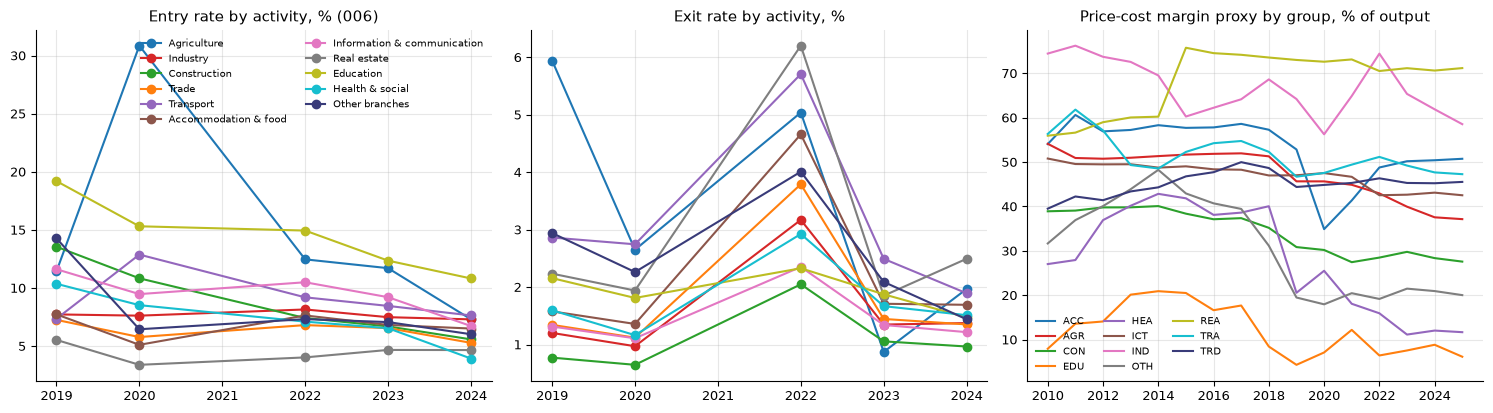

In [10]:
MKT = [s for s in SECS if s not in ('O', 'U')]
G = E006.drop('TOT', level=0).copy()
G['entry'] = G.new / G.registered * 100; G['exit'] = G.dereg / G.registered * 100
G['churn'] = G.entry + G.exit; G['net'] = G.entry - G.exit
IND_G = G[['registered', 'new', 'dereg', 'entry', 'exit', 'churn', 'net']].reset_index()
S_ = FLOWS[(FLOWS.kind == 'section') & (FLOWS.period == 'FY') & FLOWS.unit.isin(MKT)].copy()
S_['entry'] = S_.new / S_.stock * 100; S_['exit'] = S_.liq / S_.stock * 100; S_['churn'] = S_.entry + S_.exit; S_['net'] = S_.entry - S_.exit
IND_S = S_.rename(columns={'unit': 'sec'})[['sec', 'year', 'stock', 'new', 'liq', 'entry', 'exit', 'churn', 'net']]
RG['entry'] = RG.new / RG.enterprises * 100; RG['exit'] = RG.liquidated / RG.enterprises * 100
RG['churn'] = RG.entry + RG.exit; RG['net'] = RG.entry - RG.exit
REGDISP = RG.groupby('year').agg(cv_entry=('entry', lambda x: x.std() / x.mean()), cv_exit=('exit', lambda x: x.std() / x.mean()),
                                 hhi_units=('enterprises', lambda x: ((x / x.sum()) ** 2).sum() * 1e4))
SURV = (AGE.div(AGE[1], axis=0))[[2, 3, 4, 5]].rename(columns=lambda k: f'S{k}')
SURV = SURV.drop('TOT', level=0, errors='ignore')
SME = pd.concat({'sme_output_share': E012['sme'], 'sme_employment_share': E013['sme']}, axis=1).drop('TOT', level=0, errors='ignore')
SME['large_output_share'] = 100 - SME.sme_output_share
NAG = NA.reset_index(); NAG['group'] = NAG.sec.map(lambda s: SECT[s][3])
PCM_G = NAG[NAG.sec.isin(MKT)].groupby(['group', 'year'])[['GO', 'VA', 'CE']].sum()
PCM_G['PCM'] = (PCM_G.VA - PCM_G.CE) / PCM_G.GO * 100
_sh = FR10_SH[FR10_SH.series == FR10_SH.series.unique()[0]].pivot_table(index='year', columns='unit', values='value')
_mf = [c for c in _sh.columns if str(c).zfill(2) >= '10' and str(c).zfill(2) <= '33']
_m = _sh[_mf].div(_sh[_mf].sum(axis=1), axis=0)
INSTAB = (0.5 * _m.diff().abs().sum(axis=1)).loc[2006:LAST_ACT].rename('instability_manuf_branches')
_units = pd.Series({y: RG[RG.year == y].enterprises.sum() for y in RG.year.unique()})
BARR = pd.DataFrame({'licences_new': LIC_NEW, 'inspections': INSP.sum()}).loc[2015:LAST_ACT]
BARR['licences_per_1000_units'] = BARR.licences_new / _units * 1000; BARR['inspections_per_1000_units'] = BARR.inspections / _units * 1000
print('entry / exit by activity group (registered entrepreneurship subjects, % of end-year stock):')
display(G[['entry', 'exit']].unstack(1).round(2))
print('register (statistical units) by NACE section, full years:')
display(IND_S.pivot_table(index='sec', columns='year', values=['entry', 'exit']).round(2))
print(f'regions: entry {RG.entry.min():.1f}-{RG.entry.max():.1f}%, exit {RG.exit.min():.2f}-{RG.exit.max():.2f}%; '
      f'CV of regional entry rates {REGDISP.cv_entry.iloc[0]:.2f} (2021) -> {REGDISP.cv_entry.iloc[-1]:.2f} (2025)')
print(f'branch-share instability (manufacturing): mean {INSTAB.loc[2006:2015].mean()*100:.1f} pp (2006-15), {INSTAB.loc[2016:].mean()*100:.1f} pp (2016-25)')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for i, g in enumerate(GRP):
    d = G.loc[g]; ax[0].plot(d.index, d.entry, marker='o', color=PAL[i % len(PAL)], label=GROUPS[g][0])
    ax[1].plot(d.index, d.exit, marker='o', color=PAL[i % len(PAL)])
ax[0].set_title('Entry rate by activity, % (006)'); ax[1].set_title('Exit rate by activity, %'); ax[0].legend(fontsize=7, ncol=2)
_p = PCM_G.PCM.unstack(0).loc[2010:]
for i, g in enumerate(_p.columns): ax[2].plot(_p.index, _p[g], color=PAL[i % len(PAL)], label=g)
ax[2].set_title('Price-cost margin proxy by group, % of output'); ax[2].legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

## Part 8 — Concentration bounds from size-class data

Without firm data, HHI and CR4 are not observed, but the size-class counts $n_c$ (active SMEs by class and activity,
entrepreneurship `005` — the same population as the output shares; large units from the register `1_3`, 1 July 2026)
and the output shares $S_c$ (SMEs by class from `012`; large = 100 − SME share) **bound** them. Each SME class has a
per-firm share cap $u_c$ = statutory revenue ceiling / market output (micro 0.2, small 3, medium 30 mn AZN).

- **Lower bound**: equal shares within each class, $HHI_{low}=\sum_c S_c^2/n_c$; $CR4_{low}$ = the four largest firms
  under that split.
- **Upper bound (headline)**: $\sum s_i^2$ is convex, so its maximum on the box-simplex is at a vertex: in each capped
  class $\lfloor S_c/u_c\rfloor$ firms at the cap plus one with the remainder; the large class (no ceiling) at most
  $S_L^2$ — one large firm holds the whole class, the others are large by **employment** (> 250) with negligible
  revenue. $CR4_{up}$ is the matching vertex: $S_L$ plus the three largest capped firms.
- **Assumption-based variant**: if every large firm is large **by revenue** (revenue ≥ a floor *f*), the upper bounds
  become $(S_L-(n_L-1)f)^2+(n_L-1)f^2$ and $CR4 \le S_L-(n_L-4)f$. This is an **assumption** (the statutory class is
  "employees > 250 **or** revenue > 30 mn AZN"), shown with *f* = 30 and 15 mn AZN as sensitivity, not as the headline.

Where the implied average SME revenue exceeds its class ceiling (F15) the caps are dropped for that group in **all
years** (one regime per group, so projected bounds evolve continuously). The "market" is an activity group — far
wider than an antitrust market — so the bounds understate concentration in narrow product markets.

In [11]:
CAP = {'micro': 0.2, 'small': 3.0, 'medium': 30.0}            # mn AZN, statutory revenue ceilings
SIZE_G = SIZE.assign(group=[SECT[s][3] for s in SIZE.index]).loc[MKT].groupby('group').sum()
GO_G = PCM_G.GO.unstack(0)
E005 = ent_series('005', 4, ['sme', 'micro', 'small', 'medium']).astype({'sme': float, 'micro': float, 'small': float, 'medium': float})

def hhi_bounds(n, S, nL, SL, mkt, capped=True):
    '''n, S: dicts by SME class (shares 0-1); nL, SL: large class; mkt: market output, mn AZN. Shares 0-1 returned.'''
    u = {c: (CAP[c] / mkt if capped else max(S[c], 1e-12)) for c in CAP}
    low = sum(S[c] ** 2 / n[c] for c in n if n[c] > 0) + (SL ** 2 / nL if nL > 0 else 0)
    vert, up_caps = [], 0.0
    for c in CAP:
        if n[c] <= 0 or S[c] <= 0: continue
        q = min(int(np.floor(S[c] / u[c] + 1e-12)), int(n[c])); r = max(S[c] - q * u[c], 0.0)
        up_caps += q * u[c] ** 2 + (r ** 2 if q < n[c] else 0.0); vert += [u[c]] * min(q, 4) + ([r] if q < n[c] else [])
    vert = sorted(vert, reverse=True)
    eq = sorted([(SL / nL, nL)] + [(S[c] / n[c], n[c]) for c in CAP if n[c] > 0], reverse=True); c4l, k = 0.0, 4.0
    for sh, cnt in eq:
        t = min(k, cnt); c4l += t * sh; k -= t
        if k <= 0: break
    out = dict(hhi_lower=low, hhi_upper=up_caps + SL ** 2, cr4_lower=c4l, cr4_upper=min(1.0, SL + sum(vert[:3])) if nL >= 1 else sum(vert[:4]))
    for fl in (30.0, 15.0):
        f = fl / mkt
        if capped and nL >= 1 and SL >= nL * f:
            out[f'hhi_upper_floor{int(fl)}'] = up_caps + (SL - (nL - 1) * f) ** 2 + (nL - 1) * f ** 2
            out[f'cr4_upper_floor{int(fl)}'] = (SL - (nL - 4) * f) if nL >= 4 else min(1.0, SL + sum(vert[:int(4 - nL)]))
        else:
            out[f'hhi_upper_floor{int(fl)}'] = np.nan; out[f'cr4_upper_floor{int(fl)}'] = np.nan
    return out

def caps_ok(g, y, sh, mkt):
    return all((sh[c] / 100) / float(E005.loc[(g, y), c]) <= CAP[c] / mkt * (1 + 1e-9) for c in CAP if E005.loc[(g, y), c] > 0)
CAPPED = {g: all(caps_ok(g, y, E012.loc[(g, y)], GO_G.loc[y, g]) for y in [2023, 2024]) for g in GRP}
BND = []
for g in GRP:
    for y in [2023, 2024]:
        sh = E012.loc[(g, y)]; mkt = float(GO_G.loc[y, g])
        n = {c: float(E005.loc[(g, y), c]) for c in CAP}; nL = float(SIZE_G.loc[g, 'large'])
        S = {c: sh[c] / 100 for c in CAP}; SL = max(1 - sh['sme'] / 100, 0.0)
        b = hhi_bounds(n, S, nL, SL, mkt, CAPPED[g])
        BND.append(dict(group=g, year=y, market_output_mn=mkt, n_large=nL, large_share=SL * 100, caps_used=CAPPED[g],
                        **{k: v * (1e4 if k.startswith('hhi') else 100) for k, v in b.items()}))
BND = pd.DataFrame(BND); BND['number_equivalent_max'] = 1e4 / BND.hhi_lower
display(BND[BND.year == 2024].set_index('group').round(1))
chk('HHI lower <= floor variants <= headline upper; CR4 lower <= CR4 upper (all groups, years)', 0.0,
    bool(((BND.hhi_lower <= BND.hhi_upper + 1e-6) & (BND.cr4_lower <= BND.cr4_upper + 1e-6)
          & (BND.hhi_upper_floor30.isna() | ((BND.hhi_lower <= BND.hhi_upper_floor30 + 1e-6) & (BND.hhi_upper_floor30 <= BND.hhi_upper + 1e-6)))).all()))
chk('CR4 bounds consistent with HHI bounds: CR4^2/4 <= HHI_upper (all groups, years)', 0.0, bool(((BND.cr4_lower / 100) ** 2 / 4 * 1e4 <= BND.hhi_upper + 1e-6).all()))

# taxpayer size classes (DVX): economy-wide lower bound on the concentration of declared turnover (micro excluded, F8)
_d = DVXC.loc[DVXC[('large', 'turnover')].notna()]
TAXB = []
for y, r in _d.iterrows():
    T = sum(r[(c, 'turnover')] for c in ['large', 'medium', 'small'])
    S = {c: r[(c, 'turnover')] / T for c in ['large', 'medium', 'small']}; n = {c: r[(c, 'count')] for c in S}
    TAXB.append(dict(year=y, large_count=n['large'], large_turnover_share=S['large'] * 100, hhi_lower=sum(S[c] ** 2 / n[c] for c in S) * 1e4,
                     turnover_per_large_mn=r[('large', 'turnover')] / n['large'], receipts_share_large=r[('large', 'receipts')] /
                     sum(r[(c, 'receipts')] for c in ['large', 'medium', 'small']) * 100))
TAXB = pd.DataFrame(TAXB).set_index('year')
display(TAXB.round(2))
_b = BND[BND.year == 2024].set_index('group')
print(f"2024: HHI lower bound {_b.hhi_lower.min():.0f}-{_b.hhi_lower.max():.0f}; headline upper bound up to {_b.hhi_upper.max():.0f} ({_b.hhi_upper.idxmax()}); "
      f"trade CR4 {_b.loc['TRD', 'cr4_lower']:.1f}-{_b.loc['TRD', 'cr4_upper']:.1f}% (30 mn revenue floor: {_b.loc['TRD', 'cr4_upper_floor30']:.1f}%); "
      f"caps used for {sum(CAPPED.values())} of {len(CAPPED)} groups")

,year,market_output_mn,n_large,large_share,caps_used,hhi_lower,hhi_upper,cr4_lower,cr4_upper,hhi_upper_floor30,cr4_upper_floor30,hhi_upper_floor15,cr4_upper_floor15,number_equivalent_max
group,,,,,,,,,,,,,,
AGR,2024,"14,220.200",32.000,40.700,False,60.800,"3,249.900",5.100,100.000,NaN,NaN,NaN,NaN,164.400
IND,2024,"64,971.200",237.000,89.200,True,33.600,"7,957.000",1.500,89.300,"6,132.200",78.400,"7,014.800",83.800,297.200
CON,2024,"20,434.800",106.000,63.000,True,38.600,"3,972.700",2.400,63.400,"2,270.300",48.000,"3,061.600",55.500,259.300
TRD,2024,"20,988.500",208.000,33.400,True,5.700,"1,118.300",0.600,33.800,21.500,4.200,350.000,18.800,"1,765.400"
TRA,2024,"14,072.000",57.000,80.700,True,114.500,"6,513.900",5.700,81.300,"4,732.000",69.400,"5,586.700",75.100,87.400
ACC,2024,"4,639.300",25.000,21.200,True,22.200,464.800,3.400,23.100,57.600,7.600,198.500,14.400,450.100
ICT,2024,"3,781.600",34.000,63.400,True,121.600,"4,037.200",7.500,65.800,"1,423.800",39.600,"2,553.900",51.500,82.200
REA,2024,"5,697.300",14.000,46.500,True,163.100,"2,175.700",13.300,48.100,"1,589.500",41.200,"1,870.000",43.900,61.300
EDU,2024,"5,471.400",19.000,13.900,False,12.700,"5,484.100",2.900,100.000,NaN,NaN,NaN,NaN,788.500


,large_count,large_turnover_share,hhi_lower,turnover_per_large_mn,receipts_share_large
year,,,,,
2022,846.000,69.280,5.800,84.760,72.780
2023,927.000,68.320,5.150,86.630,76.310
2024,985.000,68.230,4.840,88.520,73.280
2025,"1,026.000",68.500,4.680,88.170,70.780


2024: HHI lower bound 6-163; headline upper bound up to 7957 (IND); trade CR4 0.6-33.8% (30 mn revenue floor: 4.2%); caps used for 8 of 11 groups


## Part 9 — Which data, from which source, for which indicator, in which form

### 9.1 Data-source matrix

One row per indicator (`output/FR12_data_source_matrix.csv`). Status: **available now** (in FR12 today),
**requested** (in the 24 Aug 2026 data request, not received), **not available** (no source identified; alternative given).

In [12]:
MX = []
def yrs(s):
    s = sorted(set(int(y) for y in s)); return f'{s[0]}-{s[-1]}' + ('' if len(s) == s[-1] - s[0] + 1 else f' ({len(s)} yrs: {", ".join(map(str, s))})')
DL, WB_, AR, FR = 'file download (DSK website, scripted)', 'workbook upload (Ministry)', 'archived DSK vintages (scripted)', 'MIIS internal (FR module output)'
REQ = 'data-sharing agreement with DSK (business register extract)'
def mrow(p, az, en, formula, unit, inst, table, gran, freq, years, status, integ, use, form, upd, alt):
    MX.append(dict(pillar=p, indicator_az=az, indicator_en=en, formula=formula, unit=unit, source_institution=inst, dataset_table_row=table,
                   granularity=gran, frequency=freq, years_available_now=years, status=status, integration_into_MIIS=integ,
                   analytical_use=use, presentation_form=form, update_frequency=upd, alternative_if_unavailable=alt))
gy = E006.index.get_level_values(1)
P1, P2, P3, P4, P5 = 'Entry and exit', 'Concentration and intensity', 'Margins and market power', 'Barriers and regulation', 'Firm level (Layer B)'
mrow(P1, 'Giriş əmsalı (fəaliyyət növləri)', 'Entry rate by activity group', 'newly registered / registered (end-year) × 100; births modelled as a log flow, rate via the stock identity', '%; units', 'DSK', 'entrepreneurship 006 (+ archived vintages; definition change 2022, F17)', '11 activity groups', 'annual', yrs(gy), 'available now', AR, 'structural births model (Part 11-13)', 'time-series chart with forecast fan', 'annual', '-')
mrow(P1, 'Çıxış əmsalı (fəaliyyət növləri)', 'Exit rate by activity group', 'deregistered / registered × 100', '%', 'DSK', 'entrepreneurship 006', '11 activity groups', 'annual', yrs(gy), 'available now', AR, 'structural exit model', 'time-series chart with forecast fan', 'annual', '-')
mrow(P1, 'Xalis giriş, dövriyyə (churn)', 'Net entry and churn', 'entry − exit; entry + exit', 'pp', 'DSK', 'entrepreneurship 006', '11 activity groups', 'annual', yrs(gy), 'available now', AR, 'early warning', 'dashboard KPI card', 'annual', '-')
mrow(P1, 'Statistik vahidlərin yaranması/ləğvi (bölmələr)', 'New / liquidated statistical units by NACE section', 'new or liquidated / units at period end', '%', 'DSK', 'st_units 2_1 (+ vintages)', '19 NACE sections', 'annual, half-year', '2021, 2024, 2025 (FY); H1 2022, 2024-2026', 'available now', AR, 'section monitoring; Layer-B calibration', 'heat map section × year', 'semi-annual', '-')
mrow(P1, 'Regionlar üzrə giriş və çıxış', 'Entry and exit by economic region', 'new or liquidated / units', '%', 'DSK via workbook', "workbook 'Regionlar*' r38/r42/r43; st_units 2_3", '14 regions', 'annual', yrs(RG.year), 'available now', WB_, 'regional entry/exit model; heat map', 'map; region × year heat map', 'annual', '-')
mrow(P1, 'Kohort ölçüsü nisbəti (1-5 il)', 'Cohort-size ratio, ages 1-5 (not a survival rate)', 'active SMEs aged k / aged 1 in the same year (mixes cohort size and survival)', 'ratio', 'DSK', 'entrepreneurship 024-028', '11 groups × size', 'annual', '2023-2024', 'available now', DL, 'information only (not in the early-warning composite)', 'table', 'annual', 'Kaplan-Meier survival by cohort from the register (Layer B)')
mrow(P1, 'Fəal müəssisələrin sayı (proqnoz)', 'Number of active units (forecast)', 'N(t) = (N(t−1) + births(t)) / (1 + exit rate(t)) (stock-flow identity)', 'units', 'derived', 'Part 13', 'groups, regions', 'annual', '2026-2030', 'available now', FR, 'forecast', 'forecast fan', 'annual', '-')
mrow(P2, 'KOS-un buraxılışda payı', 'SME share of output', 'SME output / total × 100', '%', 'DSK', 'entrepreneurship 012 (+ vintages)', '11 groups × micro/small/medium', 'annual', yrs(E012.index.get_level_values(1)), 'available now', AR, 'concentration bounds; share projection', 'stacked bar; trend', 'annual', '-')
mrow(P2, 'KOS-un məşğulluqda payı', 'SME share of employees', 'SME employees / total × 100', '%', 'DSK', 'entrepreneurship 013 (+ vintages)', '11 groups × size', 'annual', yrs(E013.index.get_level_values(1)), 'available now', AR, 'size structure', 'stacked bar', 'annual', '-')
mrow(P2, 'Ölçü qrupları üzrə müəssisələr', 'Units by size class', 'count', 'units', 'DSK', 'st_units 1_3, 1_4; entrepreneurship 005', 'section / region × size', 'snapshot (1 July 2026); 2023-2024', '2026 snapshot; 2023-2024', 'available now', DL, 'concentration bounds; Layer-B calibration', 'table', 'semi-annual', '-')
mrow(P2, 'HHI/CR4 hədləri (ölçü qrupları)', 'HHI / CR4 bounds from size classes', 'lower Σ S²/n; upper vertex of the box-simplex (Part 8)', 'index 0-10000; %', 'derived (DSK)', 'Part 8', '11 groups', 'annual', '2023-2024', 'available now', FR, 'concentration monitoring; early warning', 'concentration bounds chart (range bars)', 'annual', 'firm-level HHI (Layer B)')
mrow(P2, 'Vergi ödəyicilərinin ölçü qrupları', 'Taxpayer size classes: count, turnover, receipts, employees', 'large share of declared turnover; HHI lower bound', '%; index', 'DVX', "workbook 'DVX üzrə göstəricilər' r111-r126", 'economy, 4 classes', 'annual', yrs(DVXC.dropna(how='all').index), 'available now', WB_, 'economy-wide concentration', 'KPI card; trend', 'annual', '-')
mrow(P2, 'Sahələr üzrə aktiv vergi ödəyiciləri', 'Active taxpayers by sector', 'count', 'units', 'DVX', "workbook 'DVX üzrə göstəricilər' r131-r145", '5 sectors (others empty)', 'annual', yrs(TAXP.dropna(how='all').index), 'available now', WB_, 'cross-check of entry dynamics', 'table', 'annual', 'register counts (DSK)')
mrow(P2, 'Sahə paylarının qeyri-sabitliyi', 'Share instability across branches', '½ Σ|Δs|', 'pp', 'FR10', 'FR10_branch_shares_history.csv', '24 manufacturing branches', 'annual', '2006-2025', 'available now', FR, 'early warning (falling mobility)', 'trend', 'annual', '-')
mrow(P2, 'Regional dispersiya', 'Regional dispersion of entry; HHI of units across regions', 'CV; Σ s²', 'ratio; index', 'derived', 'Part 7', '14 regions', 'annual', yrs(RG.year), 'available now', FR, 'regional monitoring', 'map', 'annual', '-')
mrow(P3, 'Qiymət-xərc marjası (proxy)', 'Price-cost margin proxy', '(VA − compensation) / output × 100', '%', 'DSK', 'national accounts 013', '19 sections / 11 groups', 'annual', yrs(NA.index.get_level_values(1)), 'available now', DL, 'entry-model driver; early warning (margins up, entry down)', 'trend; quadrant', 'annual', '-')
mrow(P3, 'Sənaye marjası (FR10 proqnozu)', 'Industry margin path (FR10 section forecasts)', '(VA − compensation) / output, B-E', '%', 'FR10', 'FR10_forecast_sections.csv', 'sections B-E', 'annual', '2025-2030', 'available now', FR, 'margin driver path for industry if a rule selects the margin; the current rules do not, so it is not used in this run', 'trend', 'annual', '-')
mrow(P3, 'Lerner indeksi (ssenari)', 'Lerner index (scenario calibration)', 'HHI / ε (Cournot)', 'ratio', 'derived', 'Part 15', 'sector', 'on demand', '-', 'available now', FR, 'scenario simulator', 'simulator with assumptions panel', 'on demand', '-')
mrow(P4, 'Verilmiş lisenziyalar', 'Licences issued', 'count; per 1000 units', 'number', 'Ministry of Economy', "workbook 'Verilmiş lisenziyalar'", '24 licence types → groups', 'annual', yrs(LIC_G.index), 'available now', WB_, 'entry indicator (information; not a barrier flag)', 'trend; table', 'annual', '-')
mrow(P4, 'Aparılan yoxlamalar', 'Inspections of businesses (coverage changes over time, F18)', 'count', 'number', 'inspection bodies', "workbook 'Aparılan yoxlamalar'", '19 bodies', 'annual', '2015-2025 (not comparable across years)', 'available now', WB_, 'information only', 'table', 'annual', 'inspection register with NACE codes and constant coverage')
mrow(P4, 'Dövlət mülkiyyətinin payı', 'State share: of industrial output (S5 calibration); of active SMEs (information)', 'state output / output; state SMEs / active SMEs', '%', 'DSK', 'industry 010_2 via FR10_ownership.csv (output, 2005-2025); entrepreneurship 005 (SMEs, 2023-2024)', 'industry; 11 groups', 'annual', '2005-2025; 2023-2024', 'available now', DL, 'mixed-oligopoly scenario (S5); information', 'bar', 'annual', 'SOE revenue share by market from the register (Layer B)')
mrow(P4, 'İdxal rəqabəti (daxili bazarda payı)', 'Import penetration by product group', 'imports / (output − exports + imports)', '%', 'DGK / DSK', 'customs data by HS × NACE', 'sector', 'annual', '-', 'not available', 'data-sharing agreement with the State Customs Committee', 'tariff / import-competition scenario', 'simulator input', 'annual', 'FR5/FR1 import aggregates; literature fringe shares')
for f, en, az in [('revenue', 'Firm revenue (market shares, HHI, CR4/CR8, entropy, Gini)', 'Müəssisə gəliri (bazar payları, HHI)'),
                  ('registration_date / liquidation_date', 'Firm entry and exit dates (entry/exit, survival, cohort shares)', 'Qeydiyyat və ləğv tarixləri'),
                  ('cost_of_sales / operating_costs', 'Firm costs (price-cost margin, Boone indicator)', 'Xərclər (marja, Boone indikatoru)'),
                  ('ownership, region, size_class', 'Firm attributes (SOE share, region × sector view)', 'Mülkiyyət, region, ölçü')]:
    mrow(P5, az, en, 'Part 17 engine', 'thsd AZN / dates', 'DSK', f'business register: {f}', 'firm × NACE × region × year', 'annual', 'SYNTHETIC only', 'requested', REQ,
         'Layer-B competition engine', 'firm-level market structure view', 'annual', 'Layer-A bounds and rates (this module)')
MATRIX = pd.DataFrame(MX); MATRIX.insert(0, 'id', [f'I{i+1:02d}' for i in range(len(MATRIX))])
MATRIX['status_group'] = MATRIX.status
MATRIX.to_csv(OUT / 'FR12_data_source_matrix.csv', index=False)
display(MATRIX.groupby(['pillar', 'status']).size().unstack(fill_value=0))

status,available now,not available,requested
pillar,,,
Barriers and regulation,3,1,0
Concentration and intensity,8,0,0
Entry and exit,7,0,0
Firm level (Layer B),0,0,4
Margins and market power,3,0,0


### 9.2 Gaps, alternatives and actions; 9.3 the MIIS user views

In [13]:
GAPS = pd.DataFrame([
 ('Firm-level revenue by NACE × region (DSK business register)', 'no firm HHI/CR4, no market-share mobility, no Boone indicator',
  'size-class concentration bounds (Part 8); branch-share instability from FR10', 'bounds are wide where SMEs dominate; activity groups are broader than antitrust markets',
  'confirm the register extract (requested 24 Aug 2026); agree pseudonymised firm_id and annual delivery'),
 ('Firm entry and exit dates', 'no cohort survival, no entrant/exiter size', 'DSK 006 registration flows; 024-028 age structure; register flows 2_1/2_3',
  '006 counts registrations incl. individual entrepreneurs, not market entry; register exit understates exit (F14)', 'include registration/liquidation dates in the register extract'),
 ('Long time series of entry/exit by activity', 'only 5 annual observations per group (2019-2024, no 2021); low test power',
  'archived DSK vintages (Part 4)', 'definitions changed between vintages ("newly created" → "newly registered")', 'ask DSK for the 2010-2025 series of table 006 and 2_1 in one consistent vintage'),
 ('Firm costs (cost of sales, operating costs)', 'no firm price-cost margin or Boone indicator', 'section PCM proxy from national accounts', 'aggregate PCM mixes capital returns with rents',
  'link the FR10 Tax Service panel by firm_id, or add cost fields to the register extract'),
 ('Import penetration by sector', 'import-competition scenarios need a domestic-share calibration', 'literature fringe shares; FR1/FR5 aggregate imports', 'not sector-specific',
  'customs HS × NACE concordance from the State Customs Committee'),
 ('Narrow product markets', 'activity groups understate concentration in product markets', 'FR10 product location shares; licence types', 'partial coverage',
  'agree priority markets (fuel, cement, telecom, pharmaceuticals, retail chains) for product-level data'),
 ('Licensing and inspections by NACE', 'barrier proxies mapped to groups by licence type', 'mapping of 24 licence types to 11 groups (Part 5)', 'several types are cross-sector',
  'request licence and inspection registers with NACE codes'),
 ('DVX micro-taxpayer rows', 'micro rows duplicate budget organisations (F8)', 'micro excluded from DVX concentration', 'economy-wide bound slightly overstated',
  'Tax Service to correct rows r123-r126')],
 columns=['gap', 'impact', 'alternative_used_now', 'bias_or_limitation_of_alternative', 'action_to_agree_with_Customer'])
GAPS.to_csv(OUT / 'FR12_data_gaps_and_alternatives.csv', index=False)
PRES = pd.DataFrame([
 ('V1', 'Competition dashboard by sector', 'KPI cards per activity group: entry, exit, churn, net entry, PCM proxy, HHI bounds, early-warning score', 'FR12_indicators_groups.csv, FR12_concentration_bounds.csv, FR12_early_warning.csv', 'annual'),
 ('V2', 'Entry/exit dynamics with forecast fan', 'history 2019-2025 and 2026-2030 under three FR1 scenarios with 5-95% bands; stock of active units', 'FR12_forecast_entry_exit.csv, FR12_fan_entry_exit.csv', 'annual'),
 ('V3', 'Region × sector heat map', 'entry and exit rates by region (2021-2025) and by NACE section; forecasts by region', 'FR12_indicators_regions.csv, FR12_indicators_sections.csv, FR12_forecast_entry_exit.csv (panel = region)', 'annual'),
 ('V4', 'Concentration bounds chart', 'range bars [lower, upper] for HHI and CR4 by group; projected bounds 2026-2030', 'FR12_concentration_bounds.csv, FR12_concentration_paths.csv', 'annual'),
 ('V5', 'Scenario simulator with assumptions panel', 'Cournot toolkit: entry, merger, cost/tax, import, SOE scenarios; Δprice, Δmarkup, Δoutput, ΔCS, ΔPS with elasticity ranges', 'FR12_scenario_*.csv', 'on demand'),
 ('V6', 'Early-warning list', 'flags per sector, composite score, watch list, insufficient-data markers', 'FR12_early_warning.csv', 'annual'),
 ('V7', 'Firm-level market structure view (Layer B)', 'HHI, CR4/CR8, entropy, Gini, share mobility, survival curves, Boone by NACE × region; SYNTHETIC watermark until the register arrives', 'FR12_SYNTHETIC_*.csv → FR12_FIRM_*.csv', 'annual')],
 columns=['view', 'name', 'content', 'feeding_csv', 'refresh'])
PRES.to_csv(OUT / 'FR12_presentation_spec.csv', index=False)
display(GAPS[['gap', 'alternative_used_now']]); display(PRES[['view', 'name', 'feeding_csv']])
print(f"source matrix: {len(MATRIX)} indicators ({', '.join(f'{k} {v}' for k, v in MATRIX.status.value_counts().items())}); "
      f'{len(GAPS)} gaps; {len(PRES)} MIIS views')

,gap,alternative_used_now
0,Firm-level revenue by NACE × region (DSK busin...,size-class concentration bounds (Part 8); bran...
1,Firm entry and exit dates,DSK 006 registration flows; 024-028 age struct...
2,Long time series of entry/exit by activity,archived DSK vintages (Part 4)
3,"Firm costs (cost of sales, operating costs)",section PCM proxy from national accounts
4,Import penetration by sector,literature fringe shares; FR1/FR5 aggregate im...
5,Narrow product markets,FR10 product location shares; licence types
6,Licensing and inspections by NACE,mapping of 24 licence types to 11 groups (Part 5)
7,DVX micro-taxpayer rows,micro excluded from DVX concentration


,view,name,feeding_csv
0,V1,Competition dashboard by sector,"FR12_indicators_groups.csv, FR12_concentration..."
1,V2,Entry/exit dynamics with forecast fan,"FR12_forecast_entry_exit.csv, FR12_fan_entry_e..."
2,V3,Region × sector heat map,"FR12_indicators_regions.csv, FR12_indicators_s..."
3,V4,Concentration bounds chart,"FR12_concentration_bounds.csv, FR12_concentrat..."
4,V5,Scenario simulator with assumptions panel,FR12_scenario_*.csv
5,V6,Early-warning list,FR12_early_warning.csv
6,V7,Firm-level market structure view (Layer B),FR12_SYNTHETIC_*.csv → FR12_FIRM_*.csv


source matrix: 26 indicators (available now 21, requested 4, not available 1); 8 gaps; 7 MIIS views


## Part 10 — The no-autoregression constraint

FR12 forecasts no variable from its own past. Every construct that involves a time lag or a previous value is listed
here with the reason it is not an autoregression (`output/FR12_noar_constructs.csv`).

In [14]:
NOAR = pd.DataFrame([
 ('Stock of active units N(t)', 'N(t) = (N(t−1) + births(t)) / (1 + exit rate(t)), i.e. N(t) = N(t−1) + B(t) − D(t) with D on the end-year stock',
  'accounting identity (like FR1\'s capital stock): births and the exit rate are forecast structurally, the stock is their sum', 'identity'),
 ('Entry rate', 'births(t) / N(t)', 'derived from the births forecast and the identity stock; never modelled on its own past', 'identity'),
 ('Anchoring on the last residual (add-factor)', 'forecast = model + (y_last − fitted_last); implied weight on the last observation 1 (0.5 in a combination)',
  'the FR1–FR10 add-factor convention: the last residual is held constant, no dynamics are estimated; the implied random-walk weight of every rule is reported in Part 12', 'model'),
 ('Definition break and impulses', 'brk = 1 from 2022 (006 definition change); 2022 exit impulse', 'deterministic dummies, not lags', 'model'),
 ('Sector demand growth Δln VA(t)', 'growth rate of an FR1 driver', 'a transformation of an exogenous driver, not of the dependent variable', 'driver'),
 ('First-difference coherence check', 'Δentry(t) on Δdrivers(t)', 'diagnostic only: the forecast never uses the lagged rate', 'diagnostic'),
 ('Random-walk benchmark', 'entry(t+h) = entry(t)', 'benchmark only, required by NFR1; never used as the forecast', 'benchmark'),
 ('Constant (mean) rate benchmark / null', 'unit mean over the estimation window', 'the unit fixed effect itself: a level, not a dynamic', 'benchmark / combination partner'),
 ('Unit fixed effects', 'a_i estimated on the training window', 'time-invariant intercepts, no dynamics', 'model'),
 ('Uncertainty bands', 'historical residual pairs e_h = w(u_{s+h} − u_s) + (1 − w)u_{s+h}, joint across units and equations; parameter draws; FR1 draws', 'resampled historical errors; no residual AR is estimated or imposed', 'bands'),
 ('Synthetic register (Layer B)', 'firm size evolves by a stated data-generating process', 'test data only; the engine estimates no dynamic model', 'test data')],
 columns=['construct', 'form', 'why_not_autoregressive', 'role'])
NOAR.to_csv(OUT / 'FR12_noar_constructs.csv', index=False)
display(NOAR[['construct', 'role']])

,construct,role
0,Stock of active units N(t),identity
1,Entry rate,identity
2,Anchoring on the last residual (add-factor),model
3,Definition break and impulses,model
4,Sector demand growth Δln VA(t),driver
5,First-difference coherence check,diagnostic
6,Random-walk benchmark,benchmark
7,Constant (mean) rate benchmark / null,benchmark / combination partner
8,Unit fixed effects,model
9,Uncertainty bands,bands


## Part 11 — The entry/exit panels and the structural models

Two panels carry a time dimension: the **activity panel** (11 DSK groups × 2019, 2020, 2022, 2023, 2024; registered
entrepreneurship subjects, 006) and the **region panel** (14 economic regions × 2021–2025; statistical units).

**Entry is modelled as a flow**, not a rate: the log of new registrations (creations), with unit fixed effects and
no lagged dependent variable, $\ln B_{it} = a_i + \sum_k b_k x_{k,it} + \delta\,\mathrm{brk}_t + u_{it}$. The entry
*rate* then follows from the stock-flow identity, $e_t = B_t/N_t$ with $N_t = (N_{t-1}+B_t)/(1+x_t)$, so it falls
as the stock grows unless births grow as fast. A rate model with a constant unit mean cannot do that (the artefact
found in review). **Exit** stays a rate model, $x_{it} = a_i + \sum_k b_k x_{k,it} + u_{it}$ (deaths scale with the
stock). Activity panel: `brk` = 1 from 2022, the DSK definition change in 006 ("newly created / liquidated" up to
2020 → "newly registered / deregistered" from 2022, finding F17); the exit equation carries a 2022 impulse (F16:
the 2023–2024 exit levels are close to 2019–2020, so no persistent break is evident). The agricultural 2020
registration wave (F7) is excluded.

Candidate drivers — activity: sector demand growth `dem` (FR1 real VA of the group's sector, % change), sector size
`size` (log real VA), lending rate `lend`, real credit growth `cred` (FR1), price-cost margin proxy `pcm`. Region:
regional industrial output growth `reg` and size `size` (FR10), non-oil GDP growth `non`, lending rate `lend` (FR1).
National drivers vary only over time, so year effects cannot be added. Inference: with T = 5 years, Driscoll–Kraay
t(T−1) p-values are unreliable and are **not reported**; the table gives the **wild cluster bootstrap** p-value
(Webb six-point weights, clusters = years, null imposed, B = 499). With 5 clusters it is coarse; the estimates are
descriptive.

In [15]:
def dln(s): return np.log(s).diff() * 100
FR1X = pd.DataFrame({'lend': FR1H.lendrate, 'cred': dln(FR1H.rcred_tot), 'non': dln(FR1H.rgdpnon)})
VAH = pd.DataFrame({g: FR1H[GROUPS[g][2]].sum(axis=1) for g in GRP})
PA = []
for (g, y), r in G.iterrows():
    PA.append(dict(unit=g, year=y, B=r.new, D=r.dereg, N=r.registered, entry=r.entry, exit=r.exit, dem=dln(VAH[g]).get(y),
                   lend=FR1X.lend.get(y), cred=FR1X.cred.get(y), pcm=PCM_G.PCM.get((g, y)), size=np.log(VAH[g]).get(y)))
PA = pd.DataFrame(PA)
PA['lnB'] = np.log(PA.B); PA['brk'] = (PA.year >= 2022).astype(float); PA['d2022'] = (PA.year == 2022).astype(float)
PA.loc[(PA.unit == 'AGR') & (PA.year == 2020), ['lnB', 'entry']] = np.nan        # F7: administrative farm-registration wave
_rgo = FR10_REGH.pivot_table(index='year', columns='region', values='value')
PR = RG[['region', 'year', 'new', 'liquidated', 'enterprises', 'entry', 'exit']].rename(columns={'region': 'unit', 'new': 'B', 'liquidated': 'D', 'enterprises': 'N'}).copy()
PR['lnB'] = np.log(PR.B)
PR['reg'] = [dln(_rgo[u]).get(y) for u, y in zip(PR.unit, PR.year)]
PR['size'] = [np.log(_rgo[u]).get(y) for u, y in zip(PR.unit, PR.year)]
PR['non'] = PR.year.map(FR1X.non); PR['lend'] = PR.year.map(FR1X.lend)
assert PA[['dem', 'lend', 'cred', 'pcm', 'size']].notna().all().all() and PR[['reg', 'non', 'lend', 'size']].notna().all().all()
SPA = [[], ['size'], ['dem'], ['size', 'dem'], ['size', 'lend'], ['size', 'cred'], ['dem', 'lend'], ['pcm'], ['size', 'pcm']]
SPX = [[], ['dem'], ['dem', 'pcm'], ['dem', 'cred'], ['lend'], ['cred'], ['size']]
SPR = [[], ['reg'], ['size'], ['reg', 'size'], ['non'], ['non', 'lend'], ['reg', 'lend']]
MODELS = {
 ('activity', 'lnB'): dict(df=PA, fixed=['brk'], specs=SPA, sel=(2022, [2023]), hold=[(2022, [2024]), (2023, [2024])], scale='log births'),
 ('activity', 'exit'): dict(df=PA, fixed=['d2022'], specs=SPX, sel=(2022, [2023]), hold=[(2022, [2024]), (2023, [2024])], scale='exit rate, %'),
 ('region', 'lnB'): dict(df=PR, fixed=[], specs=SPR, sel=(2022, [2023]), hold=[(2023, [2024, 2025]), (2024, [2025])], scale='log births'),
 ('region', 'exit'): dict(df=PR, fixed=[], specs=SPR, sel=(2022, [2023]), hold=[(2023, [2024, 2025]), (2024, [2025])], scale='exit rate, %')}
PANELS = {'activity': PA, 'region': PR}

def fit_fe(df, dep, regs, fixed=()):
    fixed = [c for c in fixed if c in df]
    d = df.dropna(subset=[dep] + regs + fixed)
    fx = [c for c in fixed if d[c].std() > 0]
    allr = list(regs) + fx
    if not allr:
        a = d.groupby('unit')[dep].mean()
        return dict(regs=[], b=np.zeros(0), V=np.zeros((0, 0)), fixed=[], bf=np.zeros(0), a=a, resid=d[dep] - d.unit.map(a), fit=None, d=d)
    f = panel_fe(d, dep, allr, entity='unit', time='year', twoway=False)
    Xa = d[allr].to_numpy(float)
    a = (d[dep] - Xa @ f.beta).groupby(d.unit).mean()
    k = len(regs)
    return dict(regs=list(regs), b=f.beta[:k], V=f.V[:k, :k], fixed=fx, bf=f.beta[k:], a=a, resid=d[dep] - d.unit.map(a) - Xa @ f.beta, fit=f, d=d)

def predict(m, rows, b=None):
    b = m['b'] if b is None else b
    p = rows.unit.map(m['a']).to_numpy(float)
    if m['regs']: p = p + rows[m['regs']].to_numpy(float) @ b
    if m['fixed']: p = p + rows[m['fixed']].to_numpy(float) @ m['bf']
    return p

def spec_name(s): return 'null (FE + fixed terms)' if not s else 'FE + ' + ' + '.join(s)

FULL = []
for (pn, dep), M in MODELS.items():
    for s in M['specs'][1:]:
        m = fit_fe(M['df'], dep, s, M['fixed'])
        d_ = m['d']; regs_all = s + m['fixed']
        for j, x in enumerate(s):
            p_w, t_w = wild_cluster_p(d_, dep, regs_all, x, entity='unit', time='year', twoway=False, B=499, seed=SEED + j)
            FULL.append(dict(panel=pn, dep=dep, spec=spec_name(s), driver=x, coef=m['b'][j], se_DK=m['fit'].se[j], wcb_p=p_w, T=m['fit'].nT, n=m['fit'].n))
FULL = pd.DataFrame(FULL)
print('full-sample FE estimates (descriptive; wild cluster bootstrap p by year, Webb, B = 499; DK p-values not reported with T = 5):')
display(FULL.round(3))

full-sample FE estimates (descriptive; wild cluster bootstrap p by year, Webb, B = 499; DK p-values not reported with T = 5):


,panel,dep,spec,driver,coef,se_DK,wcb_p,T,n
0,activity,lnB,FE + size,size,0.191,0.204,0.423,5,54
1,activity,lnB,FE + dem,dem,0.003,0.001,0.242,5,54
2,activity,lnB,FE + size + dem,size,-0.020,0.311,0.944,5,54
3,activity,lnB,FE + size + dem,dem,0.003,0.002,0.415,5,54
4,activity,lnB,FE + size + lend,size,0.212,0.188,0.411,5,54
5,activity,lnB,FE + size + lend,lend,-0.125,0.088,0.399,5,54
6,activity,lnB,FE + size + cred,size,0.254,0.198,0.401,5,54
7,activity,lnB,FE + size + cred,cred,-0.002,0.001,0.481,5,54
8,activity,lnB,FE + dem + lend,dem,0.003,0.001,0.156,5,54
9,activity,lnB,FE + dem + lend,lend,-0.134,0.068,0.351,5,54


## Part 12 — Pre-cut selection, untouched hold-out, both benchmarks (NFR1)

A **rule** is a procedure — (driver set, anchoring, mode) plus the coherence filter — re-applied at every origin on
data up to that origin. The hold-out and the forecast use the **same procedure** (same anchoring, same fallback),
so the forecast is exactly the rule that was validated.

- **Selection** (data ≤ 2022 only): estimate on years ≤ 2022, score 2023. Candidates: every driver set, unanchored
  (fixed-effect level) or **anchored on the last residual** (the FR1–FR10 add-factor convention). The best candidate
  replaces the null if its loss is lower and a paired test across units rejects equal accuracy at 10%; if lower but
  not significant, the forecast is the equal-weight **combination** with the null; otherwise the null. The table
  reports each rule's **implied weight on the last observation** (random-walk weight): 1 for an anchored rule, 0.5 for
  a combination of an anchored model and the null, 0 for unanchored rules. Shrinkage: with ≤ 3 pre-cut years per unit
  it is not identified; pooled slopes (κ = 0), fixed before the cut.
- **Coherence rule**: a driver whose within slope lies outside the 95% CI of its first-difference estimate is
  dropped. It is applied only where the training sample has ≥ 2 transitions per unit; with fewer (region panel at
  the 2022 origin: 2021→2022 only) it is vacuous and is reported as **not applied**, not as passed.
- **Hold-out** (never used for a choice): activity — origins 2022 and 2023, target 2024; region — origins 2023
  (targets 2024, 2025) and 2024 (target 2025). Realised FR1/FR10 drivers (conditional forecasts, as in FR10); every
  constant re-estimated at each origin. Entry is scored as the **entry rate** built with the identity from the
  forecast births and the exit rule's forecast deaths, starting from the stock at the origin (no realised
  endogenous outcome enters), and also as log births. Benchmarks: random walk (last observed value) and constant
  (unit mean over the training years). DM/HLN: the target years are too few (1–2) for a test across target years,
  so the test is **paired across units** (losses averaged by unit over overlapping origins); it ignores common
  year shocks and its p-values are indicative only.

In [16]:
def coherence_filter(tr, dep, spec, fixed):
    if not spec: return [], []
    d = tr.dropna(subset=[dep] + spec).sort_values(['unit', 'year']).copy()
    ntr = d.groupby('unit').size().median() - 1
    if ntr < 2:
        return list(spec), [dict(driver=c, status=f'not applied (vacuous: {int(ntr)} transition per unit)') for c in spec]
    m = fit_fe(d, dep, spec, fixed); fx = [c for c in fixed if c in d and d[c].std() > 0]
    for c in [dep] + spec + fx: d['d_' + c] = d.groupby('unit')[c].diff()
    d = d.dropna(subset=['d_' + dep])
    fx = [c for c in fx if d['d_' + c].std() > 0]
    fd = ols(d['d_' + dep], d[['d_' + c for c in spec + fx]], cov='hc1', add_const=False)
    tq = stats.t.ppf(0.975, fd.dof); keep, rec = [], []
    for j, c in enumerate(spec):
        lo, hi = fd.beta[j] - tq * fd.se[j], fd.beta[j] + tq * fd.se[j]; ok = lo <= m['b'][j] <= hi
        rec.append(dict(driver=c, fe=float(m['b'][j]), fd=float(fd.beta[j]), fd_lo=float(lo), fd_hi=float(hi), status='coherent' if ok else 'dropped (incoherent)', transitions=int(ntr)))
        if ok: keep.append(c)
    return keep, rec

def anchor_shift(m, tr, dep):
    last = m['d'].sort_values('year').groupby('unit').tail(1)
    return pd.Series(last[dep].to_numpy(float) - predict(m, last), index=last.unit.values)

def apply_rule(key, rule, origin, rows, log=None):
    M = MODELS[key]; df, fixed, dep = M['df'], M['fixed'], key[1]
    tr = df[df.year <= origin]
    spec, rec = coherence_filter(tr, dep, rule['spec'], fixed) if rule['mode'] != 'null' else ([], [])
    if log is not None:
        for r in rec: log.append(dict(key=str(key), origin=origin, **r))
    m0 = fit_fe(tr, dep, [], fixed); p0 = predict(m0, rows)
    out = dict(p0=p0, spec=spec, m0=m0, m1=None, shift=None, w_rw=0.0)
    if rule['mode'] == 'null' or not spec:
        out['pred'] = p0; return out
    m1 = fit_fe(tr, dep, spec, fixed); p1 = predict(m1, rows)
    if rule['anchor'] == 'last':
        out['shift'] = anchor_shift(m1, tr, dep); p1 = p1 + rows.unit.map(out['shift']).to_numpy(float)
    wt = 1.0 if rule['mode'] == 'structural' else 0.5
    out.update(m1=m1, p1=p1, wt=wt, pred=wt * p1 + (1 - wt) * p0, w_rw=wt * (rule['anchor'] == 'last'))
    return out

def rname(r): return 'null (FE + fixed terms)' if r['mode'] == 'null' else f"{r['mode']}: {spec_name(r['spec'])}" + (' | anchored' if r['anchor'] == 'last' else '')

SELECT, SELTAB, COHLOG = {}, [], []
def select_rule(key):
    M = MODELS[key]
    df = M['df']; dep = key[1]; o, tg = M['sel']
    rows = df[df.year.isin(tg)].dropna(subset=[dep]); act = rows[dep].to_numpy(float)
    losses = {}
    for s in M['specs']:
        for an in (['fe'] if not s else ['fe', 'last']):
            r = dict(spec=s, anchor=an, mode='null' if not s else 'structural')
            pr = apply_rule(key, r, o, rows, COHLOG)['pred']; losses[(tuple(s), an)] = pd.Series((pr - act) ** 2, index=rows.unit.values)
            SELTAB.append(dict(panel=key[0], dep=dep, candidate=rname(r), sel_mse=float(np.mean((pr - act) ** 2)), n=len(act)))
    null_l = losses[((), 'fe')]
    bk = min([k for k in losses if k[0]], key=lambda k: losses[k].mean())
    _, pv = dm_hln(losses[bk].values, null_l.values, h=1)
    mode = ('structural' if pv <= 0.10 else 'combination') if losses[bk].mean() < null_l.mean() else 'null'
    rule = dict(spec=list(bk[0]) if mode != 'null' else [], anchor=bk[1] if mode != 'null' else 'fe', mode=mode)
    SELECT[key] = dict(rule=rule, best=rname(dict(spec=list(bk[0]), anchor=bk[1], mode='structural')), dm_p=pv,
                       w_rw=(1.0 if mode == 'structural' else 0.5 if mode == 'combination' else 0.0) * (rule['anchor'] == 'last'),
                       train_years=int(df[df.year <= o].year.nunique()))
for key in MODELS: select_rule(key)
def selsum():
    return pd.DataFrame([dict(panel=k[0], dep=k[1], rule=rname(v['rule']), best_candidate=v['best'], dm_p_vs_null=v['dm_p'],
                              implied_rw_weight=v['w_rw'], train_years=v['train_years']) for k, v in SELECT.items()])
display(selsum().round(3))

,panel,dep,rule,best_candidate,dm_p_vs_null,implied_rw_weight,train_years
0,activity,lnB,combination: FE + dem | anchored,structural: FE + dem | anchored,0.173,0.500,3
1,activity,exit,null (FE + fixed terms),structural: FE + dem + pcm,0.828,0.000,3
2,region,lnB,combination: FE + reg + lend | anchored,structural: FE + reg + lend | anchored,0.122,0.500,2
3,region,exit,combination: FE + non | anchored,structural: FE + non | anchored,0.134,0.500,2


In [17]:
NULLR = dict(spec=[], anchor='fe', mode='null')
def stock_rates(rows, lnB, xr, N0):
    '''identity: N_t = (N_{t-1} + B_t) / (1 + x_t), entry rate = B_t / N_t (rates on the end-year stock).'''
    d = rows[['unit', 'year']].copy(); d['B'] = np.exp(lnB); d['x'] = np.clip(xr, 0, None)
    d = d.sort_values(['unit', 'year']); N = []
    for u, g in d.groupby('unit', sort=False):
        n = float(N0[u])
        for b_, x_ in zip(g.B, g.x):
            n = (n + b_) / (1 + x_ / 100); N.append(n)
    d['N'] = N; d['entry'] = d.B / d.N * 100; d['new'] = d.B; d['exits'] = d.x / 100 * d.N
    return d

HOLDTAB = []
for pn, df in PANELS.items():
    hold = MODELS[(pn, 'lnB')]['hold']
    for origin, tgs in hold:
        yrs_ = [y for y in sorted(df.year.unique()) if origin < y <= max(tgs)]
        rows = df[df.year.isin(yrs_)].sort_values(['unit', 'year']).reset_index(drop=True)
        tr = df[df.year <= origin]
        N0 = tr[tr.year == origin].set_index('unit').N
        res = {}
        for nm, re_, rx_ in [('rule', SELECT[(pn, 'lnB')]['rule'], SELECT[(pn, 'exit')]['rule']), ('null', NULLR, NULLR)]:
            lb = apply_rule((pn, 'lnB'), re_, origin, rows, COHLOG if nm == 'rule' else None)['pred']
            xr = apply_rule((pn, 'exit'), rx_, origin, rows, COHLOG if nm == 'rule' else None)['pred']
            res[nm] = stock_rates(rows, lb, xr, N0).set_index(['unit', 'year']).assign(lnB=lambda d: np.log(d.B), exit=lambda d: d.x)
        for metric, col in [('entry rate, % (births / identity stock)', 'entry'), ('log births', 'lnB'), ('exit rate, %', 'exit')]:
            base = tr.dropna(subset=[col]).sort_values('year')
            rw = base.groupby('unit')[col].last(); cm = base.groupby('unit')[col].mean()
            for _, r in df[df.year.isin(tgs)].dropna(subset=[col]).iterrows():
                k = (r.unit, r.year)
                HOLDTAB.append(dict(panel=pn, metric=metric, origin=origin, unit=r.unit, target=r.year, actual=r[col],
                                    rule=res['rule'].loc[k, col], null=res['null'].loc[k, col], rw=rw[r.unit], constant=cm[r.unit]))
HOLDTAB = pd.DataFrame(HOLDTAB)
HOLDV = []
for (pn, metric), h in HOLDTAB.groupby(['panel', 'metric'], sort=False):
    e = {k: h[k] - h.actual for k in ['rule', 'null', 'rw', 'constant']}
    lu = pd.DataFrame({k: v ** 2 for k, v in e.items()}).assign(u=h.unit.values).groupby('u').mean()
    rk = SELECT[(pn, 'exit' if metric.startswith('exit') else 'lnB')]
    HOLDV.append(dict(panel=pn, metric=metric, rule=rname(rk['rule']), implied_rw_weight=rk['w_rw'], n=len(h), targets=', '.join(str(int(t)) for t in sorted(h.target.unique())),
                      rmse_rule=float(np.sqrt((e['rule'] ** 2).mean())), rmse_null=float(np.sqrt((e['null'] ** 2).mean())),
                      rmse_rw=float(np.sqrt((e['rw'] ** 2).mean())), rmse_constant=float(np.sqrt((e['constant'] ** 2).mean())),
                      theil_rule_vs_rw=theil(e['rule'], e['rw']), theil_rule_vs_constant=theil(e['rule'], e['constant']),
                      theil_null_vs_rw=theil(e['null'], e['rw']), theil_constant_vs_rw=theil(e['constant'], e['rw']),
                      dm_p_rule_vs_rw=dm_hln(lu.rule.values, lu.rw.values)[1], dm_p_rule_vs_constant=dm_hln(lu.rule.values, lu.constant.values)[1]))
HOLDV = pd.DataFrame(HOLDV)
COHTAB = pd.DataFrame(COHLOG).drop_duplicates(subset=['key', 'origin', 'driver'])
display(HOLDV.round(3))
display(COHTAB.drop_duplicates().round(3) if len(COHTAB) else 'coherence: no structural driver in the chosen rules')

,panel,metric,rule,implied_rw_weight,n,targets,rmse_rule,rmse_null,rmse_rw,rmse_constant,theil_rule_vs_rw,theil_rule_vs_constant,theil_null_vs_rw,theil_constant_vs_rw,dm_p_rule_vs_rw,dm_p_rule_vs_constant
0,activity,"entry rate, % (births / identity stock)",combination: FE + dem | anchored,0.500,22,2024,1.365,1.418,2.330,3.268,0.586,0.418,0.608,1.402,0.057,0.008
1,activity,log births,combination: FE + dem | anchored,0.500,22,2024,0.228,0.243,0.231,0.208,0.984,1.095,1.050,0.899,0.862,0.470
2,activity,"exit rate, %",null (FE + fixed terms),0.000,22,2024,0.681,0.681,1.785,1.059,0.382,0.643,0.382,0.593,0.003,0.016
3,region,"entry rate, % (births / identity stock)",combination: FE + reg + lend | anchored,0.500,42,"2024, 2025",1.654,2.245,3.003,1.669,0.551,0.991,0.748,0.556,0.364,0.937
4,region,log births,combination: FE + reg + lend | anchored,0.500,42,"2024, 2025",0.315,0.391,0.295,0.391,1.070,0.807,1.325,1.325,0.613,0.254
5,region,"exit rate, %",combination: FE + non | anchored,0.500,42,"2024, 2025",0.689,0.752,0.656,0.752,1.051,0.917,1.146,1.146,0.475,0.484


,key,origin,driver,fe,fd,fd_lo,fd_hi,status,transitions
0,"('activity', 'lnB')",2022,size,0.485,0.394,0.157,0.631,coherent,2.000
2,"('activity', 'lnB')",2022,dem,0.003,0.003,0.001,0.005,coherent,2.000
9,"('activity', 'lnB')",2022,lend,-0.061,-0.189,-3.300,2.922,coherent,2.000
13,"('activity', 'lnB')",2022,cred,-0.000,-0.001,-0.025,0.022,coherent,2.000
20,"('activity', 'lnB')",2022,pcm,0.014,0.013,-0.000,0.026,coherent,2.000
26,"('activity', 'exit')",2022,dem,0.011,0.007,0.001,0.014,coherent,2.000
29,"('activity', 'exit')",2022,pcm,0.006,0.007,-0.025,0.039,coherent,2.000
33,"('activity', 'exit')",2022,cred,0.034,0.037,-0.010,0.083,coherent,2.000
36,"('activity', 'exit')",2022,lend,5.466,5.466,-0.180,11.112,coherent,2.000
40,"('activity', 'exit')",2022,size,0.770,0.771,-0.354,1.897,coherent,2.000


## Part 13 — Entry and exit forecasts 2026–2030 under FR1's three scenarios

The rules validated in Part 12 are applied — same procedure, same anchoring — at the last origin (activity 2024,
regions 2025), driven by FR1's scenario paths (sector real VA, lending rate, credit, non-oil GDP) and FR10's
regional industrial output. Price-cost margin path: for industry, FR10's section forecasts (B–E: (VA − compensation) /
output), applied as a change to the 2025 level; for other groups held at 2025 (stated assumption). Births are the
median of the log model (no retransformation); the stock follows the identity $N_t = (N_{t-1}+B_t)/(1+x_t)$
($N_t = N_{t-1} + B_t - D_t$, rates on the end-year stock); the entry rate is $B_t/N_t$. For the activity groups
2025 is a nowcast (006 for 2025 is not yet published). `brk` = 1 and the 2022 impulse = 0 out of sample.

In [18]:
_sf = FR10_SECF.groupby(['scenario', 'year']).apply(lambda d: ((d.VA - d.CE).sum() / d.output.sum()) * 100)
def pcm_path(g, scen, y):
    base = float(PCM_G.PCM.get((g, LAST_ACT)))
    if g != 'IND' or y <= LAST_ACT: return base
    return base + float(_sf.loc[(scen, y)] - _sf.loc[(scen, LAST_ACT)])

def drivers_activity(scen='Baseline', draw=None):
    src = FR1D[FR1D.draw == draw].set_index('year') if draw is not None else FR1F[FR1F.scenario == scen].set_index('year')
    va = pd.concat([VAH.loc[[2024, LAST_ACT]], pd.DataFrame({g: src[GROUPS[g][2]].sum(axis=1) for g in GRP})])
    lend = pd.concat([FR1H.lendrate.loc[[LAST_ACT]], src.lendrate]); cr = pd.concat([FR1H.rcred_tot.loc[[2024, LAST_ACT]], src.rcred_tot])
    rows = []
    for y in [LAST_ACT] + FC_YEARS:
        for g in GRP:
            rows.append(dict(unit=g, year=y, dem=float(np.log(va.loc[y, g] / va.loc[y - 1, g]) * 100), size=float(np.log(va.loc[y, g])),
                             lend=float(lend.loc[y]), cred=float(np.log(cr.loc[y] / cr.loc[y - 1]) * 100), pcm=pcm_path(g, scen, y), brk=1.0, d2022=0.0))
    return pd.DataFrame(rows)

def drivers_region(scen='Baseline', draw=None):
    rf = FR10_REGF[FR10_REGF.scenario == scen].set_index('year')[REGS]
    src = FR1D[FR1D.draw == draw].set_index('year') if draw is not None else FR1F[FR1F.scenario == scen].set_index('year')
    non = pd.concat([FR1H.rgdpnon.loc[[LAST_ACT]], src.rgdpnon])
    non_b = pd.concat([FR1H.rgdpnon.loc[[LAST_ACT]], FR1F[FR1F.scenario == scen].set_index('year').rgdpnon])
    rows = []
    for y in FC_YEARS:
        d_non = np.log(non.loc[y] / non.loc[y - 1]) * 100; sh = d_non - np.log(non_b.loc[y] / non_b.loc[y - 1]) * 100 if draw is not None else 0.0
        for u in REGS:
            g = np.log(rf.loc[y, u] / rf.loc[y - 1, u]) * 100 + sh      # FR1 macro uncertainty passed to regional output
            lv = np.log(rf.loc[y, u]) + (np.log(non.loc[y] / non_b.loc[y]) if draw is not None else 0.0)
            rows.append(dict(unit=u, year=y, reg=float(g), size=float(lv), non=float(d_non), lend=float(src.lendrate.loc[y])))
    return pd.DataFrame(rows)
DRV = {'activity': drivers_activity, 'region': drivers_region}
ORIG = {'activity': 2024, 'region': LAST_ACT}

def rule_pred(F, rows, b=None):
    '''Rule forecast; with a slope draw b the unit effects (and the anchor) re-adjust, so the draw acts on driver
    deviations from the unit's in-sample mean (unanchored) or from its last training value (anchored).'''
    if F['m1'] is None: return predict(F['m0'], rows)
    m1 = F['m1']; p1 = predict(m1, rows) + (rows.unit.map(F['shift']).to_numpy(float) if F['shift'] is not None else 0.0)
    if b is not None:
        d = m1['d'].sort_values('year'); ref = d.groupby('unit')[m1['regs']].last() if F['shift'] is not None else d.groupby('unit')[m1['regs']].mean()
        dev = rows[m1['regs']].to_numpy(float) - ref.reindex(rows.unit).to_numpy(float)
        p1 = p1 + dev @ (np.asarray(b) - m1['b'])
    return F['wt'] * p1 + (1 - F['wt']) * predict(F['m0'], rows)

FINAL = {}
for pn in PANELS:
    X = DRV[pn]('Baseline')
    for dep in ['lnB', 'exit']:
        FINAL[(pn, dep)] = apply_rule((pn, dep), SELECT[(pn, dep)]['rule'], ORIG[pn], X, COHLOG)
COHTAB = pd.DataFrame(COHLOG).drop_duplicates(subset=['key', 'origin', 'driver'])
FC = []
for sc in SCEN:
    for pn in PANELS:
        X = DRV[pn](sc).sort_values(['unit', 'year']).reset_index(drop=True)
        N0 = PANELS[pn][PANELS[pn].year == ORIG[pn]].set_index('unit').N
        S = stock_rates(X, rule_pred(FINAL[(pn, 'lnB')], X), rule_pred(FINAL[(pn, 'exit')], X), N0)
        FC.append(S.rename(columns={'x': 'exit'}).assign(scenario=sc, panel=pn))
FC = pd.concat(FC, ignore_index=True)
AGG = FC.groupby(['scenario', 'panel', 'year'])[['N', 'new', 'exits']].sum().reset_index()
AGG['entry'] = AGG.new / AGG.N * 100; AGG['exit'] = AGG.exits / AGG.N * 100
_ch = FC.sort_values(['scenario', 'panel', 'unit', 'year']).copy()
_ch['N_prev'] = _ch.groupby(['scenario', 'panel', 'unit']).N.shift()
_sfg = float((_ch.N - (_ch.N_prev + _ch.new - _ch.exits)).abs().max())
chk('stock-flow identity N(t) = N(t-1) + births(t) - deaths(t) in every forecast path', _sfg, _sfg < 1e-6)
display(AGG[AGG.year.isin([2025, 2026, 2028, 2030])].pivot_table(index=['panel', 'year'], columns='scenario', values=['new', 'entry', 'exit', 'N']).round(2))
print('applied rules at the last origin: ' + '; '.join(f"{k[0]}/{k[1]}: {rname(SELECT[k]['rule'])} -> drivers kept {FINAL[k]['spec']}, implied RW weight {FINAL[k]['w_rw']:.2f}" for k in FINAL))

N                               entry                    exit                         new                        
scenario            Adverse      Baseline        Reform Adverse Baseline Reform Adverse Baseline Reform     Adverse    Baseline      Reform
panel    year                                                                                                                              
activity 2025 1,576,171.870 1,576,171.870 1,576,171.870   6.640    6.640  6.640   2.180    2.180  2.180 104,650.080 104,650.080 104,650.080
         2026 1,644,901.960 1,644,903.800 1,644,905.000   6.360    6.360  6.360   2.180    2.180  2.180 104,598.140 104,600.010 104,601.240
         2028 1,778,542.210 1,778,757.050 1,778,982.030   5.900    5.900  5.910   2.180    2.180  2.180 104,854.560 104,952.490 105,062.160
         2030 1,906,508.810 1,906,882.930 1,907,311.890   5.500    5.500  5.510   2.180    2.180  2.180 104,828.160 104,913.200 105,021.340
region   2026   239,572.890   240,597.060   240,398.570   5.770    6.170  6.090   0.370    0.370  0.370  13,819.320  14,845.760  14,645.610
         2028   263,429.770   269,843.830   268,666.010   4.800    5.700  5.460   0.280    0.250  0.210  12,655.820  15,383.130  14,656.890
         2030   288,870.520   299,127.200   296,700.370   4.790    5.140  4.940   0.290    0.260  0.220  13,834.520  15,389.750  14,656.510

applied rules at the last origin: activity/lnB: combination: FE + dem | anchored -> drivers kept ['dem'], implied RW weight 0.50; activity/exit: null (FE + fixed terms) -> drivers kept [], implied RW weight 0.00; region/lnB: combination: FE + reg + lend | anchored -> drivers kept ['reg', 'lend'], implied RW weight 0.50; region/exit: combination: FE + non | anchored -> drivers kept ['non'], implied RW weight 0.50


### 13.1 Uncertainty bands and plausibility

500 replications, each combining (i) one of FR1's 500 baseline draws for the drivers, (ii) a draw of the slopes from
their estimated distribution with sign rejection, and (iii) a **joint historical path** of residuals: one historical
origin year *s* is drawn per replication, and for every horizon *h* the error is built from the residuals of the
rule's own model, $e_h = w\,(u_{s+h}-u_s) + (1-w)\,u_{s+h}$, with *w* the rule's implied random-walk weight (the
anchored part makes errors in differences, the unanchored part in levels) — one historical pair $(s, s+h)$ per
horizon, the **same for births and exit and for all units**, centred over pairs. Horizons longer than the longest
gap observed at least twice (activity 4 years, regions 3) reuse the pairs at that gap; a unit missing a year
(agriculture 2020) uses its nearest observed year. No residual AR is estimated, no gap is zero-filled, and the
number of historical pairs per horizon (small: 1–4) is reported.

In [19]:
rng_f = np.random.default_rng(SEED + 13)
ND = 500
def param_draw(F):
    if F['m1'] is None or not len(F['m1']['b']): return None
    b, V = F['m1']['b'], F['m1']['V']
    for _ in range(50):
        d = rng_f.multivariate_normal(b, V)
        if np.all(np.sign(d) == np.sign(b)): return d
    return b
def resid_grid(F, units, years):
    m = F['m1'] if F['m1'] is not None else F['m0']
    U = pd.DataFrame({'unit': m['d'].unit.values, 'year': m['d'].year.values, 'u': m['resid'].to_numpy(float)}).pivot_table(index='year', columns='unit', values='u')
    U = U.reindex(index=years, columns=units)
    return U.T.apply(lambda r: r.interpolate(method='nearest', limit_direction='both') if r.notna().sum() > 1 else r.fillna(r.mean()), axis=1).T
PATHS = {}
for pn, df in PANELS.items():
    Y = sorted(df.year.unique()); units = sorted(df.unit.unique()); Hn = len(DRV[pn]('Baseline').year.unique())
    pairs = {}
    for a in Y:
        for b_ in Y:
            if b_ > a: pairs.setdefault(b_ - a, []).append((a, b_))
    cap = max(g for g, v in pairs.items() if len(v) >= 2)
    E = {}
    for dep in ['lnB', 'exit']:
        F = FINAL[(pn, dep)]; U = resid_grid(F, units, Y); w = F['w_rw']; E[dep] = {}
        for h in range(1, Hn + 1):
            g = min(h, cap); arr = np.stack([w * (U.loc[t] - U.loc[s_]).to_numpy(float) + (1 - w) * U.loc[t].to_numpy(float) for s_, t in pairs[g]])
            E[dep][h] = arr - arr.mean(axis=0)
    PATHS[pn] = dict(E=E, npairs={h: len(pairs[min(h, cap)]) for h in range(1, Hn + 1)}, cap=cap, units=units, Hn=Hn)
DRAWS = []
for d in range(ND):
    for pn in PANELS:
        X = DRV[pn]('Baseline', draw=d % FR1D.draw.nunique()).sort_values(['unit', 'year']).reset_index(drop=True)
        P_ = PATHS[pn]; ui = X.unit.map({u: i for i, u in enumerate(P_['units'])}).to_numpy()
        hi_ = X.year.rank(method='dense').astype(int).to_numpy()
        pick = {h: rng_f.integers(P_['npairs'][h]) for h in range(1, P_['Hn'] + 1)}       # one historical pair per horizon, joint across units and equations
        sh = {dep: np.array([P_['E'][dep][h][pick[h], u] for h, u in zip(hi_, ui)]) for dep in ['lnB', 'exit']}
        lb = rule_pred(FINAL[(pn, 'lnB')], X, param_draw(FINAL[(pn, 'lnB')])) + sh['lnB']
        xr = rule_pred(FINAL[(pn, 'exit')], X, param_draw(FINAL[(pn, 'exit')])) + sh['exit']
        S = stock_rates(X, lb, xr, PANELS[pn][PANELS[pn].year == ORIG[pn]].set_index('unit').N)
        DRAWS.append(S.rename(columns={'x': 'exit'}).assign(draw=d, panel=pn)[['draw', 'panel', 'unit', 'year', 'new', 'exits', 'entry', 'exit', 'N']])
DRAWS = pd.concat(DRAWS, ignore_index=True)
_ag = DRAWS.groupby(['draw', 'panel', 'year'])[['N', 'new', 'exits']].sum()
_ag['entry'] = _ag.new / _ag.N * 100; _ag['exit'] = _ag.exits / _ag.N * 100
_all = pd.concat([DRAWS, _ag.reset_index().assign(unit='ALL')], ignore_index=True)
Q = [5, 25, 50, 75, 95]
FAN = _all.groupby(['panel', 'unit', 'year'])[['new', 'entry', 'exit', 'N']].quantile([q / 100 for q in Q]).unstack()
FAN.columns = [f'{v}_p{int(round(q * 100))}' for v, q in FAN.columns]; FAN = FAN.reset_index()
_bl = pd.concat([FC[FC.scenario == 'Baseline'][['panel', 'unit', 'year', 'new', 'entry', 'exit', 'N']],
                 AGG[AGG.scenario == 'Baseline'].assign(unit='ALL')[['panel', 'unit', 'year', 'new', 'entry', 'exit', 'N']]])
FAN = FAN.merge(_bl.rename(columns={c: f'{c}_baseline' for c in ['new', 'entry', 'exit', 'N']}), on=['panel', 'unit', 'year'])
FAN.to_csv(OUT / 'FR12_fan_entry_exit.csv', index=False)
pd.concat([FC[['scenario', 'panel', 'unit', 'year', 'new', 'exits', 'entry', 'exit', 'N']],
           AGG.assign(unit='ALL')[['scenario', 'panel', 'unit', 'year', 'new', 'exits', 'entry', 'exit', 'N']]]).to_csv(OUT / 'FR12_forecast_entry_exit.csv', index=False)
BAND_META = pd.DataFrame([dict(panel=pn, horizon_cap_years=PATHS[pn]['cap'], historical_pairs_by_horizon=', '.join(f"h{h}:{n}" for h, n in PATHS[pn]['npairs'].items()),
                               replications=ND, rw_weight_births=FINAL[(pn, 'lnB')]['w_rw'], rw_weight_exit=FINAL[(pn, 'exit')]['w_rw']) for pn in PANELS])
display(BAND_META)

,panel,horizon_cap_years,historical_pairs_by_horizon,replications,rw_weight_births,rw_weight_exit
0,activity,4,"h1:3, h2:2, h3:2, h4:2, h5:2, h6:2",500,0.500,0.000
1,region,3,"h1:4, h2:3, h3:2, h4:2, h5:2",500,0.500,0.500


**Plausibility** of every unit's forecast mean for 2026–2030 against its own history (range and the last two
observations) for the entry rate, **births (flow)**, the exit rate and **stock growth**; and whether the last
actual entry rate lies inside the 2026 5–95% band, with the reason when it does not. History is used only here.

,panel,year,new_baseline,new_p5,new_p95,entry_baseline,entry_p5,entry_p95,exit_baseline,exit_p5,exit_p95,N_baseline,N_p5,N_p95
12,activity,2025,"104,650.080","95,663.880","122,736.460",6.640,6.100,7.680,2.180,1.930,2.490,"1,576,171.870","1,567,558.170","1,597,782.900"
13,activity,2026,"104,600.010","90,119.350","124,032.260",6.360,5.450,7.510,2.180,1.840,2.520,"1,644,903.800","1,627,859.610","1,679,311.060"
15,activity,2028,"104,952.490","96,508.110","116,466.360",5.900,5.380,6.560,2.180,2.090,2.270,"1,778,757.050","1,743,737.350","1,835,606.260"
17,activity,2030,"104,913.200","96,449.470","116,378.670",5.500,4.990,6.120,2.180,2.090,2.280,"1,906,882.930","1,875,598.360","1,963,992.670"
72,region,2026,"14,845.760","13,474.710","16,873.720",6.170,5.640,6.960,0.370,0.140,0.610,"240,597.060","238,966.730","242,803.790"
74,region,2028,"15,383.130","12,940.140","19,085.060",5.700,4.890,6.920,0.250,0.070,0.540,"269,843.830","264,619.040","277,261.230"
76,region,2030,"15,389.750","13,540.520","18,210.880",5.140,4.570,5.960,0.260,0.060,0.580,"299,127.200","291,706.480","310,517.260"


plausibility: 37 of 100 unit-variable forecasts flagged; last actual entry rate outside the 2026 band: 5 of 27


,panel,unit,variable,forecast_mean_2026_30,hist_min,hist_max,recent_2obs_mean,flag
3,activity,ACC,"stock growth, % a year",3.750,2.870,6.200,6.150,differs from recent mean by >25%
4,activity,AGR,"entry rate, %",6.670,7.310,12.460,9.510,outside historical range
6,activity,AGR,"exit rate, %",2.880,0.870,5.940,1.420,differs from recent mean by >25%
7,activity,AGR,"stock growth, % a year",3.950,5.860,41.300,9.350,outside historical range
8,activity,CON,"entry rate, %",5.140,5.580,13.550,6.140,outside historical range
10,activity,CON,"exit rate, %",0.680,0.650,2.050,1.010,differs from recent mean by >25%
11,activity,CON,"stock growth, % a year",4.670,5.640,26.420,6.560,outside historical range
12,activity,EDU,"entry rate, %",7.990,10.820,19.200,11.590,outside historical range
15,activity,EDU,"stock growth, % a year",6.940,11.470,25.460,12.270,outside historical range
20,activity,ICT,"entry rate, %",5.850,6.730,11.620,7.970,outside historical range


,panel,unit,last_year,last_actual_entry,band2026_p5,band2026_p95,inside,explanation
1,activity,IND,2024,7.300,6.150,6.430,False,births 2026 -4.1% vs 2024 and stock +11.4%: th...
4,activity,TRA,2024,7.640,6.350,7.440,False,births 2026 -1.1% vs 2024 and stock +9.3%: the...
5,activity,ACC,2024,6.510,5.590,5.940,False,births 2026 -3.9% vs 2024 and stock +8.8%: the...
7,activity,REA,2024,4.660,3.830,4.620,False,births 2026 -6.5% vs 2024 and stock +3.5%: the...
8,activity,EDU,2024,10.820,8.350,9.850,False,births 2026 -1.1% vs 2024 and stock +18.0%: th...


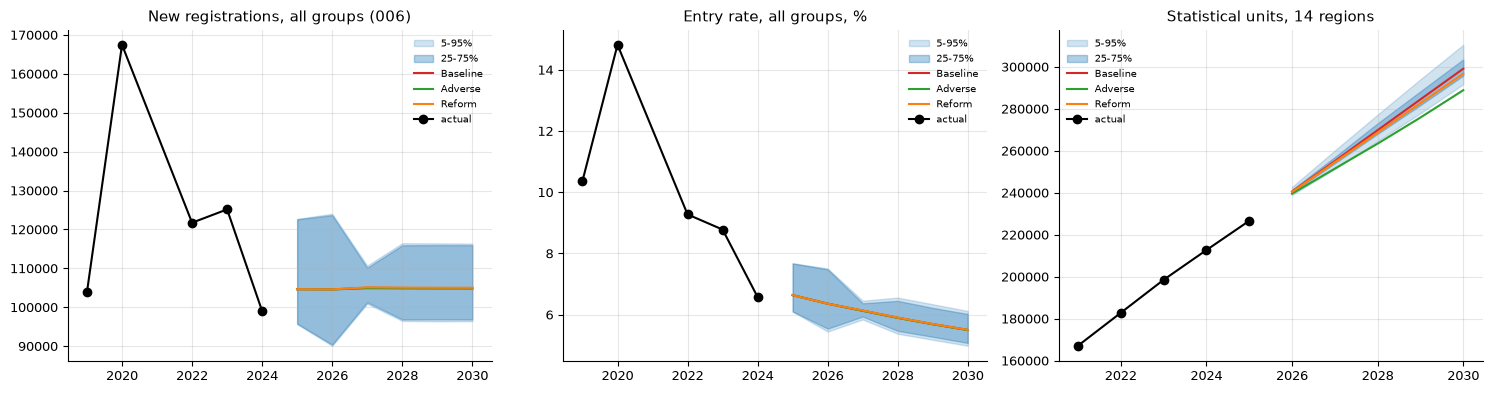

In [20]:
PL, LASTB = [], []
for pn, df in PANELS.items():
    h = df.sort_values(['unit', 'year']).copy()
    h['growth'] = h.groupby('unit').N.transform(lambda s: s.pct_change()) * 100 / h.groupby('unit').year.diff()
    f = FC[(FC.scenario == 'Baseline') & (FC.panel == pn)].sort_values(['unit', 'year']).copy()
    f['growth'] = f.groupby('unit').N.pct_change() * 100
    for u, g in h.groupby('unit'):
        fu = f[(f.unit == u) & f.year.isin(FC_YEARS)]
        for var, hv, fv in [('entry rate, %', 'entry', 'entry'), ('births', 'B', 'new'), ('exit rate, %', 'exit', 'exit'), ('stock growth, % a year', 'growth', 'growth')]:
            s = g[hv].dropna()
            if s.empty: continue
            fm = float(fu[fv].mean()); lo, hi, rec = s.min(), s.max(), s.tail(2).mean()
            flag = 'outside historical range' if (fm < lo - 1e-9 or fm > hi + 1e-9) else ('differs from recent mean by >25%' if abs(fm - rec) > 0.25 * abs(rec) else '')
            PL.append(dict(panel=pn, unit=u, variable=var, forecast_mean_2026_30=fm, hist_min=lo, hist_max=hi, recent_2obs_mean=rec, flag=flag))
    last = ORIG[pn]
    for u in list(df.unit.unique()) + ['ALL']:
        if u == 'ALL':
            a = df[df.year == last]; act = a.B.sum() / a.N.sum() * 100; bl = a.B.sum(); nl = a.N.sum()
        else:
            a = df[(df.year == last) & (df.unit == u)].iloc[0]; act, bl, nl = a.entry, a.B, a.N
        b = FAN[(FAN.panel == pn) & (FAN.unit == u) & (FAN.year == 2026)].iloc[0]
        inside = b.entry_p5 <= act <= b.entry_p95
        why = '' if inside else (f"births 2026 {b.new_baseline / bl - 1:+.1%} vs {last} and stock {b.N_baseline / nl - 1:+.1%}: "
                                 + ('the stock grows faster than births, so the rate falls' if b.new_baseline / bl < b.N_baseline / nl else 'births grow faster than the stock'))
        if not inside and np.isfinite(act) and u != 'ALL' and pn == 'activity' and act > b.entry_p95:
            why += f'; {last} births were {bl / df[(df.unit == u) & (df.year < last)].B.tail(2).mean() - 1:+.0%} vs the two earlier observations'
        LASTB.append(dict(panel=pn, unit=u, last_year=last, last_actual_entry=act, band2026_p5=b.entry_p5, band2026_p95=b.entry_p95, inside=bool(inside), explanation=why))
PLAUS = pd.DataFrame(PL); LASTB = pd.DataFrame(LASTB)
PLAUS.to_csv(OUT / 'FR12_plausibility.csv', index=False); LASTB.to_csv(OUT / 'FR12_last_actual_vs_2026_band.csv', index=False)
_b = FAN[FAN.unit == 'ALL']
display(_b[_b.year.isin([2025, 2026, 2028, 2030])][['panel', 'year', 'new_baseline', 'new_p5', 'new_p95', 'entry_baseline', 'entry_p5', 'entry_p95',
                                                    'exit_baseline', 'exit_p5', 'exit_p95', 'N_baseline', 'N_p5', 'N_p95']].round(2))
print(f"plausibility: {int((PLAUS.flag != '').sum())} of {len(PLAUS)} unit-variable forecasts flagged; last actual entry rate outside the 2026 band: "
      f"{int((~LASTB.inside).sum())} of {len(LASTB)}")
display(PLAUS[PLAUS.flag != ''].round(2)); display(LASTB[~LASTB.inside].round(2))
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (pn, var, ttl) in enumerate([('activity', 'new', 'New registrations, all groups (006)'), ('activity', 'entry', 'Entry rate, all groups, %'), ('region', 'N', 'Statistical units, 14 regions')]):
    f = _b[_b.panel == pn].sort_values('year')
    ax[i].fill_between(f.year, f[f'{var}_p5'], f[f'{var}_p95'], alpha=0.2, color=PAL[0], label='5-95%')
    ax[i].fill_between(f.year, f[f'{var}_p25'], f[f'{var}_p75'], alpha=0.35, color=PAL[0], label='25-75%')
    for j, sc in enumerate(SCEN):
        a = AGG[(AGG.panel == pn) & (AGG.scenario == sc)].sort_values('year'); ax[i].plot(a.year, a[var], color=PAL[j + 1], label=sc)
    hh = PANELS[pn].groupby('year')[['B', 'N']].sum(); hv = {'new': hh.B, 'entry': hh.B / hh.N * 100, 'N': hh.N}[var]
    ax[i].plot(hv.index, hv.values, 'k-o', label='actual'); ax[i].set_title(ttl); ax[i].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Part 14 — Concentration paths: SME share system and projected bounds

With aggregate data the concentration path is identified only through the **size structure**: the SME share of each
group's output (log-odds, so shares stay in (0,1)) driven by FR1's sector paths with group fixed effects, selected
and validated with the same procedure as Part 12 (selection 2022 → 2023, hold-out target 2024). Projected bounds
combine the projected large-firm share with SME class counts that grow with the projected stock (Part 13) and a
large-unit count held at its July 2026 level; the cap regime of each group is the one used in Part 8, in every year.
**Identification limit**: the bounds move only through the large-firm share and the number of firms; concentration
*within* the large class cannot be projected without firm data (Layer B).

In [21]:
PS = SME.reset_index()[['group', 'year', 'sme_output_share']].rename(columns={'group': 'unit'})
PS = PS[PS.unit.isin(GRP)].merge(PA[['unit', 'year', 'dem', 'size', 'lend', 'cred']], on=['unit', 'year'], how='left')
PS['lo'] = np.log(PS.sme_output_share / (100 - PS.sme_output_share))
MODELS[('sme', 'lo')] = dict(df=PS, fixed=[], specs=[[], ['dem'], ['size'], ['lend'], ['dem', 'lend']], sel=(2022, [2023]),
                             hold=[(2022, [2024]), (2023, [2024])], scale='log-odds SME output share')
select_rule(('sme', 'lo'))
_h = []
for origin, tgs in MODELS[('sme', 'lo')]['hold']:
    tr = PS[PS.year <= origin]; rows = PS[PS.year.isin(tgs)]
    pm = apply_rule(('sme', 'lo'), SELECT[('sme', 'lo')]['rule'], origin, rows, COHLOG)['pred']; pn_ = apply_rule(('sme', 'lo'), NULLR, origin, rows)['pred']
    last = tr.sort_values('year').groupby('unit').lo.last(); cm = tr.groupby('unit').lo.mean()
    for u_, y_, a1, m1, n1 in zip(rows.unit, rows.year, rows.lo, pm, pn_):
        _h.append(dict(panel='sme', metric='log-odds SME output share', origin=origin, unit=u_, target=y_, actual=a1, rule=m1, null=n1, rw=last[u_], constant=cm[u_]))
_h = pd.DataFrame(_h); HOLDTAB = pd.concat([HOLDTAB, _h], ignore_index=True)
e = {k: _h[k] - _h.actual for k in ['rule', 'null', 'rw', 'constant']}
lu = pd.DataFrame({k: v ** 2 for k, v in e.items()}).assign(u=_h.unit.values).groupby('u').mean()
HOLDV = pd.concat([HOLDV, pd.DataFrame([dict(panel='sme', metric='log-odds SME output share', rule=rname(SELECT[('sme', 'lo')]['rule']),
    implied_rw_weight=SELECT[('sme', 'lo')]['w_rw'], n=len(_h), targets='2024', rmse_rule=float(np.sqrt((e['rule'] ** 2).mean())),
    rmse_null=float(np.sqrt((e['null'] ** 2).mean())), rmse_rw=float(np.sqrt((e['rw'] ** 2).mean())), rmse_constant=float(np.sqrt((e['constant'] ** 2).mean())),
    theil_rule_vs_rw=theil(e['rule'], e['rw']), theil_rule_vs_constant=theil(e['rule'], e['constant']), theil_null_vs_rw=theil(e['null'], e['rw']),
    theil_constant_vs_rw=theil(e['constant'], e['rw']), dm_p_rule_vs_rw=dm_hln(lu.rule.values, lu.rw.values)[1],
    dm_p_rule_vs_constant=dm_hln(lu.rule.values, lu.constant.values)[1])])], ignore_index=True)
_cls = E012.drop('TOT', level=0, errors='ignore').xs(2024, level=1)
CP = []
for sc in SCEN:
    X = drivers_activity(sc)
    FS = apply_rule(('sme', 'lo'), SELECT[('sme', 'lo')]['rule'], 2024, X)
    X['sme'] = 100 / (1 + np.exp(-FS['pred']))
    Nf = FC[(FC.scenario == sc) & (FC.panel == 'activity')].set_index(['unit', 'year']).N
    for _, r in X.iterrows():
        g, y = r.unit, int(r.year)
        s24 = float(PA[(PA.unit == g) & (PA.year == 2024)]['size'].iloc[0])
        mkt = float(GO_G.loc[y, g]) if y in GO_G.index else float(GO_G.loc[LAST_ACT, g]) * np.exp(r['size'] - float(np.log(VAH.loc[LAST_ACT, g])))
        grow = Nf.get((g, y), np.nan) / float(PA[(PA.unit == g) & (PA.year == 2024)].N.iloc[0])
        n = {c: float(E005.loc[(g, 2024), c]) * grow for c in CAP}; nL = float(SIZE_G.loc[g, 'large'])
        S = {c: r.sme / 100 * _cls.loc[g, c] / _cls.loc[g, 'sme'] for c in CAP}; SL = 1 - r.sme / 100
        b = hhi_bounds(n, S, nL, SL, mkt, CAPPED[g])
        CP.append(dict(scenario=sc, group=g, year=y, sme_output_share=r.sme, large_share=SL * 100, hhi_lower=b['hhi_lower'] * 1e4,
                       hhi_upper=b['hhi_upper'] * 1e4, hhi_upper_floor30=b['hhi_upper_floor30'] * 1e4, cr4_upper=b['cr4_upper'] * 100))
CONCP = pd.DataFrame(CP)
_j = CONCP[CONCP.scenario == 'Baseline'].sort_values(['group', 'year']).groupby('group').hhi_upper.apply(lambda s: (s.pct_change().abs()).max())
chk('projected upper bounds evolve continuously (max year-on-year change < 25%)', float(_j.max()), bool(_j.max() < 0.25))
CONCP.to_csv(OUT / 'FR12_concentration_paths.csv', index=False)
BND.to_csv(OUT / 'FR12_concentration_bounds.csv', index=False)
display(HOLDV[HOLDV.panel == 'sme'].round(3))
display(CONCP[(CONCP.scenario == 'Baseline') & CONCP.year.isin([2026, 2030])].pivot_table(index='group', columns='year', values=['large_share', 'hhi_lower', 'hhi_upper']).round(1))

,panel,metric,rule,implied_rw_weight,n,targets,rmse_rule,rmse_null,rmse_rw,rmse_constant,theil_rule_vs_rw,theil_rule_vs_constant,theil_null_vs_rw,theil_constant_vs_rw,dm_p_rule_vs_rw,dm_p_rule_vs_constant
6,sme,log-odds SME output share,combination: FE + size,0.000,22,2024,0.347,0.346,0.296,0.346,1.174,1.004,1.169,1.169,0.500,0.925


hhi_lower         hhi_upper           large_share       
year       2026    2030      2026      2030        2026   2030
group                                                         
ACC      24.400  23.900   528.100   523.500      22.700 22.700
AGR      50.700  49.400 3,156.000 3,156.000      36.300 36.300
CON      38.400  38.200 3,965.900 3,965.000      62.900 62.900
EDU       6.800   6.300 5,967.000 5,967.000       9.200  9.200
HEA      33.400  32.500 2,963.700 2,963.700      37.600 37.600
ICT     131.000 130.600 4,380.500 4,376.500      66.100 66.100
IND      35.000  35.000 8,277.600 8,277.600      91.000 91.000
OTH      20.900  20.700 2,578.000 2,577.500      50.700 50.700
REA     112.700 112.100 1,436.100 1,437.800      37.700 37.700
TRA     118.700 118.700 6,757.400 6,757.200      82.200 82.200
TRD       4.700   4.600   907.500   907.200      30.100 30.100

## Part 15 — Scenario analysis with industrial-organisation theory

A calibrated, transparent **Cournot toolkit**. A market is summarised by its HHI (symmetric-equivalent number of
firms $N = 1/HHI$), the demand elasticity ε at the calibration point and a conduct parameter θ (1 = Cournot, < 1 more
competitive). Industry Lerner index $L=\theta\,HHI/\varepsilon$; with price and output normalised to 1, marginal
cost $c = 1-L$; linear demand $P = a - bQ$ with $b = 1/\varepsilon$, $a = 1 + b$.

| Scenario | Mechanism |
|---|---|
| (a) entry / licensing simplification | $N \to N+\Delta N$; symmetric equilibrium $Q = N(a-c)/(b(N+\theta))$ |
| (b) merger | $\Delta HHI = 2s_1s_2$, with the HHI used never below $s_1^2+s_2^2$; screens: US 2010 (1500/2500; ΔHHI 100/200) and EU (HHI 1000–2000 with ΔHHI ≥ 250, > 2000 with ΔHHI ≥ 150); Farrell–Shapiro: price falls only if the merged firm's marginal cost falls by at least the pre-merger markup |
| (c) cost shock / unit tax *t* | pass-through $dP/dc = N/(N+\theta)$ (linear demand); $N\varepsilon/(N\varepsilon-\theta)$ (constant elasticity) |
| (d) import competition | competitive import fringe with share *m* and supply elasticity η: $L=\theta\,HHI_d(1-m)/(\varepsilon+\eta m)$ |
| (e) state-owned enterprise | **mixed oligopoly** (De Fraja and Delbono 1989; partial privatisation as in Matsumura 1998), below |

**Mixed oligopoly.** One state-owned firm (output share σ) with increasing marginal cost $c + k q_0$ maximises
$\lambda\,\pi_0 + (1-\lambda)\,W$ (λ = 0: welfare-maximising SOE; λ = 1: fully privatised); *n* symmetric private
firms with marginal cost *c* play Cournot with conduct θ. First-order conditions: SOE $P = c + k q_0 + \lambda\theta b q_0$,
private $P = c + \theta b q_i$. Calibration at the status quo (λ = 0, P = 1, Q = 1): $c = 1-\theta b(1-\sigma)/n$,
$k = \theta b (1-\sigma)/(n\sigma)$ (assumption: the SOE's marginal cost starts at the private firms' level and rises
with output), and $n = (1-\sigma)^2/(HHI-\sigma^2)$, so the HHI used is never below σ² (and n ≥ 1). The scenario
raises λ to 0.5 or 1 and the equilibrium is **solved numerically** (`scipy.optimize.fsolve`).

Welfare (linear demand, exact): $\Delta CS=\tfrac12(Q_0+Q_1)(P_0-P_1)$, $\Delta PS$ = change in profits; in % of initial
market revenue and, where the market's revenue is known (Layer-A groups), in mn AZN. The examples are
**illustrative** (assumptions explicit); the same functions run on firm-level HHI once Layer B has real data.

In [22]:
from scipy.optimize import fsolve
def lin_eq(N, eps, theta, c, a_b):
    a, b = a_b; Q = N * (a - c) / (b * (N + theta)); return a - b * Q, Q
def calibrate(hhi, eps, theta):
    L = min(theta * hhi / eps, 0.95); b = 1 / eps
    return dict(L=L, c=1 - L, a=1 + b, b=b, N=theta / (L * eps) if L > 0 else np.inf)
def outcome(P0, Q0, c0, P1, Q1, c1, rev_mn, dps=None):
    dcs = 0.5 * (Q0 + Q1) * (P0 - P1); dps = (P1 - c1) * Q1 - (P0 - c0) * Q0 if dps is None else dps
    return dict(d_price_pct=(P1 / P0 - 1) * 100, d_markup_pp=((P1 - c1) / P1 - (P0 - c0) / P0) * 100, d_output_pct=(Q1 / Q0 - 1) * 100,
                d_cs_pct_rev=dcs / (P0 * Q0) * 100, d_ps_pct_rev=dps / (P0 * Q0) * 100,
                d_cs_mn=dcs / (P0 * Q0) * rev_mn if rev_mn == rev_mn else np.nan, d_ps_mn=dps / (P0 * Q0) * rev_mn if rev_mn == rev_mn else np.nan)
def sc_entry(hhi, eps, theta, dN, rev):
    k = calibrate(hhi, eps, theta); P0, Q0 = lin_eq(k['N'], eps, theta, k['c'], (k['a'], k['b'])); P1, Q1 = lin_eq(k['N'] + dN, eps, theta, k['c'], (k['a'], k['b']))
    return outcome(P0, Q0, k['c'], P1, Q1, k['c'], rev)
def sc_merger(hhi, eps, theta, s1, s2, rev):
    hhi = max(hhi, s1 ** 2 + s2 ** 2); dH = 2 * s1 * s2; h1 = hhi + dH
    us = 'presumed to enhance market power' if h1 > .25 and dH > .02 else ('potentially raises significant concerns' if h1 > .15 and dH > .01 else 'unlikely to have adverse effects')
    eu = 'concern' if ((h1 > .2 and dH >= .015) or (.1 <= h1 <= .2 and dH >= .025)) else 'no presumption'
    k = calibrate(hhi, eps, theta); P0, Q0 = lin_eq(k['N'], eps, theta, k['c'], (k['a'], k['b']))
    P1, Q1 = lin_eq(max(theta / (min(theta * h1 / eps, 0.95) * eps), 1.0), eps, theta, k['c'], (k['a'], k['b']))
    return outcome(P0, Q0, k['c'], P1, Q1, k['c'], rev) | dict(hhi_used=hhi * 1e4, hhi_post=h1 * 1e4, d_hhi=dH * 1e4, us_2010_screen=us, eu_screen=eu, fs_required_mc_cut_pct=(P0 - k['c']) / k['c'] * 100)
def sc_cost(hhi, eps, theta, t, rev):
    k = calibrate(hhi, eps, theta); P0, Q0 = lin_eq(k['N'], eps, theta, k['c'], (k['a'], k['b'])); P1, Q1 = lin_eq(k['N'], eps, theta, k['c'] + t, (k['a'], k['b']))
    ne = k['N'] * eps
    return outcome(P0, Q0, k['c'], P1, Q1, k['c'] + t, rev) | dict(passthrough_linear=(P1 - P0) / t, passthrough_const_elast=ne / (ne - theta) if ne > theta else np.nan)
def sc_import(hhi_d, eps, theta, m0, m1, eta, rev):
    L0 = min(theta * hhi_d * (1 - m0) / (eps + eta * m0), .95); L1 = min(theta * hhi_d * (1 - m1) / (eps + eta * m1), .95)
    b = 1 / eps; a = 1 + b; c = 1 - L0; P1 = c / (1 - L1); Q1 = max(a - P1, 0) / b
    return outcome(1.0, 1.0, c, P1, Q1, c, rev)
def mixed_oligopoly(hhi, sigma, eps, theta, lam, rev, n_max=1000):
    b = 1 / eps; a = 1 + b
    hhi = min(max(hhi, sigma ** 2 + (1 - sigma) ** 2 / n_max), sigma ** 2 + (1 - sigma) ** 2)     # n between 1 and n_max
    n = (1 - sigma) ** 2 / (hhi - sigma ** 2); c = 1 - theta * b * (1 - sigma) / n; k = theta * b * (1 - sigma) / (n * sigma)
    def foc(x, lm):
        q0, q = x; P = a - b * (q0 + n * q)
        return [P - c - k * q0 - lm * theta * b * q0, P - c - theta * b * q]
    x0 = fsolve(foc, [sigma, (1 - sigma) / n], args=(0.0,), xtol=1e-12); x1 = fsolve(foc, x0, args=(lam,), xtol=1e-12)
    pr = lambda q0, q: (a - b * (q0 + n * q)) * (q0 + n * q) - c * (q0 + n * q) - k * q0 ** 2 / 2
    P0, Q0 = a - b * (x0[0] + n * x0[1]), x0[0] + n * x0[1]; P1, Q1 = a - b * (x1[0] + n * x1[1]), x1[0] + n * x1[1]
    mc_avg = lambda q0, q: (c * n * q + (c + k * q0) * q0) / (q0 + n * q)
    o = outcome(P0, Q0, mc_avg(*x0), P1, Q1, mc_avg(*x1), rev, dps=pr(*x1) - pr(*x0))
    return o | dict(hhi_used=hhi * 1e4, n_private=n, soe_share_after=x1[0] / Q1 * 100, d_welfare_pct_rev=o['d_cs_pct_rev'] + o['d_ps_pct_rev'],
                    calib_resid=float(abs(P0 - 1) + abs(Q0 - 1) + abs(x0[0] - sigma)))
_k = calibrate(0.25, 1.0, 1.0); _P, _Q = lin_eq(_k['N'], 1.0, 1.0, _k['c'], (_k['a'], _k['b']))
chk('Cournot calibration reproduces P = 1, Q = 1 at the calibration point', float(abs(_P - 1) + abs(_Q - 1)), abs(_P - 1) + abs(_Q - 1) < 1e-9)
for th_ in (1.0, 0.5):
    _kk = calibrate(0.25, 1.0, th_); _e = sc_cost(0.25, 1.0, th_, 0.01, 1.0)
    chk(f'linear Cournot pass-through equals N/(N+θ), θ = {th_}', float(abs(_e['passthrough_linear'] - _kk['N'] / (_kk['N'] + th_))), abs(_e['passthrough_linear'] - _kk['N'] / (_kk['N'] + th_)) < 1e-9)
_m = mixed_oligopoly(0.2, 0.3, 1.0, 1.0, 0.0, 1.0)
chk('mixed oligopoly: calibration reproduces P = 1, Q = 1, SOE share σ; λ = 0 leaves the equilibrium unchanged', _m['calib_resid'] + abs(_m['d_price_pct']), _m['calib_resid'] + abs(_m['d_price_pct']) < 1e-8)
print('IO toolkit: calibrate, sc_entry, sc_merger, sc_cost, sc_import, mixed_oligopoly (De Fraja-Delbono, numerical equilibrium)')

IO toolkit: calibrate, sc_entry, sc_merger, sc_cost, sc_import, mixed_oligopoly (De Fraja-Delbono, numerical equilibrium)


### 15.1 Scenarios: activity-group calibrations and flagship markets, reported as ranges

Every scenario is run over the **whole concentration range** — HHI from the lower to the upper bound (Part 8 for
activity groups; stated public structure for the flagship markets), five points on a log grid — × demand elasticity
{0.5, 1, 1.5, 2} × conduct {Cournot θ = 1, θ = 0.5}. No "central" value is singled out; the endpoints at ε = 1, θ = 1
are shown. **Flagship markets are illustrative calibrations from approximate public structure, stated as assumptions
and to be replaced by regulator data** (Ministry of Digital Development and Transport / ICTA for mobile, CBAR for banking,
producers' reports for cement); their revenue is not in FR12's data, so welfare is in % of market revenue only.
State share for the mixed-oligopoly scenario: industry 21.9% of output (2025; DSK industry `010_2`, via
`FR10_ownership.csv`), manufacturing 35.1% as sensitivity; all state industrial producers are treated as one SOE
(assumption).

In [23]:
_own = pd.read_csv(OUT / 'FR10_ownership.csv', index_col=0)
SIG = {'industry': 1 - float(_own.loc[LAST_ACT, 'published non-state share, %']) / 100,
       'manufacturing': 1 - float(_own.loc[LAST_ACT, 'non-state share of manufacturing, %']) / 100}
_b24 = BND[BND.year == 2024].set_index('group')
MK = {g: dict(name=f'{g} ({GROUPS[g][0]})', lo=_b24.loc[g, 'hhi_lower'] / 1e4, up=_b24.loc[g, 'hhi_upper'] / 1e4, rev=float(GO_G.loc[LAST_ACT, g]),
              source='Layer-A size-class bounds (Part 8), 2024') for g in GRP}
MK['MOB'] = dict(name='Mobile telecommunications (3 operators)', lo=0.33, up=0.40, rev=np.nan,
                 source='ASSUMPTION: 3 operators, subscriber shares ≈ 50-55 / 25-30 / 20% (approximate public reports) -> HHI 3,300-4,000')
MK['BNK'] = dict(name='Banking (assets)', lo=0.08, up=0.13, rev=np.nan,
                 source='ASSUMPTION: ~22 banks, top-5 ≈ 60% of assets (approximate, CBAR annual reports) -> HHI 800-1,300; replace with CBAR concentration data')
MK['CEM'] = dict(name='Cement (domestic producers)', lo=0.35, up=0.55, rev=np.nan,
                 source='ASSUMPTION: 2-3 domestic integrated producers plus imports (approximate) -> domestic HHI 3,500-5,500')
EPS_GRID, THETA_GRID = [0.5, 1.0, 1.5, 2.0], [1.0, 0.5]
SCN = [
 ('S1', 'ICT', 'Entry-barrier reduction / licensing simplification', 'one additional symmetric-equivalent competitor (ΔN = +1)', lambda h, e, t, r: sc_entry(h, e, t, 1.0, r)),
 ('S1', 'MOB', 'Entry of a 4th mobile operator', 'ΔN = +1 symmetric-equivalent competitor', lambda h, e, t, r: sc_entry(h, e, t, 1.0, r)),
 ('S2', 'CON', 'Merger of two firms', 'merging shares 10% and 5%; HHI used >= 0.10² + 0.05²', lambda h, e, t, r: sc_merger(h, e, t, 0.10, 0.05, r)),
 ('S2', 'BNK', 'Merger of two banks', 'merging asset shares 8% and 6%; HHI used >= 0.08² + 0.06²', lambda h, e, t, r: sc_merger(h, e, t, 0.08, 0.06, r)),
 ('S3', 'ACC', 'Cost shock / excise or tax increase', 'per-unit cost +5% of the initial price, all firms', lambda h, e, t, r: sc_cost(h, e, t, 0.05, r)),
 ('S3', 'CEM', 'Energy-cost shock', 'per-unit cost +5% of the initial price, all producers', lambda h, e, t, r: sc_cost(h, e, t, 0.05, r)),
 ('S4', 'IND', 'Import competition (tariff cut)', 'import share 30% -> 40%, import supply elasticity η = 2', lambda h, e, t, r: sc_import(h, e, t, 0.3, 0.4, 2.0, r)),
 ('S4', 'CEM', 'Import competition (tariff cut)', 'import share 20% -> 30%, η = 2', lambda h, e, t, r: sc_import(h, e, t, 0.2, 0.3, 2.0, r))]
for nm_, sg in SIG.items():
    for lam in (0.5, 1.0):
        SCN.append(('S5', 'IND', f'SOE {"partial" if lam < 1 else "full"} privatisation (mixed oligopoly)', f'σ = {sg:.1%} ({nm_}), λ: 0 -> {lam}',
                    (lambda sg_, lm_: (lambda h, e, t, r: mixed_oligopoly(h, sg_, e, t, lm_, r)))(sg, lam)))
SC_ASSUME, SC_RES = [], []
for sid, mk, name, assumption, fn in SCN:
    M_ = MK[mk]; grid = np.exp(np.linspace(np.log(M_['lo']), np.log(M_['up']), 5))
    SC_ASSUME.append(dict(scenario=sid, market=M_['name'], change=name, assumption=assumption, hhi_range=f"{M_['lo']*1e4:,.0f}-{M_['up']*1e4:,.0f}",
                          structure_source=M_['source'], elasticity_range='0.5-2.0 (FR5 services system: 1.0)', conduct='Cournot θ = 1; θ = 0.5',
                          demand='linear', status='illustrative'))
    for h in grid:
        for e in EPS_GRID:
            for th in THETA_GRID:
                SC_RES.append(dict(scenario=sid, market=mk, change=name, assumption=assumption, hhi=h * 1e4, elasticity=e, conduct=th, **fn(h, e, th, M_['rev'])))
SC_ASSUME = pd.DataFrame(SC_ASSUME); SC_RES = pd.DataFrame(SC_RES)
SC_RES['hhi_eff'] = SC_RES.hhi_used.fillna(SC_RES.hhi)          # merger: >= s1² + s2²; mixed oligopoly: within [σ², σ² + (1-σ)²]
_k = ['scenario', 'market', 'change', 'assumption']
_end = SC_RES[(SC_RES.elasticity == 1.0) & (SC_RES.conduct == 1.0)].sort_values('hhi').groupby(_k, sort=False)
SC_SUM = SC_RES.groupby(_k, sort=False).agg(hhi_min=('hhi_eff', 'min'), hhi_max=('hhi_eff', 'max'), d_price_min=('d_price_pct', 'min'), d_price_max=('d_price_pct', 'max'),
                                            d_markup_min=('d_markup_pp', 'min'), d_markup_max=('d_markup_pp', 'max'), d_output_min=('d_output_pct', 'min'),
                                            d_output_max=('d_output_pct', 'max'), d_cs_pct_min=('d_cs_pct_rev', 'min'), d_cs_pct_max=('d_cs_pct_rev', 'max'),
                                            d_cs_mn_min=('d_cs_mn', 'min'), d_cs_mn_max=('d_cs_mn', 'max'))
SC_SUM['d_price_at_lower_bound'] = _end.d_price_pct.first(); SC_SUM['d_price_at_upper_bound'] = _end.d_price_pct.last()
SC_SUM = SC_SUM.reset_index()
SC_ASSUME.to_csv(OUT / 'FR12_scenario_assumptions.csv', index=False); SC_RES.to_csv(OUT / 'FR12_scenario_results.csv', index=False)
SC_SUM.to_csv(OUT / 'FR12_scenario_summary.csv', index=False)
display(SC_ASSUME[['scenario', 'market', 'change', 'hhi_range', 'structure_source']])
display(SC_SUM[['scenario', 'market', 'assumption', 'hhi_min', 'hhi_max', 'd_price_min', 'd_price_max', 'd_price_at_lower_bound', 'd_price_at_upper_bound', 'd_cs_pct_min', 'd_cs_pct_max']].round(2))
_mg = SC_RES[SC_RES.scenario == 'S2'].groupby('market').agg(hhi_post_min=('hhi_post', 'min'), hhi_post_max=('hhi_post', 'max'), d_hhi=('d_hhi', 'first'),
                                                           us=('us_2010_screen', lambda s: ' / '.join(sorted(set(s)))), eu=('eu_screen', lambda s: ' / '.join(sorted(set(s)))),
                                                           fs_mc_cut_min=('fs_required_mc_cut_pct', 'min'), fs_mc_cut_max=('fs_required_mc_cut_pct', 'max'))
MERGER_SCREEN = _mg.reset_index(); display(MERGER_SCREEN.round(1))
chk('scenario welfare: ΔCS has the opposite sign of Δprice in every run', 0.0, bool(((np.sign(SC_RES.d_cs_pct_rev) == -np.sign(SC_RES.d_price_pct)) | (SC_RES.d_price_pct.abs() < 1e-9)).all()))
_s5 = SC_RES[SC_RES.scenario == 'S5']
chk('mixed oligopoly: every calibration reproduces P = 1, Q = 1 and σ', float(_s5.calib_resid.max()), bool(_s5.calib_resid.max() < 1e-6))

,scenario,market,change,hhi_range,structure_source
0,S1,ICT (Information & communication),Entry-barrier reduction / licensing simplifica...,"122-4,037","Layer-A size-class bounds (Part 8), 2024"
1,S1,Mobile telecommunications (3 operators),Entry of a 4th mobile operator,"3,300-4,000","ASSUMPTION: 3 operators, subscriber shares ≈ 5..."
2,S2,CON (Construction),Merger of two firms,"39-3,973","Layer-A size-class bounds (Part 8), 2024"
3,S2,Banking (assets),Merger of two banks,"800-1,300","ASSUMPTION: ~22 banks, top-5 ≈ 60% of assets (..."
4,S3,ACC (Accommodation & food),Cost shock / excise or tax increase,22-465,"Layer-A size-class bounds (Part 8), 2024"
5,S3,Cement (domestic producers),Energy-cost shock,"3,500-5,500",ASSUMPTION: 2-3 domestic integrated producers ...
6,S4,IND (Industry),Import competition (tariff cut),"34-7,957","Layer-A size-class bounds (Part 8), 2024"
7,S4,Cement (domestic producers),Import competition (tariff cut),"3,500-5,500",ASSUMPTION: 2-3 domestic integrated producers ...
8,S5,IND (Industry),SOE partial privatisation (mixed oligopoly),"34-7,957","Layer-A size-class bounds (Part 8), 2024"
9,S5,IND (Industry),SOE full privatisation (mixed oligopoly),"34-7,957","Layer-A size-class bounds (Part 8), 2024"


,scenario,market,assumption,hhi_min,hhi_max,d_price_min,d_price_max,d_price_at_lower_bound,d_price_at_upper_bound,d_cs_pct_min,d_cs_pct_max
0,S1,ICT,one additional symmetric-equivalent competitor...,121.610,"4,037.180",-18.040,-0.000,-0.010,-9.020,0.000,18.850
1,S1,MOB,ΔN = +1 symmetric-equivalent competitor,"3,300.000","4,000.000",-17.780,-1.820,-6.560,-8.890,1.850,18.570
2,S2,CON,merging shares 10% and 5%; HHI used >= 0.10² +...,125.000,"3,972.740",0.210,1.960,0.980,0.710,-1.950,-0.210
3,S2,BNK,merging asset shares 8% and 6%; HHI used >= 0....,800.000,"1,300.000",0.220,1.760,0.880,0.840,-1.750,-0.220
4,S3,ACC,"per-unit cost +5% of the initial price, all firms",22.220,464.790,4.780,4.990,4.990,4.780,-4.930,-4.550
5,S3,CEM,"per-unit cost +5% of the initial price, all pr...","3,500.000","5,500.000",3.230,4.260,3.700,3.230,-4.210,-3.120
6,S4,IND,"import share 30% -> 40%, import supply elastic...",33.650,"7,956.990",-21.980,-0.010,-0.040,-11.280,0.010,23.190
7,S4,CEM,"import share 20% -> 30%, η = 2","3,500.000","5,500.000",-21.370,-1.180,-5.540,-9.700,1.190,22.510
8,S5,IND,"σ = 21.9% (industry), λ: 0 -> 0.5",484.400,"6,582.590",0.010,2.750,0.020,1.200,-2.730,-0.010
9,S5,IND,"σ = 21.9% (industry), λ: 0 -> 1.0",484.400,"6,582.590",0.010,4.310,0.020,2.160,-4.270,-0.010


,market,hhi_post_min,hhi_post_max,d_hhi,us,eu,fs_mc_cut_min,fs_mc_cut_max
0,BNK,896.000,"1,396.000",96.000,unlikely to have adverse effects,no presumption,2.000,35.100
1,CON,225.000,"4,072.700",100.000,potentially raises significant concerns / unli...,no presumption,0.300,386.700


## Part 16 — Early warning: where is competition deteriorating?

Each flag compares the recent average (last three observations; exit: last two) with the earlier average, scaled by
the indicator's own year-to-year volatility in that sector (z-score), and is raised at |z| > z* in the adverse
direction. Flags in the composite: **concentration** (large-firm output share up), **entry** (log new registrations
down — the flow, so a growing stock cannot produce a spurious fall), **exit** (exit rate up; 2022 wave excluded),
**share mobility** (branch-share instability down; industry only), **margins up with entry down**. Weights 0.25,
0.25, 0.15, 0.10, 0.25; score = weighted share of raised flags among those available; watch list: score ≥ 0.30 or
≥ 2 flags. Missing data give "insufficient data", never zero.

**Not in the composite** (reported as information): licences issued — rising issuance means more authorised entry,
not a barrier; the **cohort-size ratio** (active SMEs aged k / aged 1 in the same year; two years only — it mixes
cohort size with survival, so it is not a survival rate; survival comes from Layer-B Kaplan–Meier once the register
is real); the state-owned share of **active SMEs** (two years only).

**Threshold z\*** is chosen so that the **false-listing rate** — the probability that a sector with no change in
its competitive conditions reaches the watch list — is at most 10% under **both** null processes for every series
(i.i.d. noise, and a driftless random walk, which mimics persistent series), with the sector's actual series lengths;
computed by simulation (20 000 replications per sector and null).

In [24]:
_r = [(l, n) for _, l, n in sheet_rows(DDIR / 'entrepreneurship' / '005en.xls') if l]
SOE = {}
for g in GRP:
    i = next(k for k, (l, n) in enumerate(_r) if re.search(GROUPS[g][1] if g != 'TRA' else 'transportation', az_lower(l)) and len(n) >= 8)
    j = next(k for k in range(i + 1, len(_r)) if 'state owned' in az_lower(_r[k][0]) and 'non-state' not in az_lower(_r[k][0]))
    SOE[g] = {2023: _r[j][1][0] / _r[i][1][0] * 100, 2024: _r[j][1][4] / _r[i][1][4] * 100}
SOE = pd.DataFrame(SOE).T
W = {'F_conc': .25, 'F_entry': .25, 'F_exit': .15, 'F_mob': .10, 'F_margin_entry': .25}
def zchange(s, recent=3):
    s = pd.Series(s).dropna().sort_index()
    if len(s) < 4: return np.nan
    sd = s.diff().std()
    return float((s.iloc[-recent:].mean() - s.iloc[:-recent].mean()) / sd) if sd > 0 else np.nan
SER = {}
for g in GRP:
    e = PA[PA.unit == g].set_index('year'); ex = e.exit.copy(); ex.loc[2022] = np.nan
    SER[g] = dict(conc=((100 - SME.loc[g].sme_output_share), 3, +1), entry=(e.lnB, 3, -1), exit=(ex, 2, +1),
                  mob=((INSTAB.loc[2010:], 3, -1) if g == 'IND' else (pd.Series(dtype=float), 3, -1)),
                  margin=(PCM_G.PCM.xs(g, level=0).loc[2010:], 3, +1))
def flags_from_z(z, zs):
    f = {}
    for k, nm in [('conc', 'F_conc'), ('entry', 'F_entry'), ('exit', 'F_exit'), ('mob', 'F_mob')]:
        f[nm] = 'insufficient data' if not np.isfinite(z[k]) else bool(SER_DIR[k] * z[k] > zs)
    f['F_margin_entry'] = 'insufficient data' if not (np.isfinite(z['margin']) and np.isfinite(z['entry'])) else bool(z['margin'] > zs and z['entry'] < 0)
    return f
SER_DIR = {'conc': 1, 'entry': -1, 'exit': 1, 'mob': -1}
def listed(f):
    av = {k: v for k, v in f.items() if isinstance(v, bool)}
    sc = sum(W[k] for k, v in av.items() if v) / sum(W[k] for k in av) if av else np.nan
    return sc, int(sum(av.values())), bool(av) and (sc >= 0.30 or sum(av.values()) >= 2)
rng_e = np.random.default_rng(SEED + 16); NSIM = 20000
def false_listing(zs, null='iid'):
    rates = {}
    for g in GRP:
        lens = {k: (int(SER[g][k][0].dropna().size), SER[g][k][1]) for k in SER[g]}
        Z = {}
        for k, (n, rc) in lens.items():
            if n < 4: Z[k] = np.full(NSIM, np.nan); continue
            x = rng_e.standard_normal((NSIM, n)); x = np.cumsum(x, axis=1) if null == 'random walk' else x; sd = np.diff(x, axis=1).std(axis=1, ddof=1)
            Z[k] = (x[:, -rc:].mean(1) - x[:, :-rc].mean(1)) / sd
        av = {k: np.isfinite(Z[k]).all() for k in ['conc', 'entry', 'exit', 'mob']}
        F_ = {f'F_{k}': (SER_DIR[k] * Z[k] > zs) for k in av if av[k]}
        if np.isfinite(Z['margin']).all() and av['entry']: F_['F_margin_entry'] = (Z['margin'] > zs) & (Z['entry'] < 0)
        wsum = sum(W[k] for k in F_); sc = sum(W[k] * v for k, v in F_.items()) / wsum; nf = sum(v.astype(int) for v in F_.values())
        hit = int(((sc >= 0.30) | (nf >= 2)).sum())
        rates[g] = hit / NSIM
    return float(np.mean(list(rates.values()))), rates
FL = {}
for zs in [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    FL[zs] = {nl: false_listing(zs, nl) for nl in ['iid', 'random walk']}
    if max(v[0] for v in FL[zs].values()) <= 0.10: break
Z_STAR = zs
FALSE_LIST = pd.DataFrame([dict(z_threshold=k, null=nl, false_listing_rate=v[0], **{f'rate_{g}': r for g, r in v[1].items()}) for k, d in FL.items() for nl, v in d.items()])
EW = []
for g in GRP:
    z = {k: zchange(SER[g][k][0], SER[g][k][1]) for k in SER[g]}
    f = flags_from_z(z, Z_STAR); sc, nf, ls = listed(f)
    row = dict(group=g, name=GROUPS[g][0], **{f'z_{k}': v for k, v in z.items()}, **f, n_available=sum(isinstance(v, bool) for v in f.values()),
               n_flags=nf, score=sc, watch_list=ls, flags=', '.join(k[2:] for k, v in f.items() if v is True))
    lic = LIC_G[g].loc[2016:LAST_ACT] if g in LIC_G.columns else None
    row['info_licences_z'] = zchange(lic) if lic is not None else np.nan
    row['info_cohort_size_ratio_change_pct'] = ((AGE.loc[(g, 2024)][[2, 3, 4, 5]] / AGE.loc[(g, 2024)][1]).mean() / (AGE.loc[(g, 2023)][[2, 3, 4, 5]] / AGE.loc[(g, 2023)][1]).mean() - 1) * 100 if (g, 2024) in AGE.index else np.nan
    row['info_state_share_of_active_SMEs_2024'] = SOE.loc[g, 2024]
    EW.append(row)
EWS = pd.DataFrame(EW)
EWS.to_csv(OUT / 'FR12_early_warning.csv', index=False); FALSE_LIST.to_csv(OUT / 'FR12_early_warning_false_listing.csv', index=False)
display(FALSE_LIST.round(3).T)
display(EWS[['group', 'name', 'z_conc', 'z_entry', 'z_exit', 'z_margin', 'F_conc', 'F_entry', 'F_exit', 'F_mob', 'F_margin_entry', 'n_flags', 'score', 'watch_list']].round(2))
print(f"z* = {Z_STAR}: simulated false-listing rate {FL[Z_STAR]['iid'][0]:.1%} (i.i.d. null) / {FL[Z_STAR]['random walk'][0]:.1%} (random-walk null); "
      f"at z = 1: {FL[1.0]['iid'][0]:.1%} / {FL[1.0]['random walk'][0]:.1%}; watch list ({int(EWS.watch_list.sum())}): "
      + (', '.join(f"{r['name']} [{r['flags']}]" for _, r in EWS[EWS.watch_list].iterrows()) or 'none'))

,0,1,2,3,4,5
z_threshold,1.000,1.000,1.500,1.500,2.000,2.000
null,iid,random walk,iid,random walk,iid,random walk
false_listing_rate,0.030,0.253,0.006,0.143,0.002,0.077
rate_AGR,0.039,0.243,0.009,0.136,0.003,0.070
rate_IND,0.032,0.375,0.005,0.232,0.002,0.128
rate_CON,0.029,0.236,0.005,0.133,0.001,0.070
rate_TRD,0.029,0.242,0.006,0.133,0.001,0.076
rate_TRA,0.030,0.243,0.006,0.137,0.001,0.072
rate_ACC,0.026,0.238,0.006,0.134,0.002,0.074
rate_ICT,0.030,0.246,0.005,0.137,0.002,0.074


,group,name,z_conc,z_entry,z_exit,z_margin,F_conc,F_entry,F_exit,F_mob,F_margin_entry,n_flags,score,watch_list
0,AGR,Agriculture,1.130,1.040,-1.290,-6.480,False,False,False,insufficient data,False,0,0.000,False
1,IND,Industry,0.000,2.780,0.900,-1.010,False,False,False,False,False,0,0.000,False
2,CON,Construction,-0.620,-2.690,1.010,-4.540,False,True,False,insufficient data,False,1,0.280,False
3,TRD,Trade,3.840,0.570,0.580,0.200,True,False,False,insufficient data,False,1,0.280,False
4,TRA,Transport,-0.420,0.410,-2.470,-1.230,False,False,False,insufficient data,False,0,0.000,False
5,ACC,Accommodation & food,-0.640,0.740,0.810,-0.520,False,False,False,insufficient data,False,0,0.000,False
6,ICT,Information & communication,-0.920,0.870,0.290,-4.590,False,False,False,insufficient data,False,0,0.000,False
7,REA,Real estate,0.130,0.500,0.170,0.810,False,False,False,insufficient data,False,0,0.000,False
8,EDU,Education,0.230,1.460,-1.220,-1.280,False,False,False,insufficient data,False,0,0.000,False
9,HEA,Health & social,-0.490,-0.100,0.440,-3.110,False,False,False,insufficient data,False,0,0.000,False


z* = 2.0: simulated false-listing rate 0.2% (i.i.d. null) / 7.7% (random-walk null); at z = 1: 3.0% / 25.3%; watch list (0): none


## Part 17 — Layer B: the firm-level competition engine (SYNTHETIC until the DSK business register arrives)

> **SYNTHETIC — pipeline demonstration, not findings.** The DSK business register requested on 24 August 2026 has not
> been received. Part 17 runs on `data/business_register/FR12_business_register_SYNTHETIC.csv`, a seeded synthetic
> register **calibrated to the DSK aggregates** (Part 17.3). Every number in this Part describes invented
> enterprises. All outputs are `output/FR12_SYNTHETIC_*.csv` and carry the watermark in their first column. The
> Ministry replaces the file with its own register **in its own system** (17.4); the outputs then become
> `FR12_FIRM_*.csv`.

### 17.1 Input schema — the contract for the register extract

In [25]:
BR_SCHEMA = pd.DataFrame([
 ('data_status', 'str', '', False, 'synthetic marker; any other value or no column = REAL data', 'generator'),
 ('firm_id', 'str', '', True, 'unique per enterprise, pseudonymised (never the VÖEN)', 'DSK register'),
 ('year', 'int', '', True, 'reporting year', 'DSK register'),
 ('nace2', 'str', '', True, 'NACE Rev.2 division, 2 digits, sections A-S and U', 'DSK register'),
 ('region', 'str', '', True, 'one of the 14 economic regions', 'DSK register'),
 ('ownership', 'str', '', True, 'state | municipal | private | foreign | joint', 'DSK register'),
 ('size_class', 'str', '', True, 'micro | small | medium | large (statutory classes)', 'DSK register'),
 ('revenue', 'float', 'thsd AZN', True, '>= 0', 'DSK register / DVX'),
 ('employees', 'float', 'persons', True, '>= 0', 'DSK register / DSMF'),
 ('registration_date', 'date', '', True, 'state registration date (entry); <= 31 Dec of year', 'DSK register'),
 ('liquidation_date', 'date', '', False, 'liquidation date (exit); empty while active; >= registration date', 'DSK register'),
 ('status', 'str', '', True, 'active | liquidated (liquidated only in the year of liquidation)', 'DSK register'),
 ('legal_form', 'str', '', False, 'LLC | JSC | state enterprise | other', 'DSK register'),
 ('exports', 'float', 'thsd AZN', False, '>= 0, <= revenue', 'State Customs Committee'),
 ('product_codes', 'str', '', False, 'HS / PRODCOM codes, ";"-separated', 'DSK / Customs'),
 ('cost_of_sales', 'float', 'thsd AZN', False, '>= 0 (price-cost margin, Boone indicator)', 'DVX (link by firm_id to FR10 panel)'),
 ('operating_costs', 'float', 'thsd AZN', False, '>= 0', 'DVX'),
 ('weight', 'float', 'enterprises', False, 'number of identical enterprises the row stands for; 1 (or absent) in a census register', 'generator / sample design'),
], columns=['field', 'type', 'unit', 'required', 'constraint', 'source'])
BR_AZ = {'data_status': 'Məlumatın statusu', 'firm_id': 'Müəssisənin identifikatoru (psevdonim)', 'year': 'İl',
         'nace2': 'İqtisadi fəaliyyət növü (NACE Rev.2, 2 rəqəm)', 'region': 'İqtisadi rayon', 'ownership': 'Mülkiyyət növü',
         'size_class': 'Ölçü qrupu', 'revenue': 'Gəlir (satış)', 'employees': 'İşçilərin sayı', 'registration_date': 'Qeydiyyat tarixi',
         'liquidation_date': 'Ləğvetmə tarixi', 'status': 'Status', 'legal_form': 'Təşkilati-hüquqi forma', 'exports': 'İxrac',
         'product_codes': 'Məhsul kodları', 'cost_of_sales': 'Satışın maya dəyəri', 'operating_costs': 'Əməliyyat xərcləri', 'weight': 'Çəki'}
BR_SCHEMA['field_az'] = BR_SCHEMA.field.map(BR_AZ)
assert BR_SCHEMA.field_az.notna().all()
DIV = {'A': ['01', '02', '03'], 'B': ['05', '06', '07', '08', '09'], 'C': [f'{d}' for d in range(10, 34)], 'D': ['35'], 'E': ['36', '37', '38', '39'],
       'F': ['41', '42', '43'], 'G': ['45', '46', '47'], 'H': ['49', '50', '51', '52', '53'], 'I': ['55', '56'], 'J': ['58', '59', '60', '61', '62', '63'],
       'K': ['64', '65', '66'], 'L': ['68'], 'M': ['69', '70', '71', '72', '73', '74', '75'], 'N': ['77', '78', '79', '80', '81', '82'], 'O': ['84'],
       'P': ['85'], 'Q': ['86', '87', '88'], 'R': ['90', '91', '92', '93'], 'S': ['94', '95', '96'], 'U': ['99']}
DIV2SEC = {d: s for s, ds in DIV.items() for d in ds}
OWN = ['state', 'municipal', 'private', 'foreign', 'joint']; SIZES = ['micro', 'small', 'medium', 'large']

def br_normalise(df):
    m = {**{az_lower(v).strip(): k for k, v in BR_AZ.items()}, **{k: k for k in BR_AZ}}
    ren = {c: m.get(az_lower(str(c)).strip(), c) for c in df.columns}
    return df.rename(columns=ren), [c for c, v in ren.items() if v not in BR_AZ]

def br_validate(df):
    '''Per-row, per-field issues (row, firm_id, year, field, rule, severity). fatal/error stop the run; warnings do not.'''
    iss = []
    def add(mask, field, rule, sev='error'):
        mask = mask.fillna(sev != 'warning')
        for i in df.index[mask.to_numpy(bool)]:
            iss.append(dict(row=int(i) + 2, firm_id=df.at[i, 'firm_id'] if 'firm_id' in df else '', year=df.at[i, 'year'] if 'year' in df else '',
                            field=field, rule=rule, severity=sev))
    miss = [f for f in BR_SCHEMA[BR_SCHEMA.required].field if f not in df.columns]
    if miss:
        return pd.DataFrame([dict(row=1, firm_id='', year='', field=f, rule='required column missing (EN or AZ header)', severity='fatal') for f in miss])
    rev = pd.to_numeric(df.revenue, errors='coerce'); emp = pd.to_numeric(df.employees, errors='coerce')
    add(~np.isfinite(rev), 'revenue', 'not numeric or missing'); add(rev < 0, 'revenue', 'negative value')
    add(~np.isfinite(emp), 'employees', 'not numeric or missing'); add(emp < 0, 'employees', 'negative value')
    add(df.duplicated(['firm_id', 'year'], keep=False), 'firm_id', 'duplicate firm-year')
    add(~df.nace2.astype(str).isin(DIV2SEC), 'nace2', 'not a NACE Rev.2 division of sections A-S, U')
    add(~df.region.isin(REGS), 'region', 'not one of the 14 economic regions')
    add(~df.ownership.isin(OWN), 'ownership', 'not state / municipal / private / foreign / joint')
    add(~df.size_class.isin(SIZES), 'size_class', 'not micro / small / medium / large')
    add(~df.status.isin(['active', 'liquidated']), 'status', 'not active / liquidated')
    rd = pd.to_datetime(df.registration_date, errors='coerce'); ld = pd.to_datetime(df.get('liquidation_date'), errors='coerce')
    yr = pd.to_numeric(df.year, errors='coerce')
    add(rd.isna(), 'registration_date', 'missing or not a date'); add(rd.dt.year > yr, 'registration_date', 'registered after the reporting year')
    add((ld < rd) & ld.notna(), 'liquidation_date', 'liquidation before registration')
    add((df.status == 'liquidated') & (ld.dt.year != yr), 'status', "'liquidated' but liquidation date not in this year")
    add((df.status == 'active') & ld.notna() & (ld.dt.year <= yr), 'status', "'active' but liquidated on or before this year", 'warning')
    if 'weight' in df: add(pd.to_numeric(df.weight, errors='coerce').fillna(1) < 1, 'weight', 'weight < 1')
    if 'exports' in df: add(pd.to_numeric(df.exports, errors='coerce') > rev * 1.01, 'exports', 'exports > revenue')
    for f in ['cost_of_sales', 'operating_costs']:
        if f in df: add(pd.to_numeric(df[f], errors='coerce') < 0, f, 'negative value')
    if 'cost_of_sales' not in df: add(pd.Series(True, index=df.index[:1]).reindex(df.index, fill_value=False), 'cost_of_sales', 'absent: price-cost margin and Boone indicator not computed', 'warning')
    return pd.DataFrame(iss, columns=['row', 'firm_id', 'year', 'field', 'rule', 'severity'])
print(f'register schema: {len(BR_SCHEMA)} fields ({int(BR_SCHEMA.required.sum())} required); EN and AZ headers; validator with 17 rules, per row and field')

register schema: 18 fields (10 required); EN and AZ headers; validator with 17 rules, per row and field


### 17.2 The calculation engine

Market = NACE division × economic region × year (and division × year nationally). A row may stand for `weight`
identical enterprises (1 in a census register); every statistic treats it as that many enterprises.

| Metric | Definition |
|---|---|
| HHI, CR4, CR8 | Σ s², sum of the 4 / 8 largest shares (enterprise level), 0–10 000 and % |
| entropy, number-equivalent | −Σ s ln s; 10 000 / HHI |
| Gini | Gini coefficient of enterprise revenues |
| share instability | ½ Σ\|s_i,t − s_i,t−1\| over enterprises present in t−1 or t (entrants and exiters count with 0) |
| rank mobility | 1 − Spearman ρ of revenue ranks of incumbents between t−1 and t |
| entry / exit / churn | entrants (registered in t) and exits (liquidated in t) / active at end of t, %; relative size = mean revenue vs incumbents |
| survival | Kaplan–Meier by registration cohort (censored at the last year) |
| young-firm share | revenue share of enterprises < 5 years old |
| price-cost margin | (revenue − cost of sales − operating costs) / revenue |
| Boone indicator | slope of ln(profit) on ln(average variable cost) across profitable firms, per section-year (cross-sectional, no profit-persistence model); needs ≥ 20 profitable firms (weighted count) |

**Selection bias of the Boone indicator.** ln(profit) exists only for firms with positive profit, so the slope is
estimated on profitable firms only; loss-makers — typically the least efficient — are excluded, which truncates the
sample on the outcome and biases the slope toward zero. It is read as a ranking across sectors and over time, not
as a structural elasticity; the price-cost margin, by contrast, includes loss-making firms. Every metric honours the
frequency weight `weight` (number of identical enterprises per row; 1 when the column is absent).

In [26]:
def mkt_stats(r, w):
    r = np.asarray(r, float); w = np.asarray(w, float)
    N = w.sum(); R = (w * r).sum()
    if N <= 0 or R <= 0: return dict(n_firms=N, revenue=R, HHI=np.nan, CR4=np.nan, CR8=np.nan, entropy=np.nan, number_equivalent=np.nan, gini=np.nan)
    s = r / R; o = np.argsort(-s); so, wo = s[o], w[o]
    def crk(k):
        take = np.minimum(wo, np.maximum(k - (np.cumsum(wo) - wo), 0)); return float((take * so).sum() * 100)
    hhi = float((w * s ** 2).sum() * 1e4)
    nz = s > 0; ent = float(-(w[nz] * s[nz] * np.log(s[nz])).sum())
    oa = np.argsort(r); ra, wa = r[oa], w[oa]; cw = np.cumsum(wa); cy = np.cumsum(wa * ra)
    gini = float(1 - 2 * np.sum(wa * (cy - wa * ra / 2)) / (cw[-1] * cy[-1])) if cy[-1] > 0 else np.nan
    return dict(n_firms=N, revenue=R, HHI=hhi, CR4=crk(4), CR8=crk(8), entropy=ent, number_equivalent=1e4 / hhi, gini=gini)

def km_curve(dur, event, w):
    '''Weighted Kaplan-Meier by year of life. dur = years from registration to liquidation (0 = liquidated in the
    registration year, counted) or to the last observed year (censored, survived that year). out[k] = share surviving
    k full years.'''
    d = pd.DataFrame({'t': np.asarray(dur, float), 'e': np.asarray(event, bool), 'w': np.asarray(w, float)}); S, out = 1.0, {0: 1.0}
    for t in range(0, int(d.t.max()) + 1):
        at_risk = d.loc[d.t >= t, 'w'].sum(); ev = d.loc[(d.t == t) & d.e, 'w'].sum()
        if at_risk > 0: S *= 1 - ev / at_risk
        out[t + 1] = S
    return out

def wspearman(x, y, w):
    '''Spearman correlation with frequency weights: weighted mid-ranks, then weighted Pearson.'''
    x, y, w = (np.asarray(v, float) for v in (x, y, w))
    def wrank(v):
        o = np.argsort(v, kind='mergesort'); r = np.empty_like(v); cw = np.cumsum(w[o]); r[o] = cw - (w[o] - 1) / 2; return r
    rx, ry = wrank(x), wrank(y); mx, my = np.average(rx, weights=w), np.average(ry, weights=w)
    c = np.average((rx - mx) * (ry - my), weights=w); v = np.sqrt(np.average((rx - mx) ** 2, weights=w) * np.average((ry - my) ** 2, weights=w))
    return float(c / v) if v > 0 else np.nan

def wcol(df):
    '''Frequency weight of each row: the `weight` column if present (missing -> 1), else 1 for every row.'''
    return pd.to_numeric(df['weight'], errors='coerce').fillna(1.0).astype(float) if 'weight' in df else pd.Series(1.0, index=df.index)

def run_layer_b(P, mode, outdir, write=True):
    P = P.copy(); pre = 'FR12_SYNTHETIC_' if mode == 'SYNTHETIC' else 'FR12_FIRM_'
    P['w'] = wcol(P)
    P['sec'] = P.nace2.map(DIV2SEC); P['reg_year'] = pd.to_datetime(P.registration_date).dt.year
    P['liq_year'] = pd.to_datetime(P.liquidation_date, errors='coerce').dt.year if 'liquidation_date' in P else np.nan
    P['revenue'] = pd.to_numeric(P.revenue, errors='coerce'); P['age'] = P.year - P.reg_year
    out = {}
    rows = []
    for (d, rg, y), g in P.groupby(['nace2', 'region', 'year']):
        rows.append(dict(nace2=d, region=rg, year=y, **mkt_stats(g.revenue, g.w)))
    out['concentration_nace_region'] = pd.DataFrame(rows)
    rows = []
    for (d, y), g in P.groupby(['nace2', 'year']):
        rows.append(dict(nace2=d, section=DIV2SEC[d], year=y, **mkt_stats(g.revenue, g.w)))
    CN = pd.DataFrame(rows)
    # share instability and rank mobility, national division markets
    P['_wr'] = P.w * P.revenue
    P['share'] = P._wr / P.groupby(['nace2', 'year'])._wr.transform('sum')
    mob = []
    yrs_ = sorted(P.year.unique())
    for d, g in P.groupby('nace2'):
        piv = g.pivot_table(index='firm_id', columns='year', values='share', aggfunc='sum').fillna(0.0)
        rv = g.pivot_table(index='firm_id', columns='year', values='revenue', aggfunc='sum'); wv = g.pivot_table(index='firm_id', columns='year', values='w', aggfunc='first')
        for y in yrs_[1:]:
            if y in piv and (y - 1) in piv:
                inc = rv[[y - 1, y]].dropna()
                rho = wspearman(inc[y - 1], inc[y], wv.loc[inc.index, y]) if len(inc) > 2 else np.nan
                mob.append(dict(nace2=d, year=y, share_instability=0.5 * (piv[y] - piv[y - 1]).abs().sum() * 100, rank_mobility=1 - rho if rho == rho else np.nan))
    CN = CN.merge(pd.DataFrame(mob), on=['nace2', 'year'], how='left')
    out['concentration_nace'] = CN
    # entry, exit, churn by section x year and by section x region x year
    P['entrant'] = P.reg_year == P.year; P['exiter'] = P.status == 'liquidated'
    inc_ = ~P.entrant & ~P.exiter; wr = P.w * P.revenue
    P['_act'] = P.w * (P.status == 'active'); P['_ne'] = P.w * P.entrant; P['_nx'] = P.w * P.exiter; P['_ni'] = P.w * inc_
    P['_re'] = wr * P.entrant; P['_rx'] = wr * P.exiter; P['_ri'] = wr * inc_; P['_ry'] = wr * (P.age < 5); P['_rt'] = wr
    def flows(keys):
        a = P.groupby(keys)[['_act', '_ne', '_nx', '_ni', '_re', '_rx', '_ri', '_ry', '_rt']].sum()
        mi = a._ri / a._ni.where(a._ni > 0)
        return pd.DataFrame({'active_end': a._act, 'entrants': a._ne, 'exits': a._nx, 'entry_rate': a._ne / a._act.where(a._act > 0) * 100,
                             'exit_rate': a._nx / a._act.where(a._act > 0) * 100, 'churn': (a._ne + a._nx) / a._act.where(a._act > 0) * 100,
                             'entrant_rel_size': a._re / a._ne.where(a._ne > 0) / mi, 'exiter_rel_size': a._rx / a._nx.where(a._nx > 0) / mi,
                             'young_firm_revenue_share': a._ry / a._rt.where(a._rt > 0) * 100}).reset_index()
    out['entry_exit_section'] = flows(['sec', 'year'])
    out['entry_exit_section_region'] = flows(['sec', 'region', 'year'])
    # Kaplan-Meier survival by registration cohort (first record of each firm)
    F = P.sort_values('year').groupby('firm_id').agg(reg_year=('reg_year', 'first'), liq_year=('liq_year', 'max'), w=('w', 'first'), sec=('sec', 'first'))
    F = F[F.reg_year >= P.year.min()]
    F['event'] = F.liq_year.notna(); F['dur'] = np.where(F.event, F.liq_year - F.reg_year, P.year.max() - F.reg_year)
    km = []
    for c, g in F.groupby('reg_year'):
        for k, s in km_curve(g.dur, g.event, g.w).items(): km.append(dict(cohort=c, age=k, survival=s, cohort_size=g.w.sum()))
    out['survival_km'] = pd.DataFrame(km)
    # margins and the Boone indicator
    if 'cost_of_sales' in P and P.cost_of_sales.notna().any():
        P['cos'] = pd.to_numeric(P.cost_of_sales, errors='coerce'); P['opx'] = pd.to_numeric(P.get('operating_costs', 0), errors='coerce').fillna(0)
        P['profit'] = P.revenue - P.cos - P.opx; P['avc'] = P.cos / P.revenue
        bo = []
        for (s_, y), g in P[P.revenue > 0].groupby(['sec', 'year']):
            pcm = (g.w * g.profit).sum() / (g.w * g.revenue).sum() * 100
            h = g[(g.profit > 0) & (g.avc > 0)]
            if h.w.sum() >= 20:                            # weighted count of profitable firms
                X = np.column_stack([np.ones(len(h)), np.log(h.avc)]); W_ = h.w.to_numpy(float); yv = np.log(h.profit.to_numpy(float))
                XtW = X.T * W_; b = np.linalg.solve(XtW @ X, XtW @ yv); u = yv - X @ b
                V = np.linalg.inv(XtW @ X) @ ((X * (W_ * u)[:, None]).T @ (X * (W_ * u)[:, None])) @ np.linalg.inv(XtW @ X)
                bo.append(dict(section=s_, year=y, pcm_pct=pcm, boone_beta=b[1], boone_se=float(np.sqrt(V[1, 1])), n_profitable=float(h.w.sum())))
            else:
                bo.append(dict(section=s_, year=y, pcm_pct=pcm, boone_beta=np.nan, boone_se=np.nan, n_profitable=float(h.w.sum())))
        out['margins_boone'] = pd.DataFrame(bo)
    # pipeline tests (identities)
    cr = out['concentration_nace_region']; cr = cr[cr.revenue > 0]
    _sh = P[P.groupby(['nace2', 'year'])._wr.transform('sum') > 0].groupby(['nace2', 'year']).share.sum()
    T = [('HHI >= 10000 / N in every market', float((1e4 / cr.n_firms - cr.HHI).clip(lower=0).max()), bool((cr.HHI >= 1e4 / cr.n_firms - 1e-6).all())),
         ('CR4 <= CR8 <= 100', float((cr.CR4 - cr.CR8).clip(lower=0).max()), bool(((cr.CR4 <= cr.CR8 + 1e-9) & (cr.CR8 <= 100 + 1e-9)).all())),
         ('entropy <= ln N', float((cr.entropy - np.log(cr.n_firms)).clip(lower=0).max()), bool((cr.entropy <= np.log(cr.n_firms) + 1e-9).all())),
         ('shares add to 1 in every national division market with revenue', float((_sh - 1).abs().max()), bool((_sh - 1).abs().max() < 1e-9)),
         ('Kaplan-Meier survival non-increasing and in [0, 1]', 0.0, bool(out['survival_km'].groupby('cohort').survival.apply(lambda s: (s.diff().dropna() <= 1e-12).all() and s.between(0, 1).all()).all()))]
    out['PIPE'] = pd.DataFrame(T, columns=['test', 'value', 'passed'])
    if write:
        for k, v in out.items():
            v = v.copy()
            if mode == 'SYNTHETIC': v.insert(0, 'WATERMARK', SYN_MARK)
            v.to_csv(Path(outdir) / f'{pre}{"pipeline_tests" if k == "PIPE" else k}.csv', index=False)
    return out
print('engine defined: mkt_stats (weighted HHI, CR4/CR8, entropy, Gini), share instability, rank mobility, entry/exit/churn, KM survival, PCM, Boone')

engine defined: mkt_stats (weighted HHI, CR4/CR8, entropy, Gini), share instability, rank mobility, entry/exit/churn, KM survival, PCM, Boone


### 17.3 The SYNTHETIC register: calibration targets

Seeded (`SEED + 17`), all NACE sections (A–S, U), 14 regions, 2019–2025. Targets, **exact where DSK publishes them**:

| Target | Source | Years exact | Otherwise |
|---|---|---|---|
| births and deaths by NACE section | register `2_1` (archived vintages) | 2021, 2024, 2025 | 2022–2023: regional totals × average section mix; 2019–2020: scaled by 006 registrations |
| births and deaths by region | workbook `Regionlar*` = register `2_3` | 2021–2025 | 2019–2020: 2021 regional mix |
| active units at end-2025 by section and by region | `2_1`, `Regionlar*` | 2025 | earlier stocks follow from births and deaths (stock-flow identity, F5) |
| revenue by section | national accounts output (013) | 2019–2025 | — |
| SME share of revenue by activity group (and its micro/small/medium split) | entrepreneurship `012` | 2019, 2020, 2022–2024 | 2021 interpolated, 2025 = 2024 |
| size-class mix | register `1_3` (1 July 2026) | approximate | — |

Section × region matrices are built by iterative proportional fitting from a documented seed (Baku's weight tilted
up in services, down in agriculture) and rounded to integers **preserving both margins exactly**.

In [27]:
rng_s = np.random.default_rng(SEED + 17)
SY = list(range(2019, LAST_ACT + 1))
def lr_round(x, total):
    x = np.asarray(x, float); f = np.floor(x); k = int(round(total - f.sum()))
    f[np.argsort(-(x - f))[:k]] += 1; return f.astype(int)
def ipf_int(seed, rows, cols, it=500):
    M = seed.astype(float).copy()
    for _ in range(it):
        M *= (rows / np.maximum(M.sum(1), 1e-12))[:, None]; M *= (cols / np.maximum(M.sum(0), 1e-12))[None, :]
    F = np.floor(M).astype(int); rr = rows - F.sum(1); cc = cols - F.sum(0); fr = M - F
    for idx in np.argsort(-fr, axis=None):
        i, j = divmod(int(idx), M.shape[1])
        if rr[i] > 0 and cc[j] > 0: F[i, j] += 1; rr[i] -= 1; cc[j] -= 1
    while rr.sum() > 0:
        i = int(np.argmax(rr > 0)); j = int(np.argmax(cc > 0)); F[i, j] += 1; rr[i] -= 1; cc[j] -= 1
    assert (F.sum(1) == rows).all() and (F.sum(0) == cols).all(); return F
TILT = dict(A=.15, B=.8, C=.8, D=.8, E=.8, F=.9, G=1., H=1., I=.9, J=1.4, K=1.4, L=1.3, M=1.3, N=1.2, O=.5, P=.8, Q=.8, R=.9, S=1.1, U=2.)
_rs = RG[RG.year == LAST_ACT].set_index('region').enterprises.reindex(REGS).to_numpy(float)
SEEDM = np.array([[_rs[j] * (TILT[s] if REGS[j] == 'Baku city' else 1.0) for j in range(len(REGS))] for s in SECS])
rg = RG.set_index(['region', 'year'])
def sec_vec(var, y):
    if y in (2021, 2024, 2025): return REG_FY[var][y].reindex(SECS).to_numpy(float), 'exact'
    mix = (REG_FY[var][2021] + REG_FY[var][2024]).reindex(SECS).to_numpy(float); mix = mix / mix.sum()
    if y in (2022, 2023): tot = sum(rg.loc[(r, y), 'new' if var == 'new' else 'liquidated'] for r in REGS)
    else:
        e = E006.xs('TOT', level=0)
        tot = sum(rg.loc[(r, 2022), 'new'] for r in REGS) * e.loc[y, 'new'] / e.loc[2022, 'new'] if var == 'new' else \
              sum(rg.loc[(r, 2021), 'liquidated'] for r in REGS)
    return mix * tot, 'approximate'
def reg_vec(var, y):
    col = 'new' if var == 'new' else 'liquidated'
    if y >= 2021: return np.array([rg.loc[(r, y), col] for r in REGS], float), 'exact'
    v = np.array([rg.loc[(r, 2021), col] for r in REGS], float); return v, 'approximate'
TGT = {}
for y in SY:
    for var in ['new', 'liq']:
        sv, sq = sec_vec(var, y); rv, rq = reg_vec(var, y)
        tot = int(round(rv.sum())) if rq == 'exact' else int(round(sv.sum()))
        sv = lr_round(sv / sv.sum() * tot, tot) if sq != 'exact' else sv.astype(int)
        rv = lr_round(rv / rv.sum() * tot, tot) if rq != 'exact' else rv.astype(int)
        assert sv.sum() == rv.sum(), (y, var, sv.sum(), rv.sum())
        TGT[(var, y)] = dict(M=ipf_int(SEEDM, sv, rv), sec_q=sq, reg_q=rq)
S25 = ipf_int(SEEDM, REG_FY['stock'][LAST_ACT].reindex(SECS).to_numpy(int), np.array([rg.loc[(r, LAST_ACT), 'enterprises'] for r in REGS], int))
N18 = S25 - sum(TGT[('new', y)]['M'] - TGT[('liq', y)]['M'] for y in SY)
_neg = int((N18 < 0).sum())
if _neg:            # a cell whose later births exceed its end-2025 stock: births reassigned within the section to its largest region
    for i, j in zip(*np.where(N18 < 0)):
        need = -N18[i, j]; N18[i, j] = 0; jj = int(np.argmax(N18[i])); N18[i, jj] -= need
assert (N18 >= 0).all()
print(f'targets: births/deaths section x region for {len(SY)} years (exact: sections 2021, 2024, 2025; regions 2021-2025); '
      f'end-2025 stock {S25.sum():,}; implied start-2019 stock {N18.sum():,} ({_neg} negative cells re-balanced within their section)')

targets: births/deaths section x region for 7 years (exact: sections 2021, 2024, 2025; regions 2021-2025); end-2025 stock 226,643; implied start-2019 stock 120,231 (0 negative cells re-balanced within their section)


In [28]:
# enterprise records: start-2019 stock, births and deaths per section x region cell, exactly as targeted.
# A record may stand for several identical enterprises (column `weight`): micro units in groups of up to 40, small
# units in groups of up to 5, medium and large units one by one. This keeps the file small; a real register has weight 1.
KW = {'micro': 40, 'small': 5, 'medium': 1, 'large': 1}
HAZ = {'micro': 1.0, 'small': 0.4, 'medium': 0.2, 'large': 0.08}
_ps = SIZE[['micro', 'small', 'medium', 'large']].astype(float)
_nat = _ps.sum() / _ps.sum().sum()
P_SIZE = {s: ((_ps.loc[s] / _ps.loc[s].sum()) if (s in _ps.index and _ps.loc[s].sum() > 0) else _nat).to_numpy(float) for s in SECS}
BIRTH_TILT = np.array([1.0, 0.3, 0.1, 0.03])
def split_records(n, size):
    if n <= 0: return []
    m = int(np.ceil(n / KW[size])); base = n // m
    return [base + (1 if k < n % m else 0) for k in range(m)]
REC = []      # columns: sec, region, size, weight, reg_year, liq_year
P_INIT = {}
for i, s in enumerate(SECS):      # start-2019 size mix chosen so that the expected end-2025 mix matches 1_3
    pb = P_SIZE[s] * BIRTH_TILT; pb = pb / pb.sum()
    Bs = sum(TGT[('new', y)]['M'][i].sum() for y in SY)
    p0 = np.clip(S25[i].sum() * P_SIZE[s] - Bs * pb, 0, None)
    P_INIT[s] = p0 / p0.sum() if p0.sum() > 0 else P_SIZE[s]
for i, s in enumerate(SECS):
    pb = P_SIZE[s] * BIRTH_TILT; pb = pb / pb.sum()
    for j, r in enumerate(REGS):
        cell = []
        n0 = rng_s.multinomial(int(N18[i, j]), P_INIT[s])
        yrs0 = np.arange(1995, 2019); pw = 1.08 ** (yrs0 - 1995); pw = pw / pw.sum()
        for k, sz in enumerate(SIZES):
            for w in split_records(int(n0[k]), sz): cell.append([sz, w, int(rng_s.choice(yrs0, p=pw)), 0])
        for y in SY:
            nb = rng_s.multinomial(int(TGT[('new', y)]['M'][i, j]), pb)
            for k, sz in enumerate(SIZES):
                for w in split_records(int(nb[k]), sz): cell.append([sz, w, y, 0])
            d = int(TGT[('liq', y)]['M'][i, j])
            if d <= 0: continue
            alive = [q for q, c in enumerate(cell) if c[3] == 0 and c[2] < y]
            if sum(cell[q][1] for q in alive) < d: alive = [q for q, c in enumerate(cell) if c[3] == 0 and c[2] <= y]
            pr = np.array([HAZ[cell[q][0]] * cell[q][1] * (2.0 if y - cell[q][2] < 3 else 1.0) for q in alive])
            key = rng_s.random(len(alive)) ** (1.0 / pr)
            for q in [alive[t] for t in np.argsort(-key)]:
                if d <= 0: break
                w = cell[q][1]
                if w <= d: cell[q][3] = y; d -= w
                else: cell[q][1] = w - d; cell.append([cell[q][0], d, cell[q][2], y]); d = 0
            assert d == 0, f'cell {s}/{r} {y}: deaths exceed living units'
        REC += [[s, r] + c for c in cell]
REC = pd.DataFrame(REC, columns=['sec', 'region', 'size_class', 'weight', 'reg_year', 'liq_year'])
REC['firm_id'] = [f'SYN-{s}{k:07d}' for k, s in enumerate(REC.sec)]
print(f'{len(REC):,} synthetic enterprise records standing for {REC.weight.sum():,} enterprises '
      f'({(REC.weight > 1).sum():,} grouped micro/small records)')

15,725 synthetic enterprise records standing for 230,894 enterprises (9,472 grouped micro/small records)


In [29]:
# firm attributes, the annual panel and revenues. Data-generating process (stated, for the pipeline test only):
# ln size_it = mu_i - gamma_s * e_i + 0.25 * shock_it - 0.7 * [age < 2];  mu_i ~ Pareto(alpha_s) for large firms (low alpha =
# concentrated: mining, utilities, telecom, finance), N(0, 0.8) otherwise; e_i ~ N(0, 0.2) is the cost-efficiency deviation,
# average variable cost avc_i = v_s * exp(e_i). Revenue of each class in each section-year is scaled to its calibration
# target, so totals are exact and only the distribution across firms is random.
ALPHA = dict(A=1.8, B=1.05, C=1.4, D=1.05, E=1.3, F=1.6, G=2.5, H=1.3, I=2.8, J=1.15, K=1.2, L=1.8, M=1.8, N=1.8, O=1.5, P=2.0, Q=1.8, R=1.8, S=2.2, U=1.5)
GAMMA = {s: float(g) for s, g in zip(SECS, rng_s.choice([1.0, 2.0, 3.0], len(SECS)))}
REC['nace2'] = [rng_s.choice(DIV[s], p=([.1, .3, .6] if s == 'G' else None)) for s in REC.sec]
_o = [(l, n) for _, l, n in sheet_rows(DDIR / 'st_units' / '1_2_en.xls') if l and len(n) >= 10]
_own = {}
for s in SECS:
    try:
        n = _o[match_unique([l for l, _ in _o], f'(?:{SECT[s][1]})', s)][1]; n = [0.0 if v != v else v for v in n]
        _own[s] = np.array([n[0], n[2], max(n[4] - n[6] - n[8], 0), n[6], n[8]], float)
    except AssertionError:
        _own[s] = np.array([1, 0, 0, 0, 0], float) if s in ('O', 'U') else np.array([.05, .01, .8, .1, .04])
def own_draw(s, size):
    p = _own[s] / _own[s].sum()
    if size == 'large' and s in ('B', 'D', 'E', 'H'): p = p * np.array([4, 1, 1, 1, 1]); p = p / p.sum()
    return OWN[int(rng_s.choice(5, p=p))]
REC['ownership'] = [own_draw(s, z) for s, z in zip(REC.sec, REC.size_class)]
REC['legal_form'] = np.where(REC.ownership == 'state', 'state enterprise', np.where(REC.size_class.isin(['large', 'medium']), rng_s.choice(['JSC', 'LLC'], len(REC), p=[.3, .7]), 'LLC'))
REC['mu'] = np.where(REC.size_class == 'large', np.log(rng_s.pareto(np.array([ALPHA[s] for s in REC.sec])) + 1.0) * 1.5, rng_s.normal(0, 0.8, len(REC)))
REC['e'] = rng_s.normal(0, 0.2, len(REC))
REC['reg_date'] = pd.to_datetime(REC.reg_year.astype(str) + '-01-01') + pd.to_timedelta(rng_s.integers(0, 365, len(REC)), unit='D')
REC['liq_date'] = pd.NaT
_l = REC.liq_year > 0
_ld = pd.to_datetime(REC.loc[_l, 'liq_year'].astype(str) + '-12-31') - pd.to_timedelta(rng_s.integers(0, 365, int(_l.sum())), unit='D')
REC.loc[_l, 'liq_date'] = np.maximum(_ld.values, REC.loc[_l, 'reg_date'].values)
# annual panel: one row per record and year it is registered (status 'liquidated' in the year of liquidation)
y0 = np.maximum(REC.reg_year.to_numpy(), SY[0]); y1 = np.where(REC.liq_year > 0, REC.liq_year, SY[-1])
nrep = np.maximum(y1 - y0 + 1, 0); idx = np.repeat(REC.index.to_numpy(), nrep)
SYN = REC.loc[idx].reset_index(drop=True)
SYN['year'] = np.concatenate([np.arange(a, b + 1) for a, b in zip(y0, y1) if b >= a])
SYN['status'] = np.where(SYN.liq_year == SYN.year, 'liquidated', 'active')
SYN['age'] = SYN.year - SYN.reg_year
SYN['lnsize'] = SYN.mu - SYN.sec.map(GAMMA) * SYN.e + 0.25 * rng_s.normal(0, 1, len(SYN)) - 0.7 * (SYN.age < 2)
# revenue targets: national-accounts output by section, SME shares and class split by activity group (012)
def sme_target(g, y):
    if (g, y) in E012.index: return E012.loc[(g, y)]
    if y == 2021: return (E012.loc[(g, 2020)][['sme', 'micro', 'small', 'medium']] + E012.loc[(g, 2022)][['sme', 'micro', 'small', 'medium']]) / 2
    return E012.loc[(g, 2024)]
SYN['rev_share'] = 0.0
for (s, y, z), g in SYN.groupby(['sec', 'year', 'size_class']):
    t = sme_target(SECT[s][3], y)
    cls = (100 - t['sme']) / 100 if z == 'large' else t[z] / 100
    T_ = float(NA.loc[(s, y), 'GO']) * 1000 * cls if (s, y) in NA.index else 0.0
    x = np.exp(g.lnsize - g.lnsize.max()); SYN.loc[g.index, 'revenue'] = T_ * x / (g.weight * x).sum()
SYN['revenue'] = SYN.revenue.fillna(0.0)
_v = {s: float(np.clip(1 - NA.loc[(s, LAST_ACT), 'PCM'] / 100 - 0.05, 0.3, 0.9)) if (s, LAST_ACT) in NA.index else 0.7 for s in SECS}
SYN['cost_of_sales'] = SYN.revenue * np.clip(SYN.sec.map(_v) * np.exp(SYN.e), 0.15, 0.98)
SYN['operating_costs'] = SYN.revenue * rng_s.uniform(0.02, 0.07, len(SYN))
_emp = {'micro': (1, 10), 'small': (11, 50), 'medium': (51, 250)}
SYN['employees'] = [float(rng_s.integers(*_emp[z], endpoint=True)) if z in _emp else float(251 + rng_s.lognormal(5.0, 1.0)) for z in SYN.size_class]
# employees of large units scaled so that the SME share of employees matches 013 (nearest published year)
SYN['grp'] = SYN.sec.map(lambda s: SECT[s][3])
for (g, y), d in SYN.groupby(['grp', 'year']):
    yy = min(E013.xs(g, level=0).index, key=lambda t: abs(t - y)); sh = E013.loc[(g, yy), 'sme'] / 100
    sme = d.size_class != 'large'; E_sme = (d.weight * d.employees)[sme].sum()
    big = d[~sme]
    if len(big) and 0 < sh < 1:
        need = E_sme * (1 - sh) / sh; base = np.sqrt(big.revenue.clip(lower=1e-6)); base = base / (big.weight * base).sum()
        SYN.loc[big.index, 'employees'] = np.round(np.maximum(need * base, 251.0))
SYN['exports'] = np.where(SYN.sec.isin(['B', 'C']) & SYN.size_class.isin(['large', 'medium']), SYN.revenue * rng_s.uniform(0, 0.5, len(SYN)), 0.0)
SYN['product_codes'] = ''
SYN['registration_date'] = SYN.reg_date.dt.strftime('%Y-%m-%d'); SYN['liquidation_date'] = pd.to_datetime(SYN.liq_date).dt.strftime('%Y-%m-%d')
SYN.insert(0, 'data_status', SYN_STATUS)
BR_COLS = ['data_status'] + [f for f in BR_SCHEMA.field if f != 'data_status']
SYN = SYN[BR_COLS].copy()
for c in ['revenue', 'cost_of_sales', 'operating_costs', 'exports']: SYN[c] = SYN[c].round(3)
print(f'SYNTHETIC register: {len(SYN):,} rows, {SYN.firm_id.nunique():,} records ({SYN.groupby("year").weight.sum().iloc[-1]:,.0f} enterprises in {SY[-1]}), '
      f'{SYN.nace2.map(DIV2SEC).nunique()} sections, {SYN.nace2.nunique()} divisions, {SYN.region.nunique()} regions, {SY[0]}-{SY[-1]}')

SYNTHETIC register: 92,032 rows, 15,725 records (227,347 enterprises in 2025), 20 sections, 86 divisions, 14 regions, 2019-2025


### 17.3.1 The replaceable input files in `data/business_register/`

The generator writes **only SYNTHETIC-named files**, the template and the column map; it never creates or overwrites
`FR12_business_register.csv/.xlsx`, the name reserved for the Ministry's own register. Files are rewritten only when
their content changes. Every data row's first column reads **"SYNTHETIC — not real enterprise data"**; firm
identifiers are `SYN-…`.

In [30]:
import hashlib
SYN_CSV = BRDIR / 'FR12_business_register_SYNTHETIC.csv'; SYN_XLSX = BRDIR / 'FR12_business_register_SYNTHETIC.xlsx'
_blob = SYN.to_csv(index=False).encode('utf-8')
_changed = not SYN_CSV.exists() or hashlib.sha256(SYN_CSV.read_bytes()).hexdigest() != hashlib.sha256(_blob).hexdigest()
GEN_WRITTEN = []                                 # every file name the generator writes (checked by the swap tests)
if _changed: SYN_CSV.write_bytes(_blob)
GEN_WRITTEN.append(SYN_CSV.name)
COLMAP = BR_SCHEMA.rename(columns={'field': 'column_en', 'field_az': 'column_az'})[['column_en', 'column_az', 'type', 'unit', 'required', 'constraint', 'source']]
COLMAP.to_csv(BRDIR / 'FR12_business_register_column_map.csv', index=False); GEN_WRITTEN.append('FR12_business_register_column_map.csv')
TEMPLATE = pd.DataFrame([dict(data_status='EXAMPLE ROW — delete before use / NÜMUNƏ SƏTİR — istifadədən əvvəl silin', firm_id='F000001', year=2025, nace2='47',
                              region='Baku city', ownership='private', size_class='small', revenue=1250.0, employees=18, registration_date='2017-03-15',
                              liquidation_date='', status='active', legal_form='LLC', exports=0.0, product_codes='', cost_of_sales=900.0,
                              operating_costs=150.0, weight=1)])[BR_COLS]
TEMPLATE.to_csv(BRDIR / 'FR12_business_register_TEMPLATE.csv', index=False); GEN_WRITTEN.append('FR12_business_register_TEMPLATE.csv')
README_BR = """# FR12 business register — input file / Biznes reyestri — giriş faylı

## AZ

**SİNTETİK MƏLUMAT — real müəssisə məlumatı deyil.** `FR12_business_register_SYNTHETIC.*` fayllarında heç bir real müəssisə,
VÖEN və ya real rəqəm yoxdur. Fayl FR12 modulunun B qatını (müəssisə səviyyəsində rəqabət mühərriki) yoxlamaq üçün təsadüfi,
lakin DSK-nın aqreqat göstəriciləri ilə uzlaşdırılmış qaydada yaradılmışdır (bölmələr və regionlar üzrə yaradılan və ləğv edilən
vahidlər, 2025-ci ilin sonuna vahidlərin sayı, bölmələr üzrə buraxılış, KOS-un payı). Nəticələr yalnız texniki nümayişdir, təhlil
nəticəsi deyil. `weight` sütunu sətrin neçə eyni müəssisəni təmsil etdiyini göstərir (sintetik faylda mikro və kiçik müəssisələr
qruplaşdırılıb); real reyestrdə bu sütun olmaya və ya 1 ola bilər.

**Faylı necə əvəz etmək olar.** Nazirliyin öz reyestrini eyni sxemdə `data/business_register/FR12_business_register.csv` (və ya
`.xlsx`, `data` vərəqi) kimi saxlayın və ya `BUSREG_PATH` mühit dəyişənində faylın yolunu göstərin, sonra `FR12.ipynb`-ni yenidən
icra edin. Sütun adları ingilis və ya Azərbaycan dilində ola bilər (`FR12_business_register_column_map.csv`). `data_status` sütunu
olmadıqda və ya dəyəri sintetik qeyddən fərqli olduqda məlumat REAL sayılır. Nümunə sətri olan şablon:
`FR12_business_register_TEMPLATE.csv/.xlsx` (nümunə sətri silin).

**Yoxlama (validator).** Məcburi sütunlar, rəqəmsal və mənfi olmayan gəlir və işçi sayı, təkrarlanan müəssisə-il, NACE bölməsi,
region, mülkiyyət, ölçü qrupu, status, qeydiyyat və ləğvetmə tarixlərinin ardıcıllığı, ixrac ≤ gəlir. Hər səhv sətir və sahə üzrə
`output/FR12_business_register_validation_report.csv`-də yazılır; ciddi səhvlər icranı dayandırır, xəbərdarlıqlar dayandırmır.

**Məxfilik.** Müəssisə identifikatorları psevdonimləşdirilmiş qalmalıdır (VÖEN yox); real məlumatla nəticələr yalnız Nazirliyin
öz sistemində saxlanılır. Real adlı faylı bu layihəyə köçürməyin.

**Real reyestr yükləndikdə dəyişən nəticələr.** `FR12_SYNTHETIC_*.csv` əvəzinə `FR12_FIRM_*.csv` (su nişanı olmadan): NACE × region
üzrə HHI, CR4/CR8, entropiya, Gini, payların dəyişkənliyi, giriş/çıxış, sağ qalma, gənc müəssisələrin payı, marja və Boone
indikatoru; MIIS-də V7 görünüşü aktivləşir. A qatının nəticələri dəyişmir.

## EN

**SYNTHETIC DATA — not real enterprise data.** The `FR12_business_register_SYNTHETIC.*` files contain no real enterprise, no VÖEN
and no real figure. They were generated at random, but calibrated to DSK aggregates (units created and liquidated by NACE section
and by region, units at end-2025, output by section, SME shares), to test FR12 Layer B (the firm-level competition engine). Results
are a pipeline demonstration, not findings. Column `weight` gives the number of identical enterprises a row stands for (micro and
small units are grouped in the synthetic file); a real register may omit it or set it to 1.

**How to replace it.** Save the Ministry's register in the same schema as `data/business_register/FR12_business_register.csv`
(or `.xlsx`, sheet `data`), or set the environment variable `BUSREG_PATH` to the file, then re-run `FR12.ipynb`. Headers may be
English or Azerbaijani (`FR12_business_register_column_map.csv`). A file without a `data_status` column, or whose value differs
from the synthetic marker, is treated as REAL. Template with one example row: `FR12_business_register_TEMPLATE.csv/.xlsx`.

**What the validator checks.** Required columns, numeric non-negative revenue and employees, duplicate firm-years, NACE division,
region, ownership, size class, status, order of registration and liquidation dates, exports ≤ revenue. Every issue is written per
row and field to `output/FR12_business_register_validation_report.csv`; hard errors stop the run with a message, warnings do not.

**Confidentiality.** Keep firm identifiers pseudonymised (never the VÖEN); with real data the outputs stay inside the Ministry's
system. Do not copy a real-named file into this project.

**What changes once the real register is loaded.** `FR12_FIRM_*.csv` replace `FR12_SYNTHETIC_*.csv` (no watermark): HHI, CR4/CR8,
entropy, Gini, share instability, entry/exit, survival, young-firm share, margins and the Boone indicator by NACE × region; the
MIIS view V7 becomes active. Layer-A results do not change.
"""
(BRDIR / 'README_FR12_business_register.md').write_text(README_BR, encoding='utf-8'); GEN_WRITTEN.append('README_FR12_business_register.md')
README_SHEET = pd.DataFrame({'README': ['SİNTETİK MƏLUMAT — real müəssisə məlumatı deyil / SYNTHETIC DATA — not real enterprise data'] + README_BR.split('\n')})
def write_xlsx(path, data, readme=True):
    from openpyxl import Workbook
    from openpyxl.styles import Font
    wb = Workbook(write_only=False); ws = wb.active; ws.title = 'README'
    if readme:
        for v in README_SHEET.README: ws.append([v])
        ws['A1'].font = Font(bold=True, size=14, color='C00000'); ws.column_dimensions['A'].width = 120
    else:
        ws.append(['TEMPLATE — schema of the DSK business register extract for FR12 / FR12 üçün biznes reyestri çıxarışının şablonu'])
    wd = wb.create_sheet('data'); wd.append(list(data.columns))
    for row in data.itertuples(index=False): wd.append([None if (isinstance(v, float) and v != v) else v for v in row])
    sc = wb.create_sheet('schema'); sc.append(list(COLMAP.columns))
    for row in COLMAP.itertuples(index=False): sc.append(list(row))
    wb.save(path); GEN_WRITTEN.append(Path(path).name)
if _changed or not SYN_XLSX.exists(): write_xlsx(SYN_XLSX, SYN)
write_xlsx(BRDIR / 'FR12_business_register_TEMPLATE.xlsx', TEMPLATE, readme=False)
real_named = [p.name for p in BRDIR.glob('FR12_business_register.*')]
print(f"data/business_register: {sorted(p.name for p in BRDIR.iterdir() if not p.name.startswith('.'))}; real-named file present: {real_named or 'none'}; "
      f"synthetic files {'rewritten' if _changed else 'unchanged'}")

data/business_register: ['FR12_business_register_SYNTHETIC.csv', 'FR12_business_register_SYNTHETIC.xlsx', 'FR12_business_register_TEMPLATE.csv', 'FR12_business_register_TEMPLATE.xlsx', 'FR12_business_register_column_map.csv', 'README_FR12_business_register.md']; real-named file present: none; synthetic files unchanged


### 17.4 Loading the register: REAL if the Ministry has supplied one, SYNTHETIC otherwise

Priority: (1) `BUSREG_PATH` — the environment variable, or the configuration variable in the next cell;
(2) `data/business_register/FR12_business_register.csv` or `.xlsx` — the Ministry's own file; (3) the SYNTHETIC file.
A file whose `data_status` is not the synthetic marker (or that has no such column) is treated as **REAL**. Headers may
be English or Azerbaijani. The validator writes `output/FR12_business_register_validation_report.csv` (per row and
field); hard errors stop the run with a message, warnings do not.

In [31]:
BUSREG_PATH = os.environ.get('BUSREG_PATH') or None      # configuration: set a path here to override

def read_register(path):
    path = Path(path)
    if path.suffix.lower() in ('.xlsx', '.xls'):
        return pd.read_excel(path, sheet_name='data', dtype={'nace2': str, 'firm_id': str})
    return pd.read_csv(path, dtype={'nace2': str, 'firm_id': str}, encoding='utf-8-sig', keep_default_na=True)

def load_register(base, override=None):
    override = override or os.environ.get('BUSREG_PATH') or None       # the environment variable is read at every call
    fp = Path(base) / 'data' / 'business_register'
    cands = ([Path(override)] if override else []) + [fp / 'FR12_business_register.csv', fp / 'FR12_business_register.xlsx']
    src = next((p for p in cands if p.exists()), fp / 'FR12_business_register_SYNTHETIC.csv')
    df, unknown = br_normalise(read_register(src))
    synthetic = 'data_status' in df and df['data_status'].astype(str).eq(SYN_STATUS).all()
    mode = 'SYNTHETIC' if synthetic else 'REAL'
    if 'nace2' in df: df['nace2'] = df['nace2'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(2)
    if 'year' in df: df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df[~df.get('data_status', pd.Series('', index=df.index)).astype(str).str.startswith('EXAMPLE ROW')].reset_index(drop=True)
    return df, mode, src, unknown

def br_banner(mode, src, df):
    line = '#' * 104
    msg = (f'DATA_MODE = {mode}   |   register: {Path(src).name}   |   {len(df):,} rows, {df.firm_id.nunique() if "firm_id" in df else 0:,} records, '
           f'years {int(df.year.min()) if len(df) else "-"}-{int(df.year.max()) if len(df) else "-"}')
    note = ('SYNTHETIC — not real enterprise data. Pipeline demonstration, NOT findings. The Ministry replaces this file in its own system.'
            if mode == 'SYNTHETIC' else 'REAL enterprise data — outputs FR12_FIRM_*.csv; keep them inside the Ministry system.')
    print(line); print(msg.center(104)); print(note.center(104)); print(line)

def check_register(df, report_path, stop=True):
    rep = br_validate(df); rep.to_csv(report_path, index=False)
    hard = rep[rep.severity.isin(['fatal', 'error'])]
    if stop and len(hard):
        raise ValueError(f'business register rejected: {len(hard)} hard errors (first: row {hard.iloc[0].row}, field {hard.iloc[0].field}: '
                         f'{hard.iloc[0].rule}); see {Path(report_path).name}')
    return rep

REGISTER, DATA_MODE, REG_SRC, REG_UNKNOWN = load_register(BASE, BUSREG_PATH)
br_banner(DATA_MODE, REG_SRC, REGISTER)
if REG_UNKNOWN: print(f'columns not in the schema (ignored): {REG_UNKNOWN}')
VREP = check_register(REGISTER, OUT / 'FR12_business_register_validation_report.csv')
print(f'validator: {int((VREP.severity == "warning").sum())} warnings, 0 hard errors -> '
      f'{"FR12_SYNTHETIC_*" if DATA_MODE == "SYNTHETIC" else "FR12_FIRM_*"} outputs')
REG_META = dict(mode=DATA_MODE, file=Path(REG_SRC).name, rows=len(REGISTER), records=int(REGISTER.firm_id.nunique()),
                enterprises_last=float(REGISTER[(REGISTER.year == REGISTER.year.max()) & (REGISTER.status == 'active')].pipe(wcol).sum()),
                year_min=int(REGISTER.year.min()), year_max=int(REGISTER.year.max()), sections=int(REGISTER.nace2.map(DIV2SEC).nunique()),
                divisions=int(REGISTER.nace2.nunique()), regions=int(REGISTER.region.nunique()))

########################################################################################################
DATA_MODE = SYNTHETIC   |   register: FR12_business_register_SYNTHETIC.csv   |   92,032 rows, 15,725 records, years 2019-2025
SYNTHETIC — not real enterprise data. Pipeline demonstration, NOT findings. The Ministry replaces this file in its own system.
########################################################################################################
validator: 0 warnings, 0 hard errors -> FR12_SYNTHETIC_* outputs


### 17.5 Running the engine, the calibration-error table and the pipeline tests

The comparison with the DSK aggregates is the **calibration-error table** in SYNTHETIC mode and a **coverage check**
of the Ministry's register in REAL mode (same code). In SYNTHETIC mode two further tests check that the engine
recovers features the generator put in (Boone slopes negative where efficient firms are larger; concentrated sections
more concentrated) — labelled as data-generating-process checks, not findings.

,target,dimension,status,cells,max_abs_error,median_abs_rel_error_pct,max_abs_rel_error_pct
0,"SME share of employees, %",activity group,exact except where the 251-employee floor of l...,55,7.945,0.001,10.584
1,"SME share of revenue, %",activity group,exact (output base),55,0.000,0.000,0.000
2,"active units, end of year",region,exact 2025; earlier via stock-flow,70,117.000,0.109,2.453
3,"active units, end of year",section,exact 2025; earlier via stock-flow (F5),60,731.000,0.124,10.190
4,births,region,exact,70,0.000,0.000,0.000
5,births,section,exact where published,60,0.000,0.000,0.000
6,deaths,region,exact,70,0.000,0.000,0.000
7,deaths,section,exact where published,60,0.000,0.000,0.000
8,revenue (thsd AZN) = output,section,exact,133,0.858,0.000,0.000
9,"size mix: large share of units, %",section,approximate (1 July 2026 snapshot),18,2.077,17.734,52.689


,WATERMARK,test,value,passed
0,"SYNTHETIC — pipeline demonstration, not findings",HHI >= 10000 / N in every market,0.000,True
1,"SYNTHETIC — pipeline demonstration, not findings",CR4 <= CR8 <= 100,0.000,True
2,"SYNTHETIC — pipeline demonstration, not findings",entropy <= ln N,0.000,True
3,"SYNTHETIC — pipeline demonstration, not findings",shares add to 1 in every national division mar...,0.000,True
4,"SYNTHETIC — pipeline demonstration, not findings",Kaplan-Meier survival non-increasing and in [0...,0.000,True
5,"SYNTHETIC — pipeline demonstration, not findings","calibration: births, deaths, revenue and SME r...",0.000,True
6,"SYNTHETIC — pipeline demonstration, not findings",DGP check: Boone slope negative (efficient fir...,1.000,True
7,"SYNTHETIC — pipeline demonstration, not findings",DGP check: low-Pareto-alpha sections more conc...,14.075,True


[SYNTHETIC] most concentrated divisions 2025 (pipeline demonstration): 07 HHI 9222, 27 HHI 8743, 52 HHI 7276, 35 HHI 7166, 28 HHI 6542


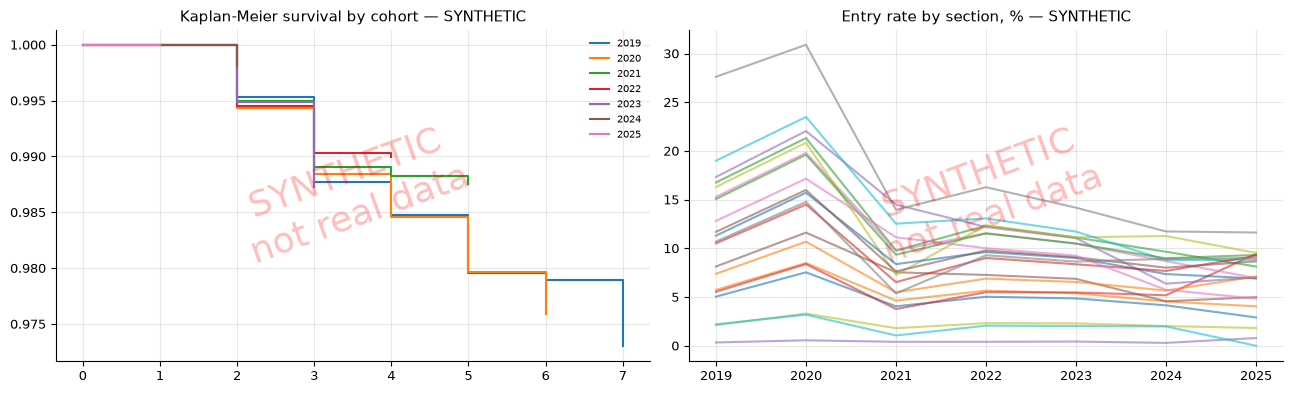

In [32]:
PRE = 'FR12_SYNTHETIC_' if DATA_MODE == 'SYNTHETIC' else 'FR12_FIRM_'
if DATA_MODE == 'REAL':                     # never leave synthetic outputs next to real ones
    for p_ in OUT.glob('FR12_SYNTHETIC_*.csv'): p_.unlink()
elif list(OUT.glob('FR12_FIRM_*.csv')):
    print('NOTE: FR12_FIRM_*.csv from an earlier REAL run are present in output/ and are not overwritten by this SYNTHETIC run')
LB = run_layer_b(REGISTER, DATA_MODE, OUT)
def calib_table(REG):
    '''Comparison of a register with the DSK aggregates (calibration errors / coverage).'''
    R_ = REG.copy(); R_['w'] = wcol(R_); R_['sec'] = R_.nace2.map(DIV2SEC)
    R_['reg_year'] = pd.to_datetime(R_.registration_date).dt.year
    CAL = []
    def cal(target, dim, unit, year, pub, syn, q):
        CAL.append(dict(target=target, dimension=dim, unit=unit, year=year, published=float(pub), synthetic=float(syn), abs_error=float(syn - pub),
                        rel_error_pct=float((syn - pub) / pub * 100) if pub else np.nan, status=q))
    for y in sorted(R_.year.unique()):
        d = R_[R_.year == y]
        nb = d[d.reg_year == y].groupby('sec').w.sum(); nd = d[d.status == 'liquidated'].groupby('sec').w.sum(); st = d[d.status == 'active'].groupby('sec').w.sum()
        for s in SECS:
            if y in (2021, 2024, 2025):
                cal('births', 'section', s, y, REG_FY['new'][y].get(s, 0), nb.get(s, 0), 'exact where published')
                cal('deaths', 'section', s, y, REG_FY['liq'][y].get(s, 0), nd.get(s, 0), 'exact where published')
                cal('active units, end of year', 'section', s, y, REG_FY['stock'][y].get(s, 0), st.get(s, 0), 'exact 2025; earlier via stock-flow (F5)')
            if (s, y) in NA.index: cal('revenue (thsd AZN) = output', 'section', s, y, NA.loc[(s, y), 'GO'] * 1000, (d[d.sec == s].w * d[d.sec == s].revenue).sum(), 'exact')
        nbr = d[d.reg_year == y].groupby('region').w.sum(); ndr = d[d.status == 'liquidated'].groupby('region').w.sum(); str_ = d[d.status == 'active'].groupby('region').w.sum()
        if y >= 2021:
            for r in REGS:
                q = rg.loc[(r, y)]
                cal('births', 'region', r, y, q.new, nbr.get(r, 0), 'exact'); cal('deaths', 'region', r, y, q.liquidated, ndr.get(r, 0), 'exact')
                cal('active units, end of year', 'region', r, y, q.enterprises, str_.get(r, 0), 'exact 2025; earlier via stock-flow')
        d2 = d.assign(grp=d.sec.map(lambda s: SECT[s][3]), wr=d.w * d.revenue)
        for g in GRP:
            dg = d2[d2.grp == g]
            if (g, y) in E012.index and dg.wr.sum() > 0:
                cal('SME share of revenue, %', 'activity group', g, y, E012.loc[(g, y), 'sme'], dg[dg.size_class != 'large'].wr.sum() / dg.wr.sum() * 100, 'exact (output base)')
            if (g, y) in E013.index and dg.w.sum() > 0:
                emp = dg.w * dg.employees
                cal('SME share of employees, %', 'activity group', g, y, E013.loc[(g, y), 'sme'], emp[dg.size_class != 'large'].sum() / emp.sum() * 100, 'exact except where the 251-employee floor of large units binds')
    _last = R_[(R_.year == R_.year.max()) & (R_.status == 'active')]
    for s in SECS:
        if s in SIZE.index and SIZE.loc[s].sum() > 0:
            for z in SIZES:
                cal(f'size mix: {z} share of units, %', 'section', s, int(R_.year.max()), SIZE.loc[s, z] / SIZE.loc[s].sum() * 100,
                    _last[(_last.sec == s) & (_last.size_class == z)].w.sum() / max(_last[_last.sec == s].w.sum(), 1) * 100, 'approximate (1 July 2026 snapshot)')
    return pd.DataFrame(CAL)
CALT = calib_table(REGISTER)
CALS = CALT.groupby(['target', 'dimension', 'status']).agg(cells=('published', 'size'), max_abs_error=('abs_error', lambda x: x.abs().max()),
                                                          median_abs_rel_error_pct=('rel_error_pct', lambda x: x.abs().median()),
                                                          max_abs_rel_error_pct=('rel_error_pct', lambda x: x.abs().max())).reset_index()
_cn = 'calibration_errors' if DATA_MODE == 'SYNTHETIC' else 'coverage_vs_dsk'
for nm, t in [(_cn, CALT), (_cn + '_summary', CALS)]:
    t = t.copy()
    if DATA_MODE == 'SYNTHETIC': t.insert(0, 'WATERMARK', SYN_MARK)
    t.to_csv(OUT / f'{PRE}{nm}.csv', index=False)
display(CALS.round(3))
PIPE = LB['PIPE'].copy()
if DATA_MODE == 'SYNTHETIC':
    ex = CALT[CALT.status.str.startswith('exact') & ~CALT.target.str.startswith('active') & ~CALT.target.str.startswith('SME share of emp')]
    _tol = (ex.abs_error.abs() <= 0.5 + 1e-7 * ex.published.abs()).all()
    PIPE.loc[len(PIPE)] = ['calibration: births, deaths, revenue and SME revenue shares reproduce DSK where published (max |relative error| %)',
                           float(ex.rel_error_pct.abs().max()), bool(_tol)]
    mb = LB.get('margins_boone')
    neg = float((mb.boone_beta.dropna() < 0).mean()) if mb is not None else np.nan
    PIPE.loc[len(PIPE)] = ['DGP check: Boone slope negative (efficient firms larger) in >= 90% of section-years', neg, bool(neg >= 0.9)]
    cn = LB['concentration_nace'].assign(alpha=lambda d: d.section.map(ALPHA))
    hi_c, lo_c = cn[cn.alpha <= 1.15].HHI.median(), cn[cn.alpha >= 2.0].HHI.median()
    PIPE.loc[len(PIPE)] = ['DGP check: low-Pareto-alpha sections more concentrated (median HHI ratio)', float(hi_c / lo_c), bool(hi_c > lo_c)]
PIPE.insert(0, 'WATERMARK', SYN_MARK) if DATA_MODE == 'SYNTHETIC' else None
PIPE.to_csv(OUT / f'{PRE}pipeline_tests.csv', index=False)
display(PIPE)
assert PIPE.passed.all(), 'Layer-B pipeline test failed'
_c = LB['concentration_nace']; _c = _c[_c.year == _c.year.max()].sort_values('HHI', ascending=False)
print(f'[{DATA_MODE}] most concentrated divisions {int(_c.year.max())} (pipeline demonstration): ' + ', '.join(f'{d} HHI {h:.0f}' for d, h in zip(_c.nace2.head(5), _c.HHI.head(5))))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
km = LB['survival_km']
for c, g in km.groupby('cohort'): ax[0].step(g.age, g.survival, where='post', label=str(c))
ax[0].set_title(f'Kaplan-Meier survival by cohort — {DATA_MODE}'); ax[0].legend(fontsize=7)
ee = LB['entry_exit_section'].pivot_table(index='year', columns='sec', values='entry_rate')
ax[1].plot(ee.index, ee.values, alpha=0.6); ax[1].set_title(f'Entry rate by section, % — {DATA_MODE}')
if DATA_MODE == 'SYNTHETIC':
    for a in ax: a.text(0.5, 0.5, 'SYNTHETIC\nnot real data', transform=a.transAxes, fontsize=26, color='red', alpha=0.25, ha='center', va='center', rotation=20)
plt.tight_layout(); plt.show()

### 17.6 Swap tests: proving the replacement works, in a temporary directory

On throw-away copies in a temporary directory (the project's `data/business_register/` never receives a real-named
file): (1) the synthetic file copied as `FR12_business_register.csv` with a neutral `data_status` loads as **REAL**,
passes the validator and produces `FR12_FIRM_*` outputs without watermark; (2) Azerbaijani headers load; (3)
`BUSREG_PATH`, set as an **environment variable**, takes priority over a real-named file; (4) a register **without**
a `weight` column runs through the full engine and the DSK comparison, and a weighted file gives the same metrics as
its expansion to one row per enterprise; (5) broken files — a missing required column; negative revenue and a
liquidation date before registration — produce clear per-row messages and stop the run; (6) the generator never
writes the real file name, and the project directory is scanned for any real-named file.

In [33]:
import tempfile, shutil
SW = []
def sw(name, ok, detail): SW.append(dict(test=name, passed=bool(ok), detail=str(detail)[:200]))
_ENV0 = os.environ.pop('BUSREG_PATH', None)          # tests run with a clean environment; restored afterwards
try:
  with tempfile.TemporaryDirectory() as td:
      td = Path(td); (td / 'data' / 'business_register').mkdir(parents=True); (td / 'output').mkdir()
      real = pd.read_csv(SYN_CSV, dtype={'nace2': str, 'firm_id': str}); real['data_status'] = 'Ministry register (test copy)'
      real.to_csv(td / 'data' / 'business_register' / 'FR12_business_register.csv', index=False)
      shutil.copy(SYN_CSV, td / 'data' / 'business_register' / SYN_CSV.name)
      p_, m_, s_, _ = load_register(td)
      sw('real-named file with neutral data_status -> DATA_MODE = REAL', m_ == 'REAL' and s_.name == 'FR12_business_register.csv', f'mode {m_}, file {s_.name}')
      r_ = check_register(p_, td / 'output' / 'FR12_business_register_validation_report.csv')
      sw('REAL file passes the validator (0 hard errors)', (~r_.severity.isin(['fatal', 'error'])).all(), f'{len(r_)} warnings')
      lb_ = run_layer_b(p_, m_, td / 'output')
      outs = sorted(p.name for p in (td / 'output').glob('FR12_*.csv'))
      sw('REAL mode writes FR12_FIRM_* only, without watermark; identity tests pass',
         any(o.startswith('FR12_FIRM_') for o in outs) and not any(o.startswith('FR12_SYNTHETIC_') for o in outs)
         and 'WATERMARK' not in pd.read_csv(td / 'output' / 'FR12_FIRM_concentration_nace.csv', nrows=2).columns and lb_['PIPE'].passed.all(),
         f'{len(outs)} files, e.g. {outs[:3]}')
      az = real.drop(columns='data_status').head(3000).rename(columns=BR_AZ)
      az.to_excel(td / 'register_az.xlsx', sheet_name='data', index=False)
      _old_env = os.environ.get('BUSREG_PATH')
      os.environ['BUSREG_PATH'] = str(td / 'register_az.xlsx')
      try:
          p2, m2, s2, unk = load_register(td)                     # no argument: the environment variable must be picked up
      finally:
          if _old_env is None: os.environ.pop('BUSREG_PATH', None)
          else: os.environ['BUSREG_PATH'] = _old_env
      r2 = br_validate(p2)
      sw('Azerbaijani headers (xlsx) load and validate', s2.name == 'register_az.xlsx' and not unk and (~r2.severity.isin(['fatal', 'error'])).all(),
         f'{len(p2)} rows, unknown columns {unk}, mode {m2}')
      sw('BUSREG_PATH environment variable has priority over the real-named file', s2.name == 'register_az.xlsx', f'loaded {s2.name} with BUSREG_PATH set in the environment')
      # register WITHOUT a weight column: the full engine and the calibration code run, and weights default to 1
      nw = real[real.nace2.map(DIV2SEC).isin(['D', 'J'])].copy()
      rep = nw.loc[nw.index.repeat(nw.weight.astype(int))].copy()
      rep['firm_id'] = rep.firm_id + '-' + rep.groupby(level=0).cumcount().astype(str)
      rep = rep.drop(columns='weight').reset_index(drop=True); rep.to_csv(td / 'register_noweight.csv', index=False)
      p3, m3, s3, _ = load_register(td, override=td / 'register_noweight.csv')
      lb3 = run_layer_b(p3, m3, td / 'output', write=False); lbw = run_layer_b(nw, 'REAL', td / 'output', write=False)
      _cal3 = calib_table(p3)                                      # the comparison code that crashed without `weight`
      def cmp(a, b, keys, cols):
          m = a[keys + cols].merge(b[keys + cols], on=keys, suffixes=('_a', '_b'))
          return float(max((m[c + '_a'] - m[c + '_b']).abs().max() for c in cols)), len(m)
      d1, n1 = cmp(lb3['concentration_nace'], lbw['concentration_nace'], ['nace2', 'year'], ['n_firms', 'HHI', 'CR4', 'CR8'])
      d2, n2 = cmp(lb3['entry_exit_section'], lbw['entry_exit_section'], ['sec', 'year'], ['entry_rate', 'exit_rate', 'young_firm_revenue_share'])
      d3, n3 = cmp(lb3['survival_km'], lbw['survival_km'], ['cohort', 'age'], ['survival'])
      d4, n4 = cmp(lb3['margins_boone'], lbw['margins_boone'], ['section', 'year'], ['n_profitable', 'pcm_pct'])
      sw('register without a weight column: full engine runs (weights default to 1)', 'weight' not in p3 and lb3['PIPE'].passed.all(), f'{len(p3):,} rows, mode {m3}; engine + DSK comparison ({len(_cal3)} cells) ran')
      sw('weights honoured: weighted file = expanded unweighted file (HHI, CR4/CR8, entry/exit, KM, Boone n, PCM)', max(d1, d2, d3, d4) < 1e-6,
         f'max abs diff {max(d1, d2, d3, d4):.2e} over {n1 + n2 + n3 + n4} cells')
      br = real.head(500).drop(columns='revenue')
      r3 = br_validate(br)
      sw('broken file: missing required column reported as fatal', ((r3.severity == 'fatal') & (r3.field == 'revenue')).any(), '; '.join(r3.rule.unique()))
      br2 = real.head(500).copy(); br2.loc[:2, 'revenue'] = -5.0
      br2.loc[3:4, 'liquidation_date'] = '1990-01-01'
      r4 = validate_rows = br_validate(br2)
      rows_flag = sorted(set(r4[r4.field.isin(['revenue', 'liquidation_date'])].row))
      try:
          check_register(br2, td / 'output' / 'rep.csv'); stopped, msg = False, ''
      except ValueError as e:
          stopped, msg = True, str(e)
      sw('broken file: negative revenue and liquidation before registration flagged per row; the run stops', rows_flag[:5] == [2, 3, 4, 5, 6] and stopped, msg)
      _realnamed = sorted(p.name for p in BRDIR.iterdir() if re.fullmatch(r'FR12_business_register\.(csv|xlsx|xls)', p.name))
      sw('generator never writes the real file name; project directory scanned for real-named files',
         not any(re.fullmatch(r'FR12_business_register\.(csv|xlsx|xls)', n) for n in GEN_WRITTEN) and (not _realnamed or DATA_MODE == 'REAL'),
         f'generator wrote {sorted(set(GEN_WRITTEN))}; real-named files in data/business_register: {_realnamed or "none"}')
finally:
    if _ENV0 is not None: os.environ['BUSREG_PATH'] = _ENV0
SWAP = pd.DataFrame(SW)
display(SWAP)
assert SWAP.passed.all(), 'business-register swap test failed'
SWAP.to_csv(OUT / 'FR12_business_register_swap_tests.csv', index=False)
assert not any((BRDIR / n).exists() for n in ['FR12_business_register.csv', 'FR12_business_register.xlsx']) or DATA_MODE == 'REAL'
print(f'all {len(SWAP)} swap tests pass; the project data/business_register/ holds no real-named file unless the Ministry placed one')

,test,passed,detail
0,real-named file with neutral data_status -> DA...,True,"mode REAL, file FR12_business_register.csv"
1,REAL file passes the validator (0 hard errors),True,0 warnings
2,"REAL mode writes FR12_FIRM_* only, without wat...",True,"8 files, e.g. ['FR12_FIRM_concentration_nace.c..."
3,Azerbaijani headers (xlsx) load and validate,True,"3000 rows, unknown columns [], mode REAL"
4,BUSREG_PATH environment variable has priority ...,True,loaded register_az.xlsx with BUSREG_PATH set i...
5,register without a weight column: full engine ...,True,"38,849 rows, mode REAL; engine + DSK compariso..."
6,weights honoured: weighted file = expanded unw...,True,max abs diff 6.37e-12 over 112 cells
7,broken file: missing required column reported ...,True,required column missing (EN or AZ header)
8,broken file: negative revenue and liquidation ...,True,business register rejected: 8 hard errors (fir...
9,generator never writes the real file name; pro...,True,generator wrote ['FR12_business_register_SYNTH...


all 10 swap tests pass; the project data/business_register/ holds no real-named file unless the Ministry placed one


## Part 18 — Checks, exports and the documentation step

### 18.1 Exports and arithmetic checks

In [34]:
_ig = IND_G.merge(PCM_G.PCM.reset_index().rename(columns={'group': 'group'}), on=['group', 'year'], how='left')
_ig = _ig.merge(SME.reset_index(), on=['group', 'year'], how='left')
_ig['name'] = _ig.group.map(lambda g: GROUPS[g][0])
_ig.to_csv(OUT / 'FR12_indicators_groups.csv', index=False)
_is = IND_S.merge(NA.reset_index()[['sec', 'year', 'PCM']], on=['sec', 'year'], how='left'); _is['name'] = _is.sec.map(lambda s: SECT[s][0])
_is.to_csv(OUT / 'FR12_indicators_sections.csv', index=False)
RG[['region', 'year', 'enterprises', 'new', 'liquidated', 'micro', 'small', 'medium', 'entry', 'exit', 'churn', 'net']].to_csv(OUT / 'FR12_indicators_regions.csv', index=False)
REGDISP.to_csv(OUT / 'FR12_regional_dispersion.csv')
SURV.reset_index().to_csv(OUT / 'FR12_cohort_size_ratio.csv', index=False)
TAXB.to_csv(OUT / 'FR12_taxpayer_concentration.csv')
pd.concat([BARR, LIC_G.add_prefix('licences_')], axis=1).to_csv(OUT / 'FR12_barriers.csv')
INSTAB.to_frame().to_csv(OUT / 'FR12_share_instability_branches.csv')
NA.reset_index()[['sec', 'year', 'GO', 'VA', 'CE', 'GOS', 'PCM']].to_csv(OUT / 'FR12_pcm_sections.csv', index=False)
FLOWS.to_csv(OUT / 'FR12_register_flows.csv', index=False)
pd.DataFrame(SELTAB).to_csv(OUT / 'FR12_selection_scores.csv', index=False)
SELSUM = selsum()
SELSUM['applied_at_last_origin'] = [', '.join(FINAL[(r.panel, r.dep)]['spec']) or 'no driver (null)' if (r.panel, r.dep) in FINAL else 'see Part 14' for r in SELSUM.itertuples()]
SELSUM.to_csv(OUT / 'FR12_selection_summary.csv', index=False)
HOLDV.to_csv(OUT / 'FR12_holdout_validation.csv', index=False); HOLDTAB.to_csv(OUT / 'FR12_holdout_detail.csv', index=False)
pd.DataFrame(COHLOG).drop_duplicates(subset=['key', 'origin', 'driver']).to_csv(OUT / 'FR12_coherence.csv', index=False)
FULL.to_csv(OUT / 'FR12_fe_estimates.csv', index=False)
BAND_META.to_csv(OUT / 'FR12_band_meta.csv', index=False)
MERGER_SCREEN.to_csv(OUT / 'FR12_merger_screen.csv', index=False)
FINDINGS.to_csv(OUT / 'FR12_data_integrity_findings.csv', index=False)
BR_SCHEMA.to_csv(OUT / 'FR12_business_register_schema.csv', index=False)
# arithmetic checks
_t = FC[FC.panel == 'activity'].groupby(['scenario', 'year']).N.sum(); _a = AGG[AGG.panel == 'activity'].set_index(['scenario', 'year']).N
chk('aggregate N = sum of group N in every scenario-year', float((_t - _a).abs().max()), (_t - _a).abs().max() < 1e-6)
chk('fan: p5 <= p50 <= p95 for every series', 0.0, bool(((FAN.entry_p5 <= FAN.entry_p50 + 1e-9) & (FAN.entry_p50 <= FAN.entry_p95 + 1e-9) & (FAN.N_p5 <= FAN.N_p95)).all()))
chk('SME + large output shares = 100 (all groups, years)', float((SME.sme_output_share + SME.large_output_share - 100).abs().max()), (SME.sme_output_share + SME.large_output_share - 100).abs().max() < 1e-9)
chk('early-warning score in [0, 1]', float(EWS.score.max()), bool(EWS.score.between(0, 1).all()))
CHKS = pd.DataFrame(CHK); CHKS.to_csv(OUT / 'FR12_identity_checks.csv', index=False)
display(CHKS)
assert CHKS.passed.all(), 'arithmetic check failed'
print(f'{len(CHKS)} arithmetic checks pass; {len(list(OUT.glob("FR12_*.csv")))} FR12 CSV files in output/ '
      f'({len(list(OUT.glob("FR12_SYNTHETIC_*.csv")))} SYNTHETIC, {len(list(OUT.glob("FR12_FIRM_*.csv")))} FIRM)')

,check,value,passed,kind
0,register sections add to published totals (11 ...,0.000,True,arithmetic
1,entrepreneurship 11 groups add to total (006),0.000,True,arithmetic
2,national accounts: output − IC = VA (all secti...,0.040,True,arithmetic
3,size classes sum to commercial organisations (...,0.000,True,arithmetic
4,"region panel totals = register totals 2021, 20...",0.000,True,arithmetic
5,HHI lower <= floor variants <= headline upper;...,0.000,True,arithmetic
6,CR4 bounds consistent with HHI bounds: CR4^2/4...,0.000,True,arithmetic
7,stock-flow identity N(t) = N(t-1) + births(t) ...,0.000,True,arithmetic
8,projected upper bounds evolve continuously (ma...,0.003,True,arithmetic
9,"Cournot calibration reproduces P = 1, Q = 1 at...",0.000,True,arithmetic


19 arithmetic checks pass; 48 FR12 CSV files in output/ (9 SYNTHETIC, 0 FIRM)


### 18.2 Documentation step

Every run-dependent number in `docs/FR12_Methodology.md` is generated here from the CSV files just written, between
`<!-- AUTO:name -->` and `<!-- /AUTO:name -->` markers. The cell asserts that every marker exists and that the
document has no marker the notebook does not fill.

In [35]:
DOC = BASE / 'docs' / 'FR12_Methodology.md'
rd = lambda n, **kw: pd.read_csv(OUT / f'FR12_{n}.csv', **kw)
def mdt(df, fmt=None, dflt='{:.2f}'):
    fmt = fmt or {}; d = df.copy()
    def cell(c, v):
        if isinstance(v, (bool, np.bool_)): return 'yes' if v else 'no'
        if isinstance(v, str) and v in ('True', 'False'): return 'yes' if v == 'True' else 'no'
        if isinstance(v, (float, np.floating)): return '—' if not np.isfinite(v) else fmt.get(c, dflt).format(v)
        if isinstance(v, (int, np.integer)): return f'{int(v)}'
        return str(v).replace('|', '/')
    out = ['| ' + ' | '.join(str(c) for c in d.columns) + ' |', '|' + '---|' * len(d.columns)]
    out += ['| ' + ' | '.join(cell(c, r[c]) for c in d.columns) + ' |' for _, r in d.iterrows()]
    return '\n'.join(out)
yl = lambda xs: ', '.join(str(int(x)) for x in sorted(set(xs)))
G_ = {}
man = rd('dsk_manifest'); mx_ = rd('data_source_matrix'); fnd_ = rd('data_integrity_findings'); hv = rd('holdout_validation'); ss_ = rd('selection_summary')
fan_ = rd('fan_entry_exit'); fc_ = rd('forecast_entry_exit'); ew_ = rd('early_warning'); scs = rd('scenario_summary'); sca = rd('scenario_assumptions')
pm = REG_META; syn = DATA_MODE == 'SYNTHETIC'
G_['mode_header'] = (f"**Layer-B data mode: {pm['mode']}** — input file `data/business_register/{pm['file']}`, {pm['rows']:,} rows, {pm['records']:,} records "
                     f"({pm['enterprises_last']:,.0f} active enterprises in {pm['year_max']}), {pm['sections']} NACE sections, {pm['divisions']} divisions, "
                     f"{pm['regions']} regions, {pm['year_min']}–{pm['year_max']}."
                     + (" The register is **SYNTHETIC — not real enterprise data**; Layer-B outputs are a pipeline demonstration, not findings." if syn else
                        " Layer-B outputs (`FR12_FIRM_*.csv`) are computed from the Ministry's register."))
_ab = fan_[(fan_.unit == 'ALL') & (fan_.panel == 'activity')].set_index('year'); _rb = fan_[(fan_.unit == 'ALL') & (fan_.panel == 'region')].set_index('year')
G_['rev'] = (f"This run: {int((man.origin == 'archived vintage').sum())} archived DSK vintages and {len(man)} input files (URL and SHA-256 each); "
             f"{len(fnd_)} data-integrity findings; {len(mx_)} indicators in the source matrix ({', '.join(f'{k} {v}' for k, v in mx_.status.value_counts().items())}); "
             f"baseline 2030, registered entrepreneurship subjects: {_ab.loc[2030, 'new_baseline']:,.0f} new registrations (90% band {_ab.loc[2030, 'new_p5']:,.0f}–{_ab.loc[2030, 'new_p95']:,.0f}), "
             f"entry rate {_ab.loc[2030, 'entry_baseline']:.2f}% ({_ab.loc[2030, 'entry_p5']:.2f}–{_ab.loc[2030, 'entry_p95']:.2f}), exit rate {_ab.loc[2030, 'exit_baseline']:.2f}%; "
             f"statistical units {_rb.loc[2030, 'N_baseline']:,.0f} ({_rb.loc[2030, 'N_p5']:,.0f}–{_rb.loc[2030, 'N_p95']:,.0f}); early-warning threshold z* = {Z_STAR:g}, "
             f"watch list: {', '.join(ew_[ew_.watch_list].name) or 'none'}; {len(list(OUT.glob('FR12_*.csv')))} FR12 CSV files, of which "
             f"{len(list(OUT.glob('FR12_SYNTHETIC_*.csv')))} SYNTHETIC; runtime {time.time() - T0:.0f} s.")
_mg = man.groupby(['origin', 'status']).size().rename('files').reset_index()
_mv = man[man.origin != 'FR10 download (read only)'][['file', 'source_url', 'content', 'sha256']].assign(sha256=lambda d: d.sha256.str[:16] + '…')
G_['data'] = (mdt(_mg) + '\n\nArchived vintages and new DSK downloads (full list with SHA-256 in `FR12_dsk_manifest.csv`):\n\n' + mdt(_mv)
              + f"\n\nActivity panel years: {yl(PA.year)}; region panel: {yl(PR.year)}; register flows by section: full years "
              f"{yl(FLOWS[(FLOWS.kind == 'section') & (FLOWS.period == 'FY')].year)}, half-years {yl(FLOWS[(FLOWS.kind == 'section') & (FLOWS.period == 'H1')].year)}.")
G_['integrity'] = mdt(fnd_)
G_['matrix_summary'] = mdt(mx_.groupby(['pillar', 'status']).size().unstack(fill_value=0).reset_index())
G_['matrix'] = mdt(mx_[['id', 'pillar', 'indicator_az', 'indicator_en', 'formula', 'source_institution', 'dataset_table_row', 'granularity', 'years_available_now',
                        'status', 'integration_into_MIIS', 'analytical_use', 'presentation_form', 'alternative_if_unavailable']])
G_['gaps'] = mdt(rd('data_gaps_and_alternatives')); G_['pres'] = mdt(rd('presentation_spec'))
ig = rd('indicators_groups')
G_['ind_groups'] = ('New registrations:\n\n' + mdt(ig.pivot_table(index='name', columns='year', values='new').reset_index(), dflt='{:,.0f}')
                    + '\n\nEntry rate, %:\n\n' + mdt(ig.pivot_table(index='name', columns='year', values='entry').round(2).reset_index())
                    + '\n\nExit rate, %:\n\n' + mdt(ig.pivot_table(index='name', columns='year', values='exit').round(2).reset_index()))
isec = rd('indicators_sections'); _p = isec.pivot_table(index=['sec', 'name'], columns='year', values=['entry', 'exit']).round(2)
G_['ind_sections'] = mdt(_p.set_axis([f'{a} {b}' for a, b in _p.columns], axis=1).reset_index())
G_['ind_other'] = (f"Regions: entry {RG.entry.min():.1f}–{RG.entry.max():.1f}%, exit {RG.exit.min():.2f}–{RG.exit.max():.2f}% (2021–2025); coefficient of variation of "
                   f"regional entry {REGDISP.cv_entry.iloc[0]:.2f} (2021) → {REGDISP.cv_entry.iloc[-1]:.2f} ({int(REGDISP.index[-1])}); HHI of units across regions "
                   f"{REGDISP.hhi_units.iloc[-1]:.0f}. Manufacturing branch-share instability {INSTAB.loc[2006:2015].mean()*100:.1f} pp a year (2006–15) vs "
                   f"{INSTAB.loc[2016:].mean()*100:.1f} pp (2016–25). Licences issued {int(BARR.licences_new.loc[2016])} (2016) → {int(BARR.licences_new.loc[LAST_ACT])} "
                   f"({LAST_ACT}) — an entry indicator. Inspections are not comparable over time (F18: coverage widened in 2020–2022).\n\n"
                   "Price-cost margin proxy by group, % of output:\n\n" + mdt(PCM_G.PCM.unstack(0).loc[[2015, 2019, 2022, 2024, LAST_ACT]].T.round(1).reset_index())
                   + '\n\nCohort-size ratio (active SMEs aged k / aged 1, same year — mixes cohort size and survival; **not** a survival rate):\n\n' + mdt(SURV.round(2).reset_index()))
b24 = BND[BND.year == 2024]
G_['bounds'] = (mdt(b24[['group', 'market_output_mn', 'n_large', 'large_share', 'caps_used', 'hhi_lower', 'hhi_upper', 'cr4_lower', 'cr4_upper',
                         'hhi_upper_floor30', 'cr4_upper_floor30', 'hhi_upper_floor15', 'cr4_upper_floor15']].round(1))
                + '\n\nTaxpayer size classes (DVX, micro excluded — F8):\n\n' + mdt(TAXB.round(2).reset_index()))
G_['noar'] = mdt(rd('noar_constructs'))
G_['fe'] = mdt(rd('fe_estimates').round(3))

In [36]:
G_['select'] = mdt(ss_.round(3))
_co = rd('coherence')
G_['coh'] = mdt(_co[['key', 'origin', 'driver', 'fe', 'fd', 'fd_lo', 'fd_hi', 'transitions', 'status']].round(3)) if len(_co) else 'No structural driver was checked.'
G_['holdout'] = mdt(hv[['panel', 'metric', 'rule', 'implied_rw_weight', 'n', 'targets', 'rmse_rule', 'rmse_null', 'rmse_rw', 'rmse_constant', 'theil_rule_vs_rw',
                        'theil_rule_vs_constant', 'theil_null_vs_rw', 'theil_constant_vs_rw', 'dm_p_rule_vs_rw', 'dm_p_rule_vs_constant']].round(3))
fa = fc_[fc_.unit == 'ALL'].pivot_table(index=['panel', 'year'], columns='scenario', values=['new', 'entry', 'exit', 'N']).round(2)
fa.columns = [f'{a} {b}' for a, b in fa.columns]
_nf = {c: '{:,.0f}' for c in fa.columns if c.startswith('N ') or c.startswith('new ')}
G_['forecast'] = (mdt(fa.reset_index(), fmt=_nf)
                  + '\n\nBaseline bands (5–95%):\n\n' + mdt(fan_[(fan_.unit == 'ALL') & fan_.year.isin([2025, 2026, 2028, 2030])][['panel', 'year', 'new_baseline', 'new_p5', 'new_p95',
                    'entry_baseline', 'entry_p5', 'entry_p95', 'exit_baseline', 'exit_p5', 'exit_p95', 'N_baseline', 'N_p5', 'N_p95']],
                    fmt={c: '{:,.0f}' for c in ['new_baseline', 'new_p5', 'new_p95', 'N_baseline', 'N_p5', 'N_p95']})
                  + '\n\nBand construction:\n\n' + mdt(rd('band_meta')))
pl_ = rd('plausibility'); lb_ = rd('last_actual_vs_2026_band')
G_['plaus'] = (f"{int(pl_.flag.notna().sum())} of {len(pl_)} unit-variable forecasts flagged:\n\n" + mdt(pl_[pl_.flag.notna()].round(2))
               + f"\n\nLast actual entry rate against the 2026 band: {int((~lb_.inside).sum())} of {len(lb_)} outside, each with its reason:\n\n"
               + mdt(lb_[~lb_.inside].round(2)))
cpb = rd('concentration_paths'); cpb = cpb[(cpb.scenario == 'Baseline') & cpb.year.isin([2026, 2030])]
_cp = cpb.pivot_table(index='group', columns='year', values=['large_share', 'hhi_lower', 'hhi_upper']).round(1)
G_['concpaths'] = mdt(_cp.set_axis([f'{a} {b}' for a, b in _cp.columns], axis=1).reset_index())
_s5 = SC_RES[SC_RES.scenario == 'S5']
G_['scen'] = (mdt(sca[['scenario', 'market', 'change', 'assumption', 'hhi_range', 'structure_source']])
              + '\n\nResults over the whole range (HHI lower → upper bound × ε 0.5–2 × θ ∈ {1, 0.5}); endpoints at ε = 1, θ = 1:\n\n'
              + mdt(scs[['scenario', 'market', 'assumption', 'hhi_min', 'hhi_max', 'd_price_min', 'd_price_max', 'd_price_at_lower_bound', 'd_price_at_upper_bound',
                         'd_output_min', 'd_output_max', 'd_cs_pct_min', 'd_cs_pct_max', 'd_cs_mn_min', 'd_cs_mn_max']], fmt={'hhi_min': '{:,.0f}', 'hhi_max': '{:,.0f}'})
              + '\n\nMerger screens (S2):\n\n' + mdt(rd('merger_screen').round(1))
              + f"\n\nMixed oligopoly (S5): the welfare-maximising SOE prices at its rising marginal cost and expands output; privatisation makes it restrict "
              f"output like a private firm, so its share falls (to {_s5.soe_share_after.min():.1f}–{_s5.soe_share_after.max():.1f}% across cases), the price rises by "
              f"{_s5.d_price_pct.min():.2f}–{_s5.d_price_pct.max():.2f}% and total welfare changes by {_s5.d_welfare_pct_rev.min():.2f} to {_s5.d_welfare_pct_rev.max():.2f}% of market revenue; "
              f"private Cournot firms (symmetric-equivalent) {_s5.n_private.min():.1f}–{_s5.n_private.max():,.0f}.")
_fl = rd('early_warning_false_listing')
G_['ew'] = (f"Threshold z* = {Z_STAR:g}. Simulated false-listing rates (share of no-change sectors reaching the watch list):\n\n"
            + mdt(_fl[['z_threshold', 'null', 'false_listing_rate']].round(3)) + '\n\n'
            + mdt(ew_[['group', 'name', 'z_conc', 'z_entry', 'z_exit', 'z_mob', 'z_margin', 'F_conc', 'F_entry', 'F_exit', 'F_mob', 'F_margin_entry', 'n_available',
                       'n_flags', 'score', 'watch_list', 'info_licences_z', 'info_cohort_size_ratio_change_pct', 'info_state_share_of_active_SMEs_2024']].round(2))
            + f"\n\nWatch list ({int(ew_.watch_list.sum())}): " + ('; '.join(f"{r['name']} — {r['flags']}" for _, r in ew_[ew_.watch_list].iterrows()) or 'none')
            + '. Single flags (monitor): ' + ('; '.join(f"{r['name']} — {r['flags']}" for _, r in ew_[(ew_.n_flags >= 1) & ~ew_.watch_list].iterrows()) or 'none') + '.')
_pre = 'SYNTHETIC_' if syn else 'FIRM_'
_cs = rd(f"{_pre}{'calibration_errors' if syn else 'coverage_vs_dsk'}_summary")
G_['layerb'] = (G_['mode_header'] + '\n\n' + ("**This section is a pipeline demonstration, not findings.** The Ministry replaces "
                "`data/business_register/FR12_business_register_SYNTHETIC.csv` with its own register in its own system (`FR12_business_register.csv/.xlsx` or "
                "`BUSREG_PATH`) and re-runs the notebook; outputs then become `FR12_FIRM_*.csv`.\n\n" if syn else '')
                + ('Calibration errors against the DSK aggregates:\n\n' if syn else 'Coverage of the register against the DSK aggregates:\n\n')
                + mdt(_cs.drop(columns=['WATERMARK'], errors='ignore').round(3))
                + '\n\nPipeline tests:\n\n' + mdt(rd(f'{_pre}pipeline_tests').drop(columns=['WATERMARK'], errors='ignore')[['test', 'value', 'passed']].round(3))
                + '\n\nSwap tests (temporary directory):\n\n' + mdt(rd('business_register_swap_tests'))
                + f"\n\nValidator on the loaded register: {int((VREP.severity == 'warning').sum())} warnings, 0 hard errors.")
ck = rd('identity_checks')
G_['checks'] = f"{int(ck.passed.sum())} of {len(ck)} arithmetic checks pass (`FR12_identity_checks.csv`)."
G_['outputs'] = ', '.join(f'`{p.name}`' for p in sorted(OUT.glob('FR12_*.csv')))
doc = DOC.read_text(); missing = []
for k, v in G_.items():
    pat = re.compile(rf'(<!-- AUTO:{k} -->)(.*?)(<!-- /AUTO:{k} -->)', re.S)
    if not pat.search(doc): missing.append(k); continue
    doc = pat.sub(lambda m: m.group(1) + '\n' + v + '\n' + m.group(3), doc)
assert not missing, f'doc markers missing: {missing}'
left = set(re.findall(r'<!-- AUTO:(\w+) -->', doc)) - set(G_)
assert not left, f'doc has markers the notebook does not fill: {left}'
DOC.write_text(doc)
print(f'docs/FR12_Methodology.md: {len(G_)} generated blocks filled from this run\'s CSV outputs; total runtime {time.time() - T0:.0f} s')

docs/FR12_Methodology.md: 25 generated blocks filled from this run's CSV outputs; total runtime 13 s
